In [3]:
import yaml
import numpy as np
import pandas as pd
import lhapdf as lh

import matplotlib.pyplot as mpl
mpl.rc("text", usetex = True)

import matplotlib.pyplot as plt
#import MatplotlibSettings
from collections import deque
import copy
import os
from os import listdir
pd.set_option("display.max_rows", None, "display.max_columns", None)

In [4]:
# PATH's
FIT_FOLDER = "./"
DATA_FOLDER = "./Data"

In [42]:
def ylabel_extractor(dat_file_name):
  with open(DATA_FOLDER + "/" + dat_file_name, "r") as file:
    data_file = yaml.safe_load(file)
  return data_file['dependent_variables'][0]['header']['ylabelpy']

def binint_extractor(dat_file_name):
  with open(DATA_FOLDER + "/" + dat_file_name, "r") as file:
    data_file = yaml.safe_load(file)
  qualifiers = data_file['dependent_variables'][0]['qualifiers']
  integrate = next(
    (
      md['integrate']
      for md in qualifiers
      if md['name'] == 'z'
    ),
    None
)
  return integrate

def xlim_extractor(dat_file_name):
  with open(DATA_FOLDER + "/" + dat_file_name, "r") as file:
    data_file = yaml.safe_load(file)
  ind_vars = data_file['independent_variables']
  z_values = next(
    (
      md['values']
      for md in ind_vars
      if md['header']['name'] == 'z'
    ),
    None
)
  if (z_values[0]['value'] > z_values[-1]['value']):  #Treats the case of reversed z values 
    first_bin = z_values[-1]['value'] * (1 - 0.5)
    last_bin = z_values[0]['value'] * (1 + 0.1) 
  else:
    first_bin = z_values[0]['value'] * (1 - 0.5)
    last_bin = z_values[-1]['value'] * (1 + 0.1)
  return [first_bin, last_bin]

def Vs_extractor(dat_file_name):
  with open(DATA_FOLDER + "/" + dat_file_name, "r") as file:
    data_file = yaml.safe_load(file)
    for qualifier in data_file['dependent_variables'][0]['qualifiers']:
      if qualifier['name'] == 'Vs':
        vs = qualifier['value']
        break
  return vs

In [43]:
# Config file
with open(FIT_FOLDER + "/config.yaml", "r") as file:
  config_file = yaml.safe_load(file)

dat_sets_list = config_file['Data']['sets']

In [44]:
# Read and report chi2's
with open(FIT_FOLDER + "Chi2s.yaml", "r") as chi2file:
    for chi2 in yaml.load(chi2file, Loader = yaml.CLoader):
        for c in chi2.items(): 
            print(c[0],"(Npt = ",c[1]["Npt"],"): chi2 = ", c[1]["chi2"])

ALEPH $\Lambda \bar{\Lambda}$ (Npt =  25 ): chi2 =  0.48218132636308625
ARGUS $\Lambda \bar{\Lambda}$ (Npt =  16 ): chi2 =  1.6473076829349849
BELLE $\Lambda \bar{\Lambda}$ (Npt =  15 ): chi2 =  1.4660363264396352
CELLO $\Lambda \bar{\Lambda}$ (Npt =  7 ): chi2 =  0.5768874604189593
Delphi 91.2 GeV $\Lambda \bar{\Lambda}$ (Npt =  11 ): chi2 =  4.800386961528999
Delphi 183 GeV $\Lambda \bar{\Lambda}$ (Npt =  5 ): chi2 =  3.4812559700791157
Delphi 189 GeV $\Lambda \bar{\Lambda}$ (Npt =  5 ): chi2 =  2.643685210795314
HRS $\Lambda \bar{\Lambda}$ (Npt =  12 ): chi2 =  0.7985366976966303
MARK II $\Lambda \bar{\Lambda}$ (Npt =  15 ): chi2 =  2.6287271462678685
OPAL $\Lambda \bar{\Lambda}$ (Npt =  15 ): chi2 =  0.9609679157944477
SLD B $\Lambda \bar{\Lambda}$ (Npt =  8 ): chi2 =  0.5195331391162521
SLD C $\Lambda \bar{\Lambda}$ (Npt =  8 ): chi2 =  1.0430048008618766
SLD UDS $\Lambda \bar{\Lambda}$ (Npt =  8 ): chi2 =  1.8237918769785586
SLD $\Lambda \bar{\Lambda}$ (Npt =  16 ): chi2 =  0.696

In [45]:
# Plot settings
exps = [data['name'] for data in dat_sets_list]
plotfiles = dict(zip(exps, [data['file'].removesuffix('.yaml') for data in dat_sets_list]))
ylabels = dict(zip(exps, [ylabel_extractor(data['file']) for data in dat_sets_list]))
binints = dict(zip(exps, [binint_extractor(data['file']) for data in dat_sets_list]))
xlims = dict(zip(exps, [xlim_extractor(data['file']) for data in dat_sets_list]))
zcuts = { data['name']: (data['cuts'][0]['min'], data['cuts'][0]['max']) for data in dat_sets_list}
vs =  dict(zip(exps, [Vs_extractor(data['file']) for data in dat_sets_list]))

# Set Default
xlog = dict(zip(exps, [
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
    False,
]))


ylims1 = dict(zip(exps, [
    [-0.05, 0.1],
    [0, 2],
    [0, 2],
    [0, 2],
    [0, 2],
    [0, 2],
    [5e3, 3e7],
    [2e-3, 10],
    [0.8, 30],
    [0.05, 20],
    [0.02, 15],
    [0.02, 200],
    [0.2, 7],
    [0.05, 200],
    [0.2, 300],
    [0.8, 10],
    [0.03, 1000],
    [0.00005, 10],
    [0.0002, 10],
]))

ylims2 = dict(zip(exps, [
    [0.6, 1.4],
    [0.6, 1.4],
    [0.6, 1.4],
    [0.6, 1.4],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.8, 1.2],
    [0.95, 1.05],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.5, 1.5],
    [0.8, 1.2]
]))

# Create plots folder
if not os.path.exists(FIT_FOLDER + "/plots"):
    os.makedirs(FIT_FOLDER + "/plots/predictions")
    os.makedirs(FIT_FOLDER + "/plots/ffs")


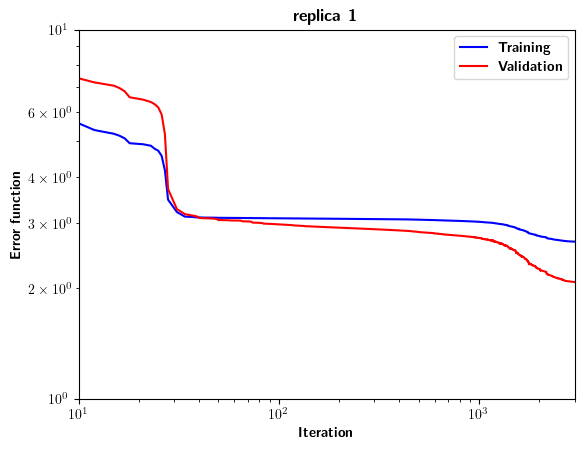

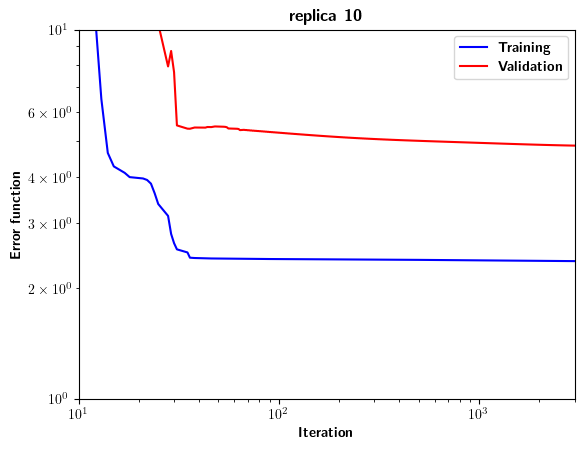

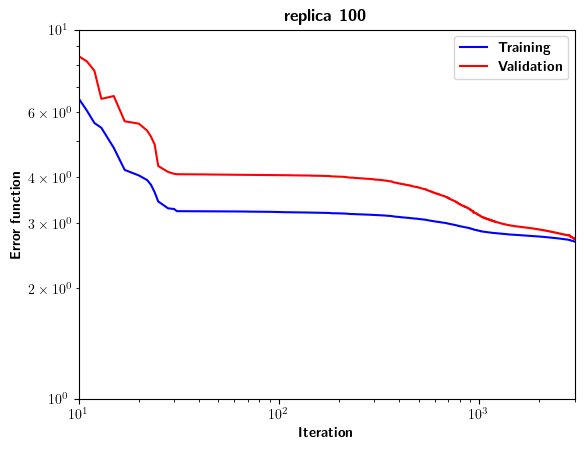

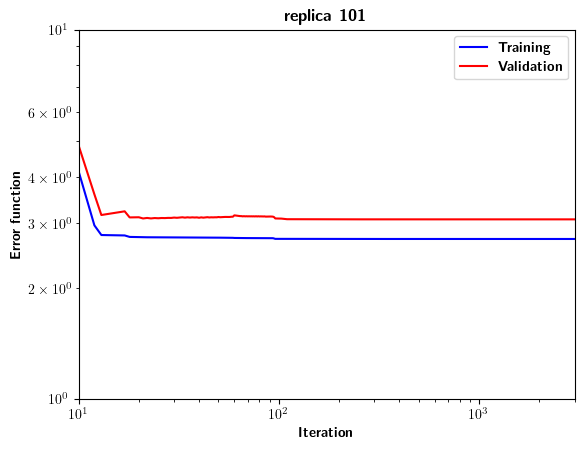

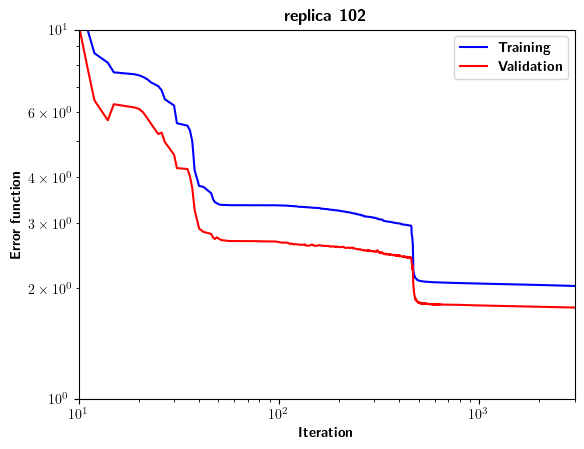

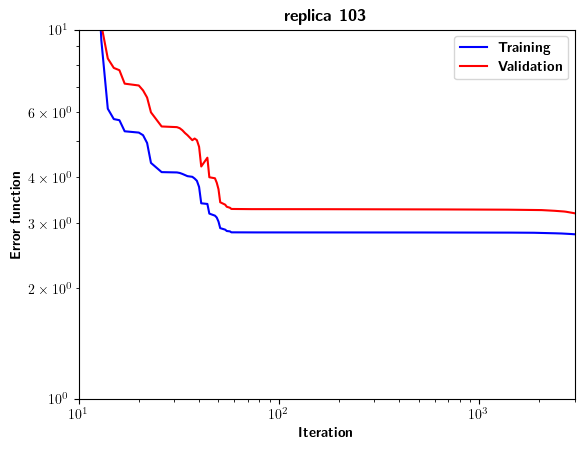

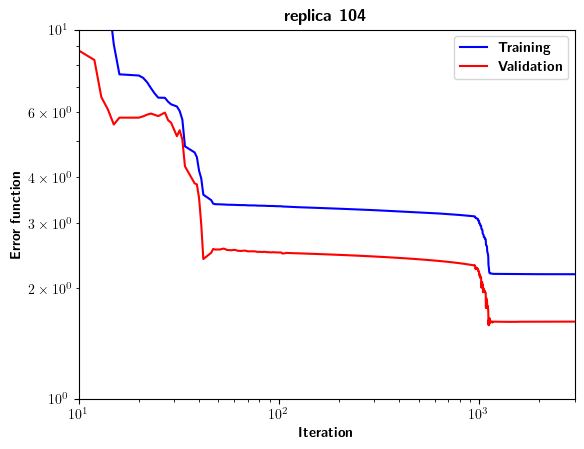

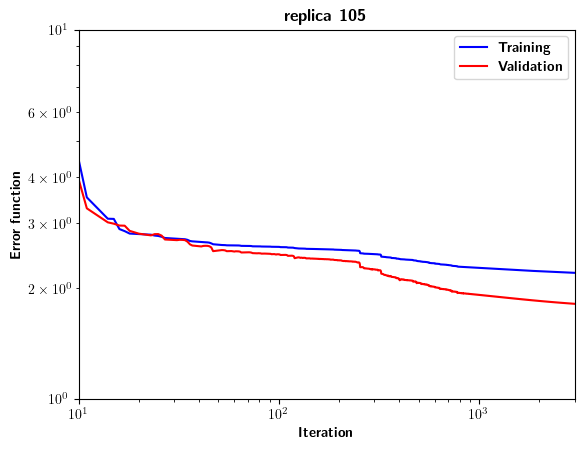

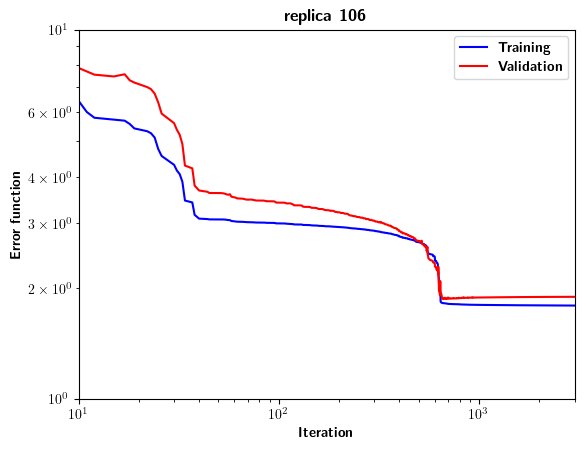

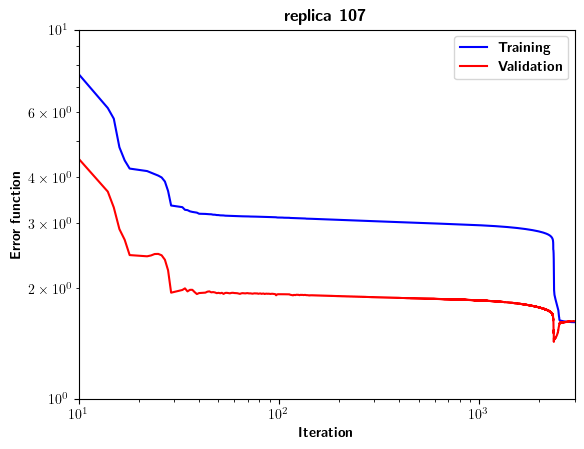

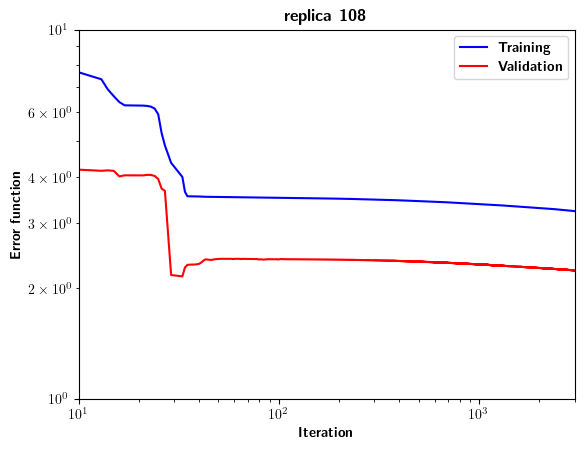

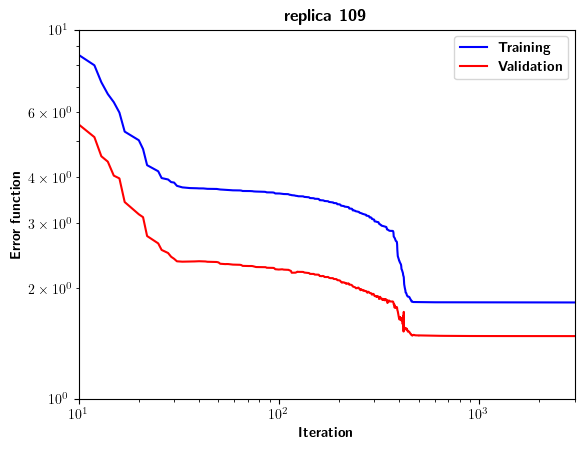

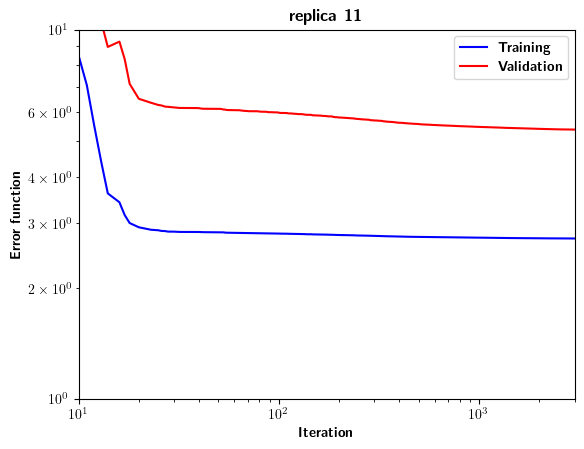

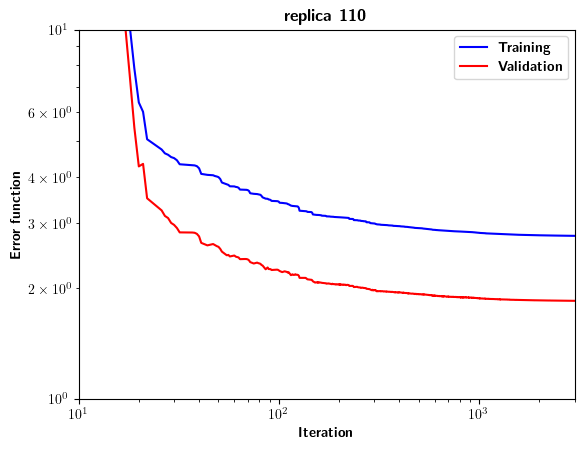

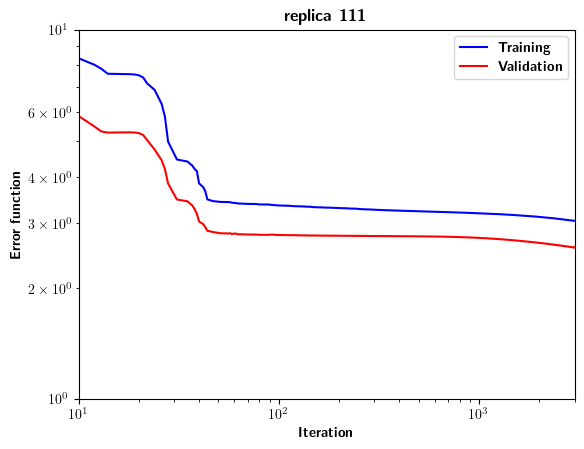

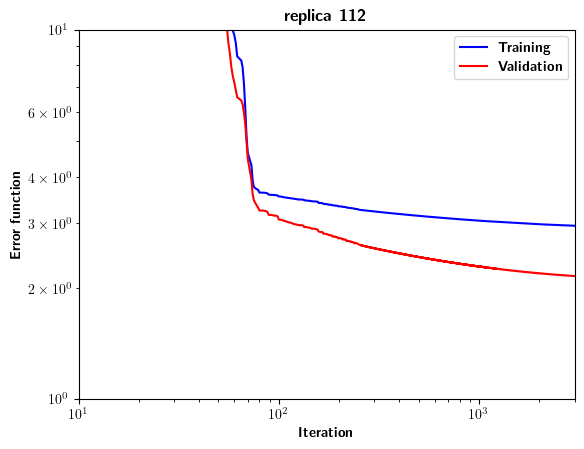

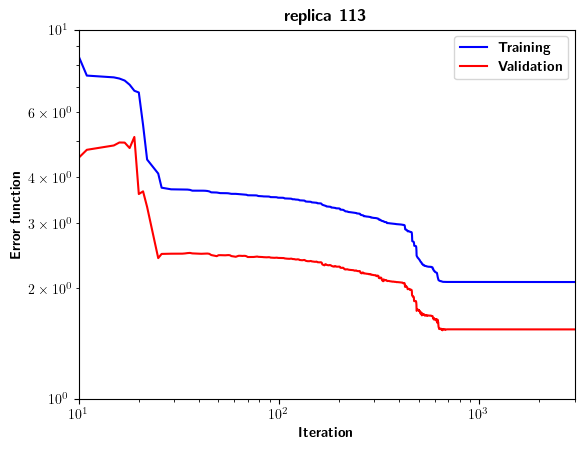

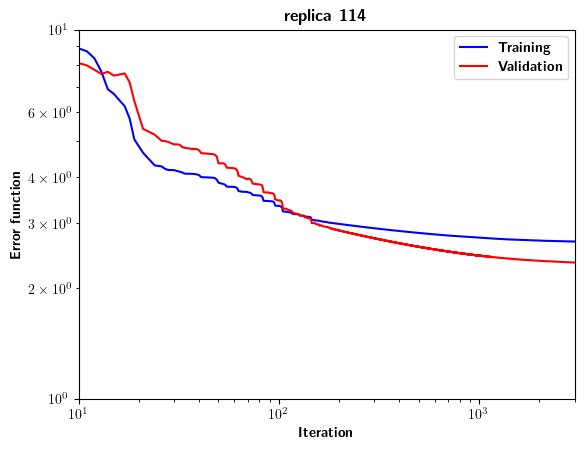

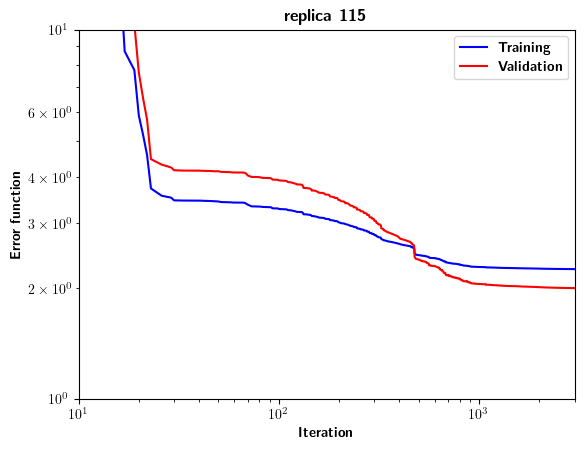

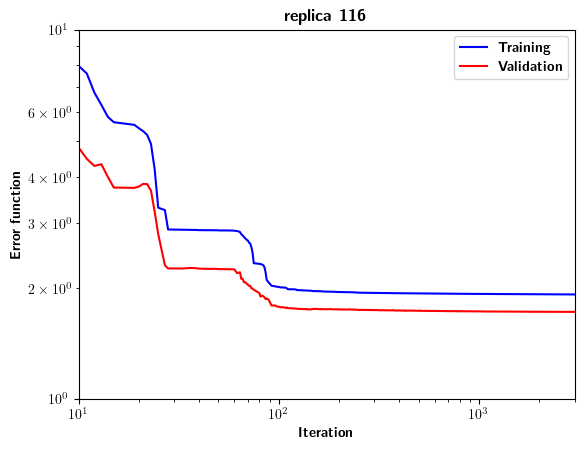

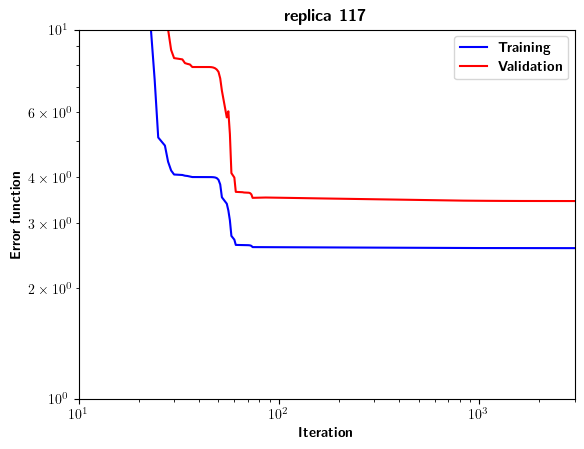

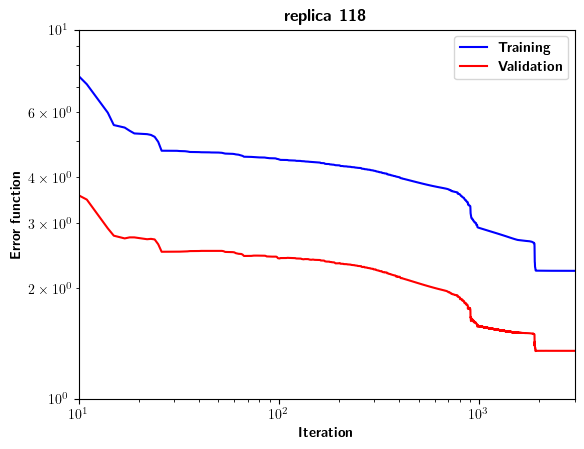

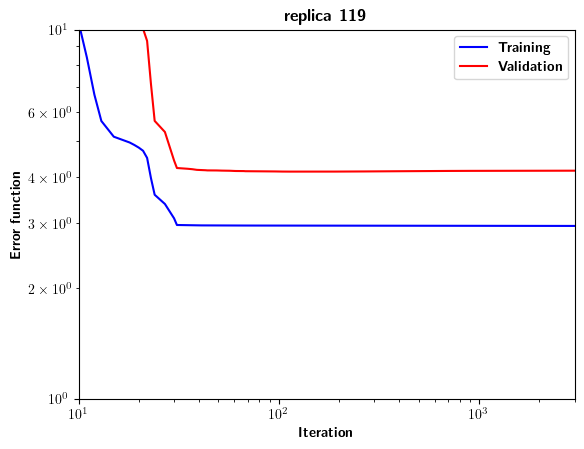

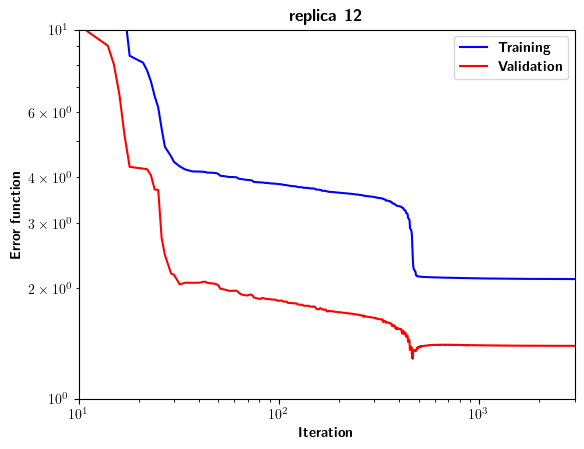

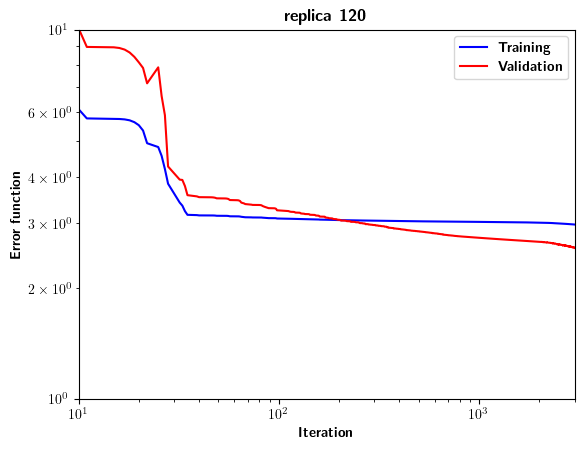

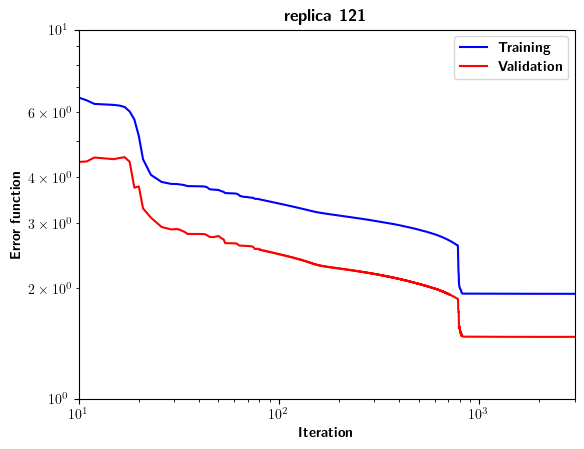

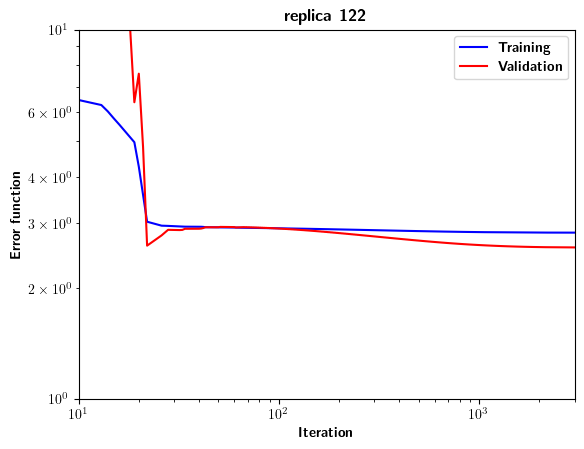

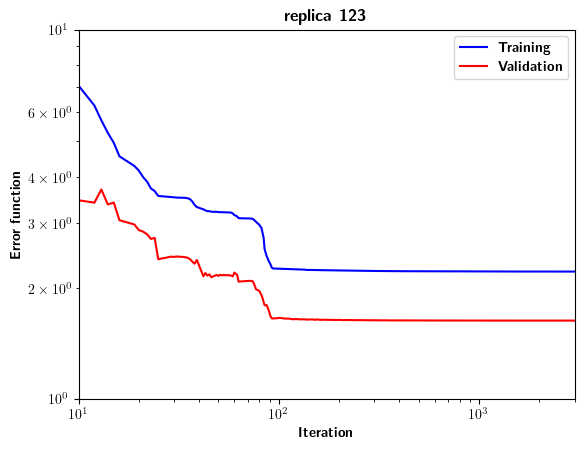

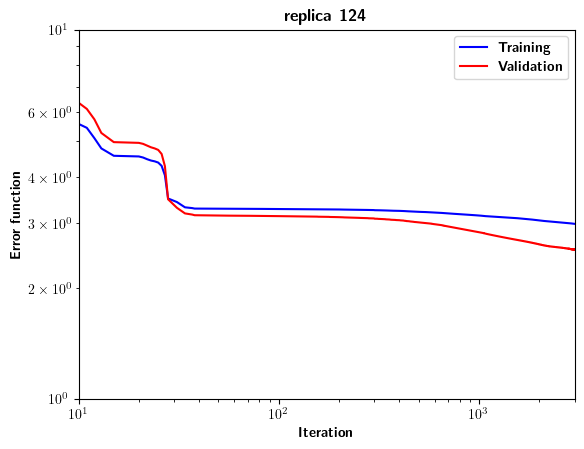

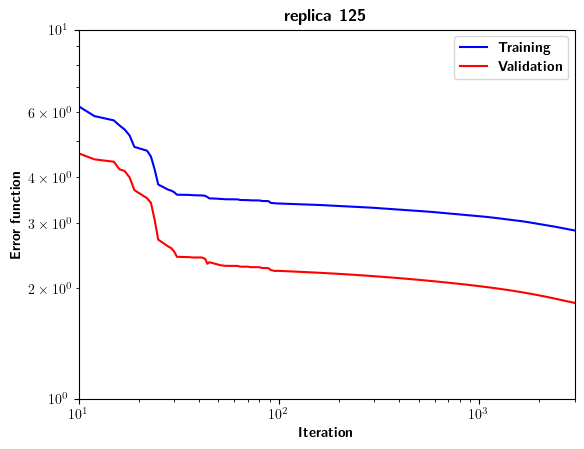

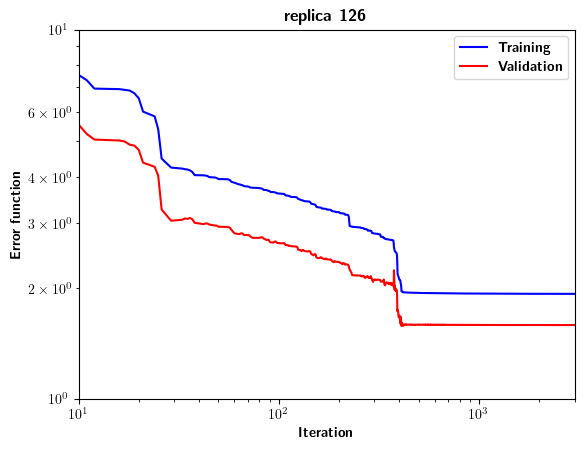

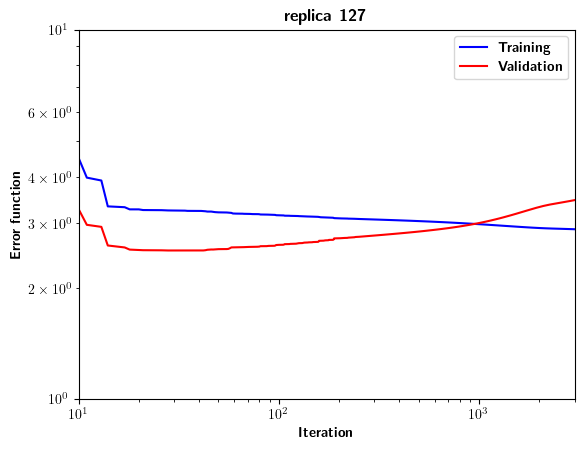

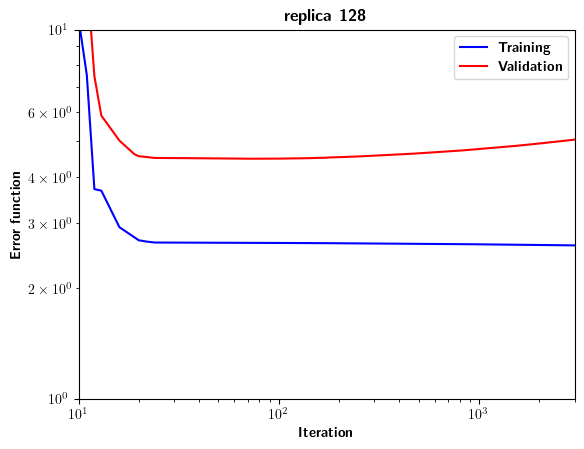

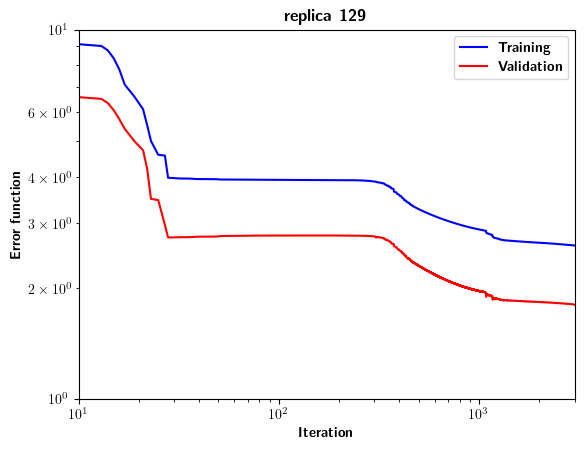

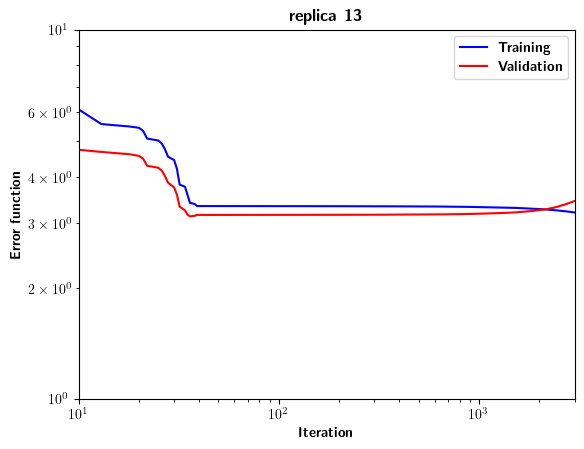

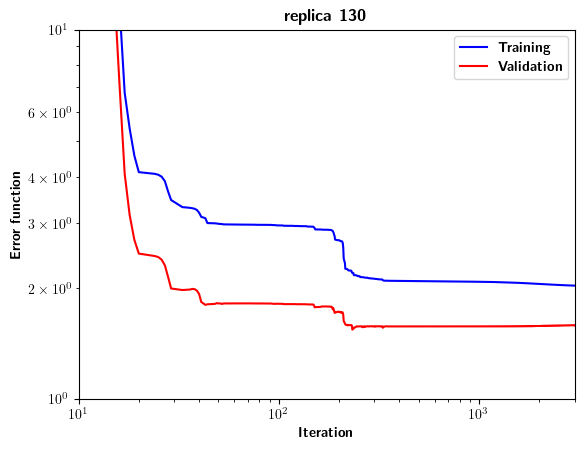

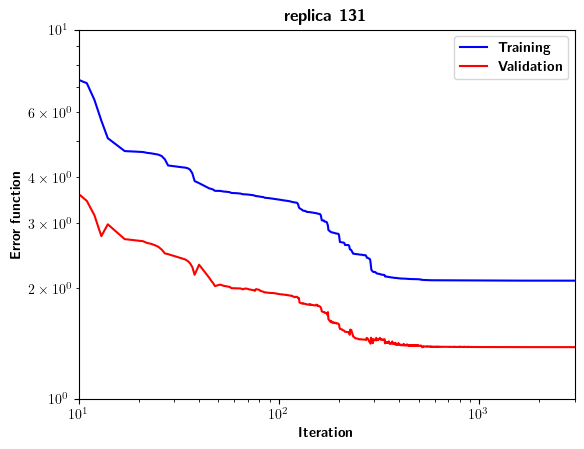

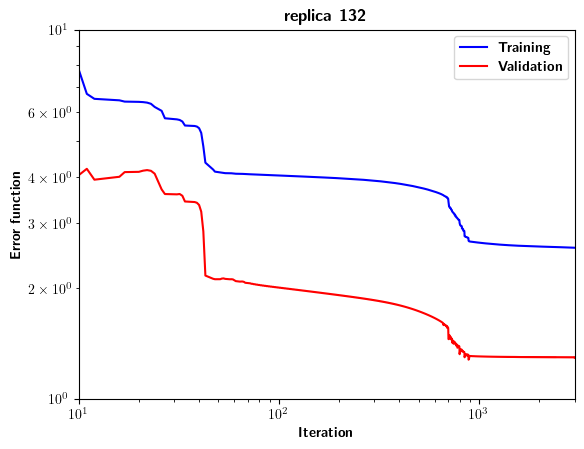

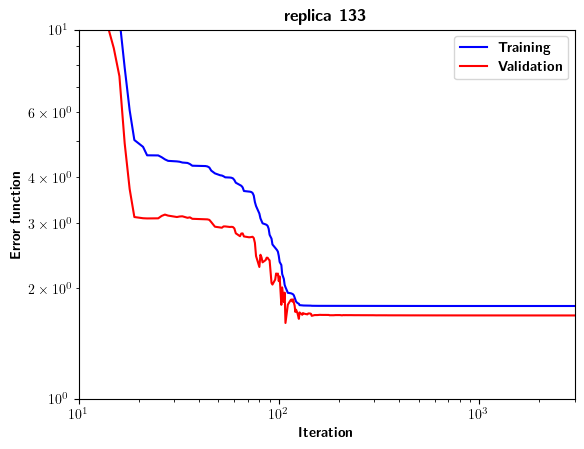

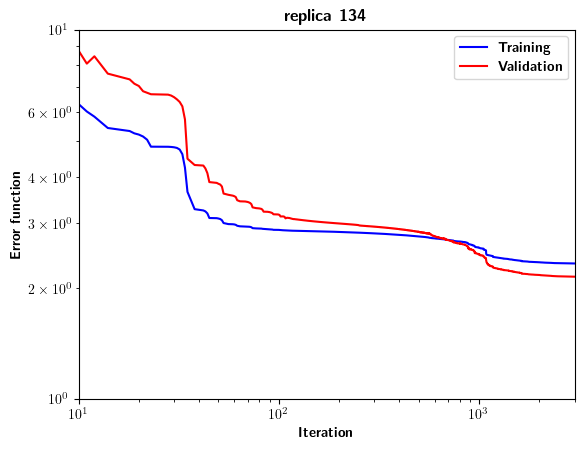

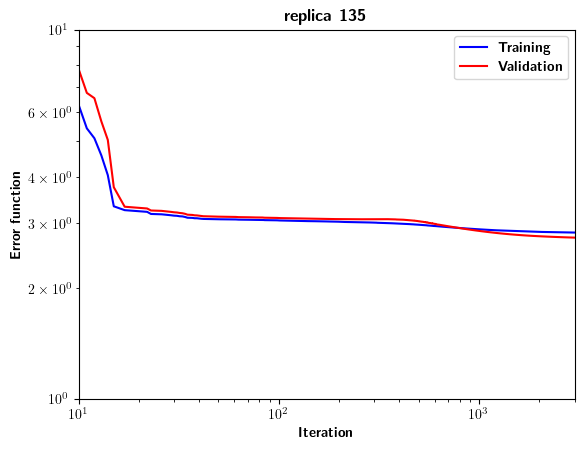

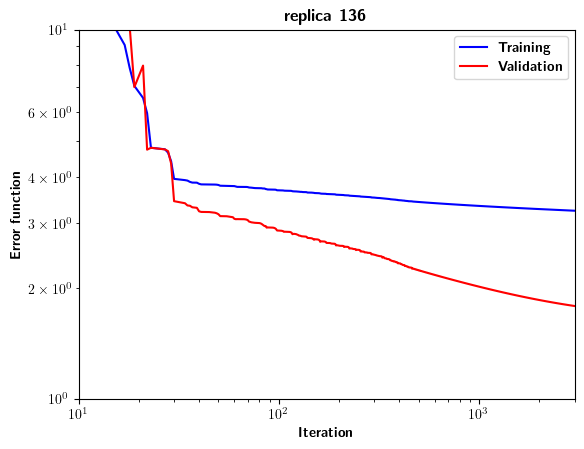

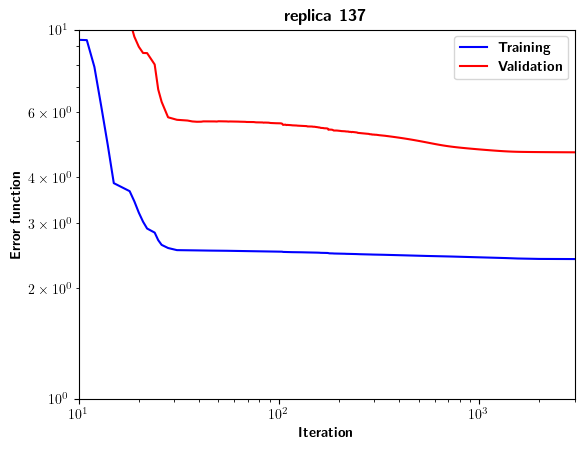

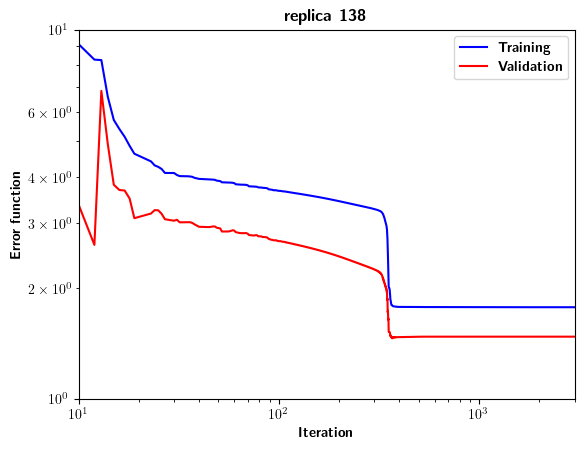

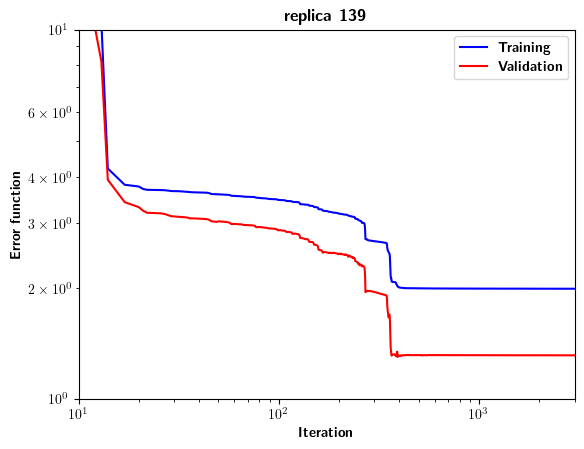

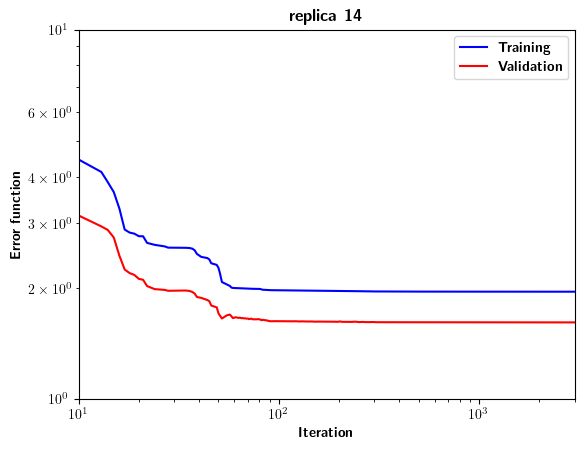

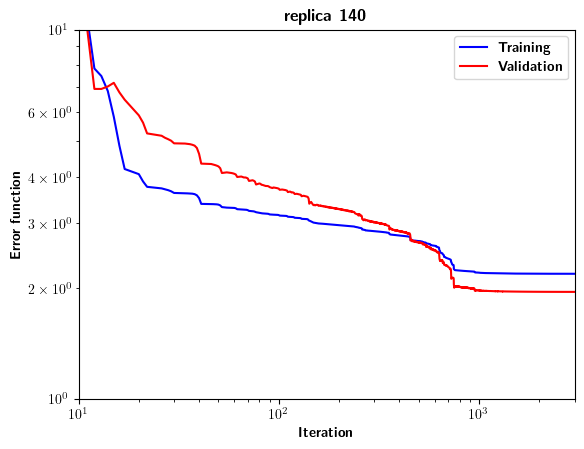

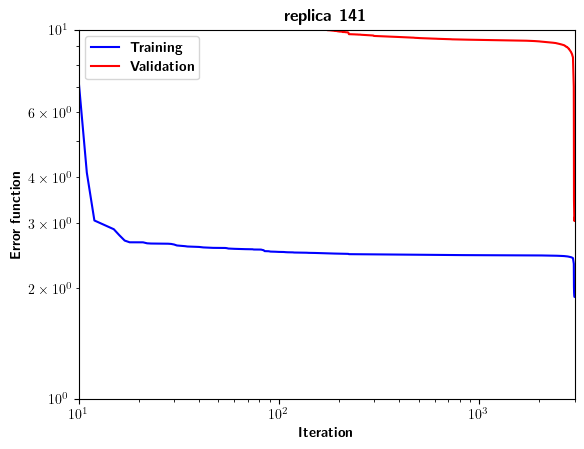

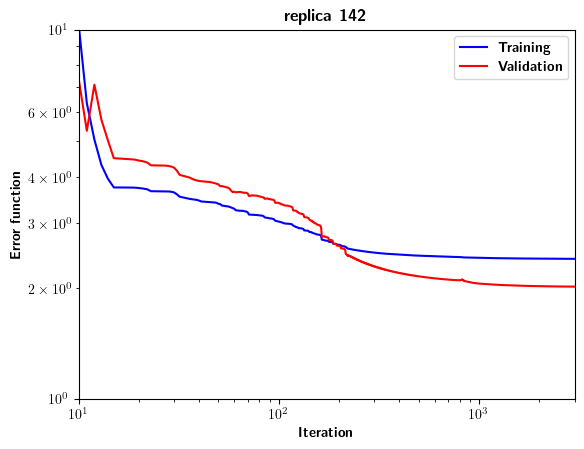

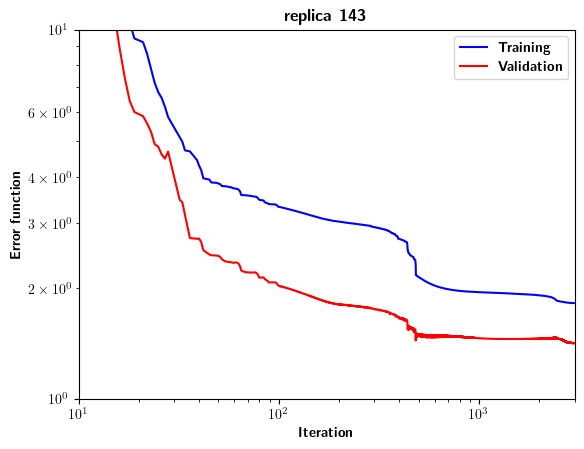

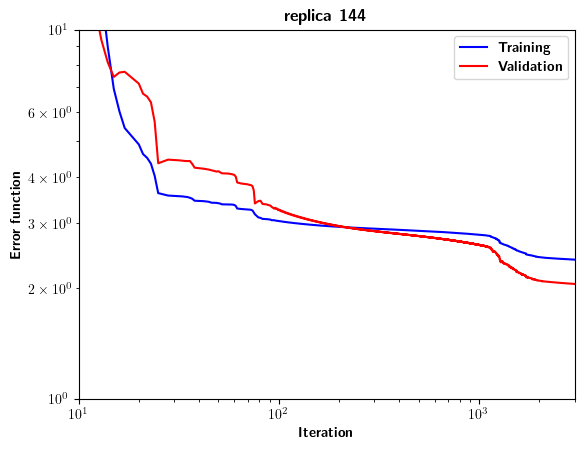

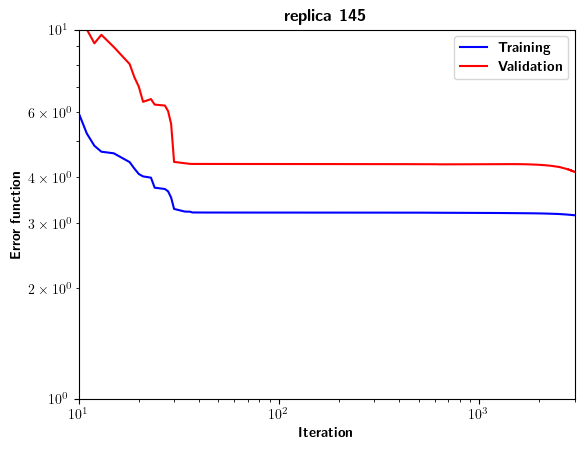

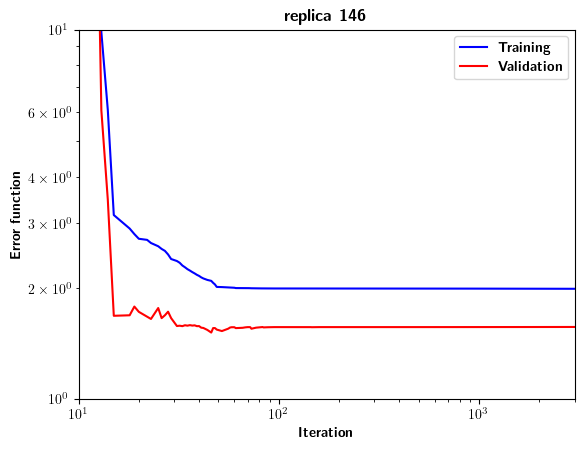

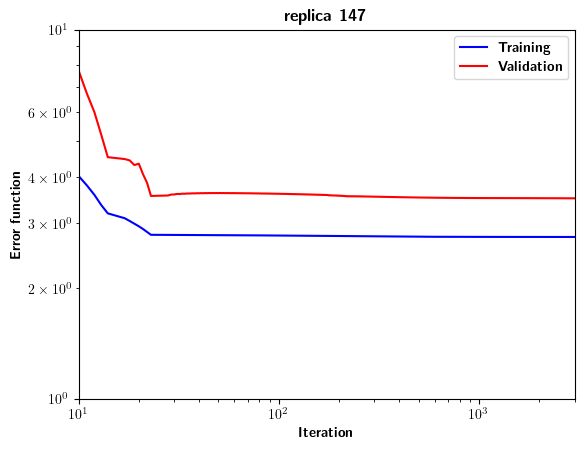

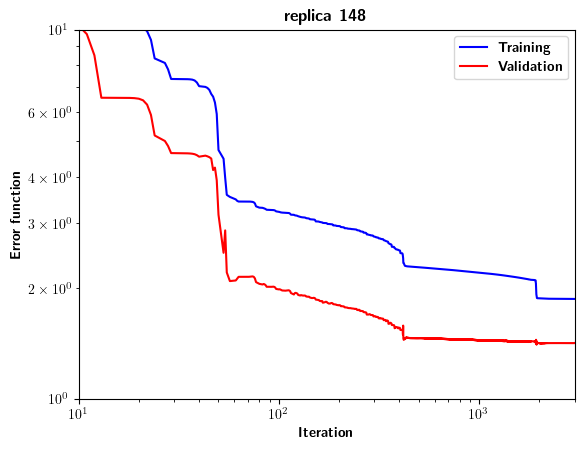

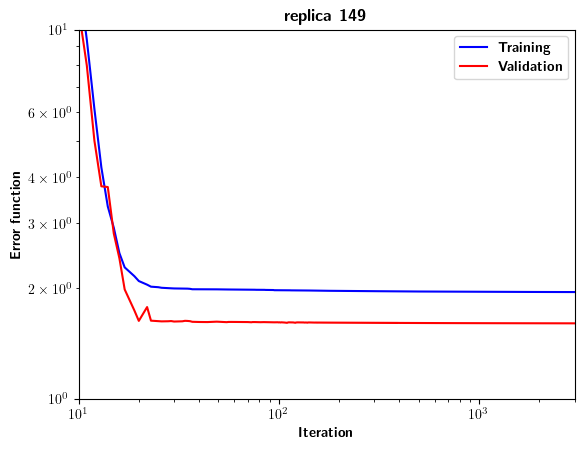

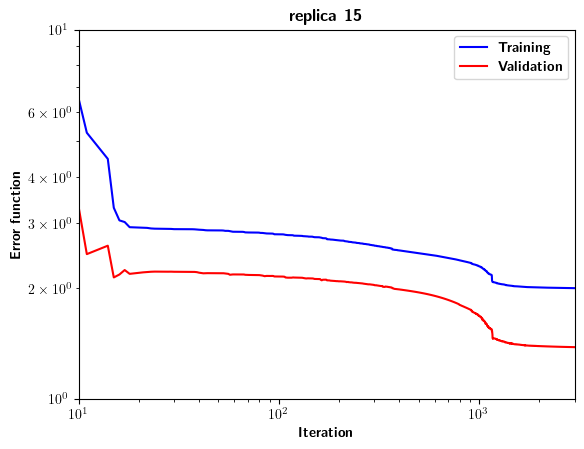

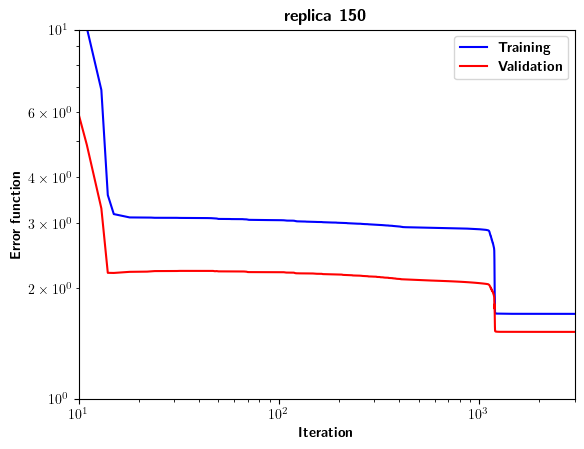

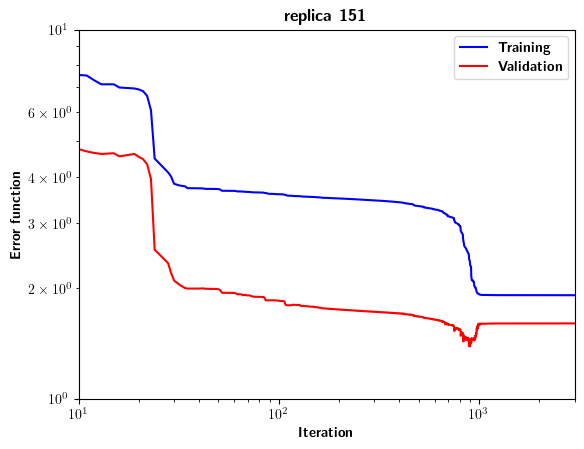

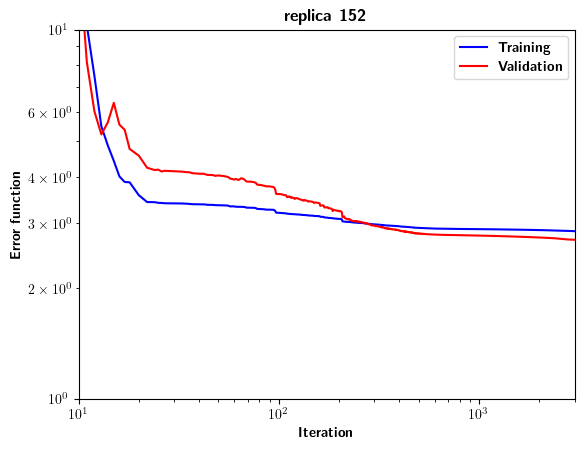

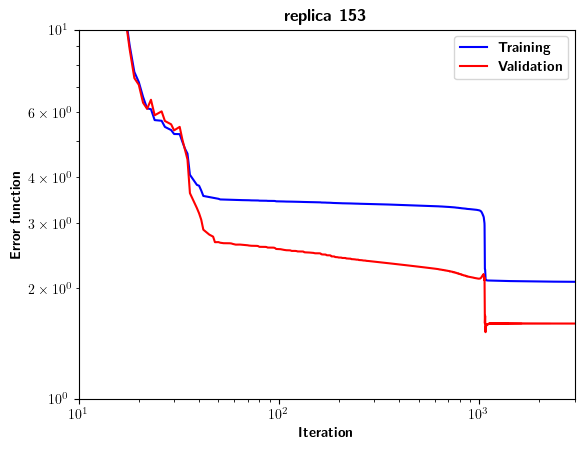

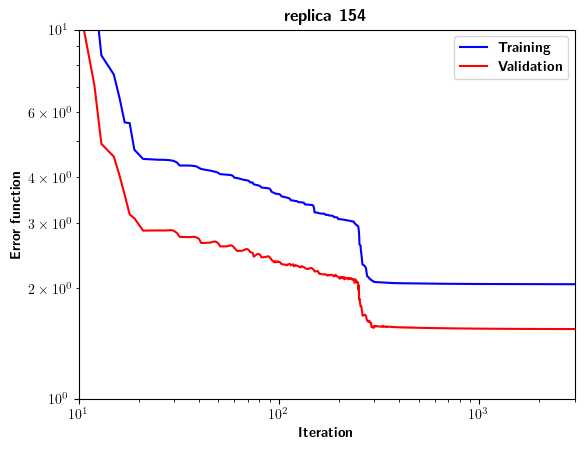

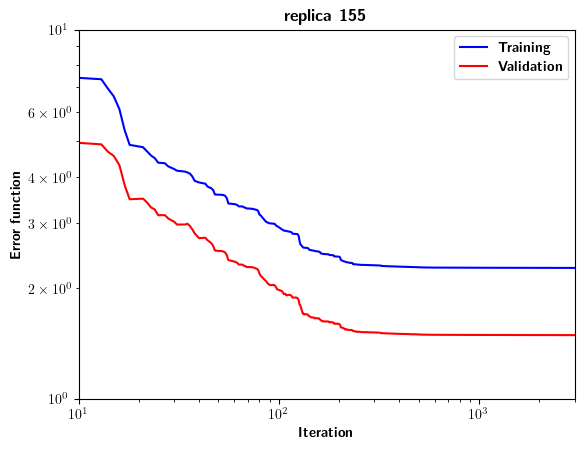

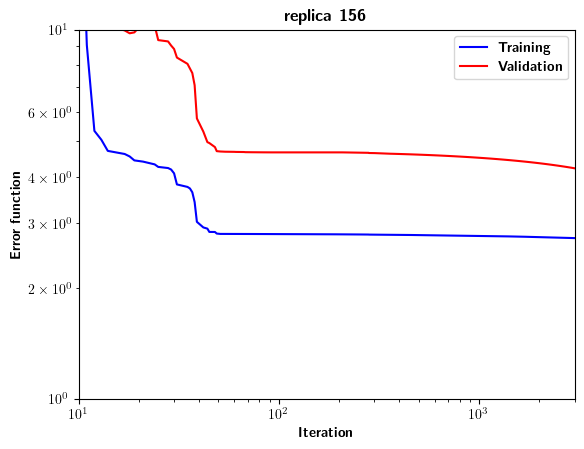

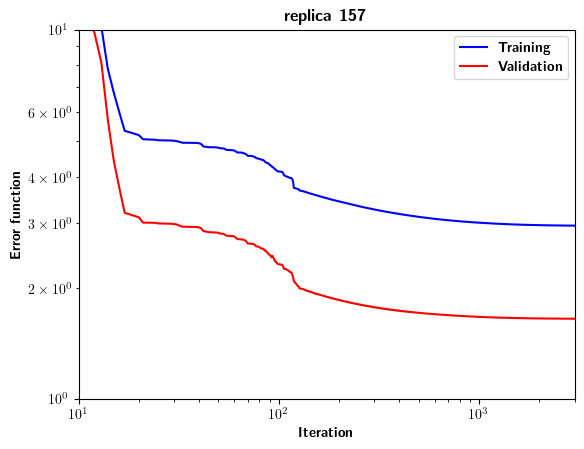

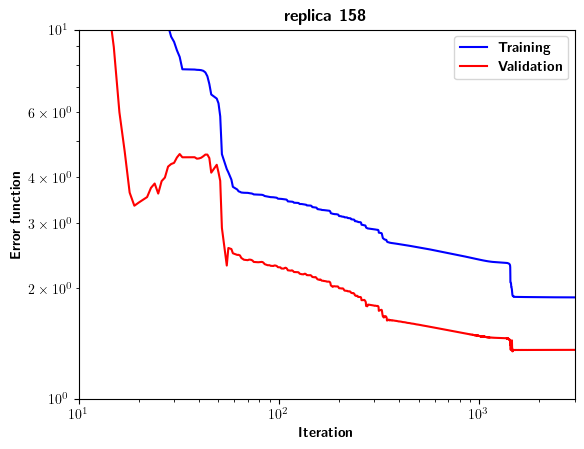

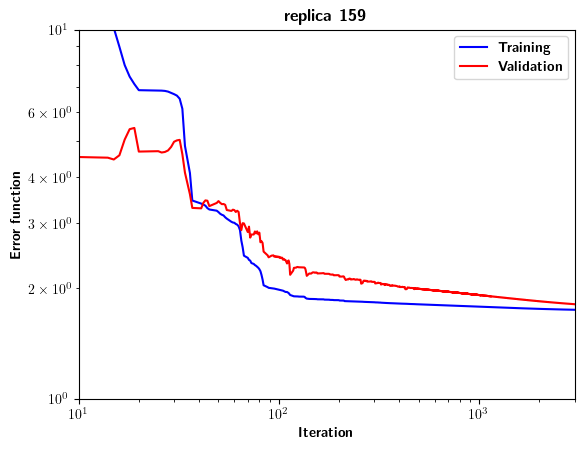

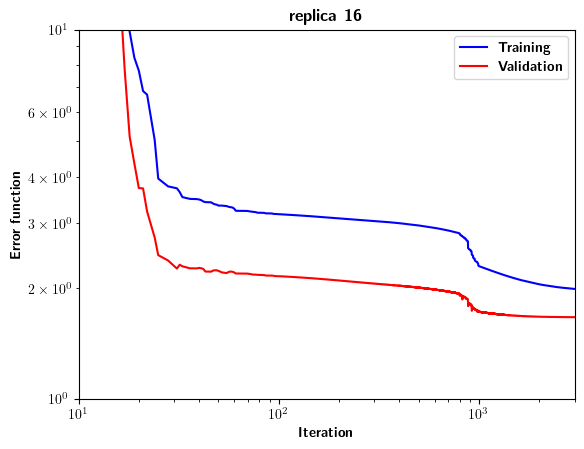

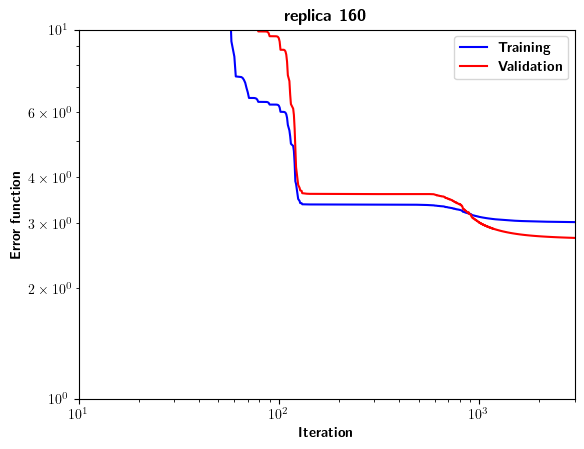

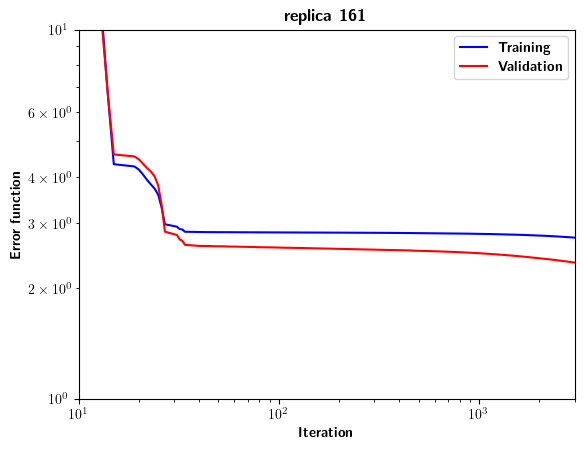

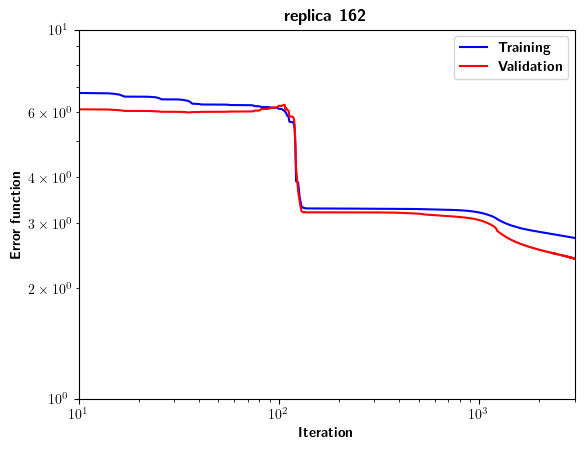

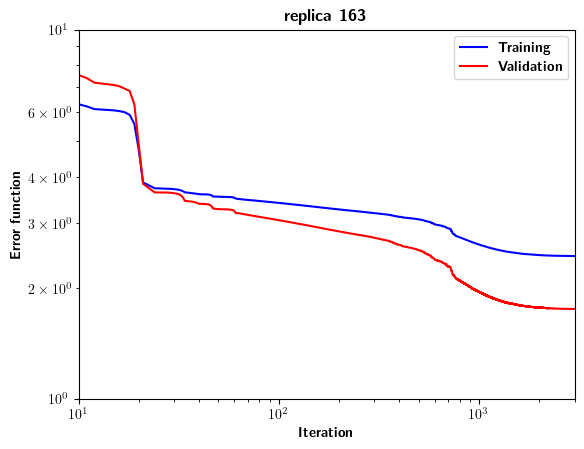

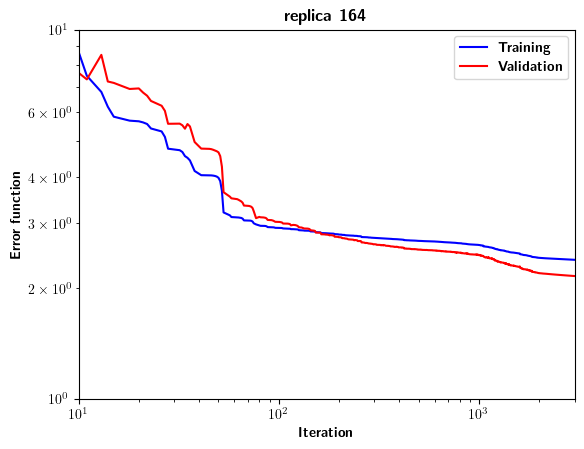

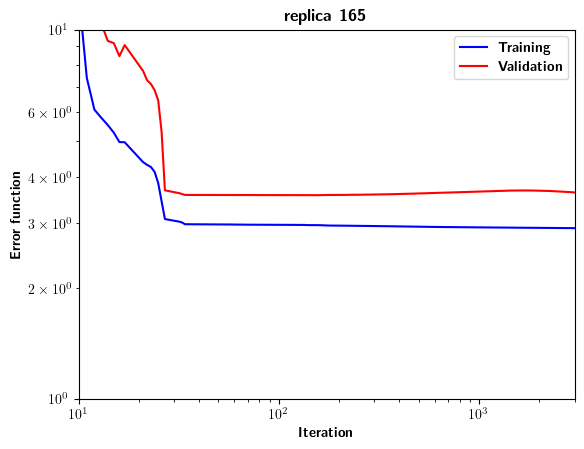

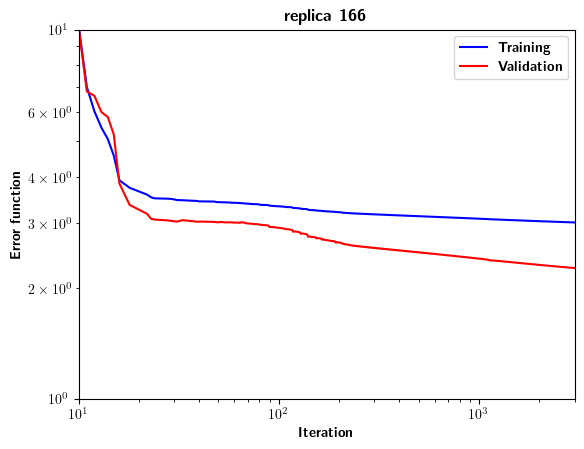

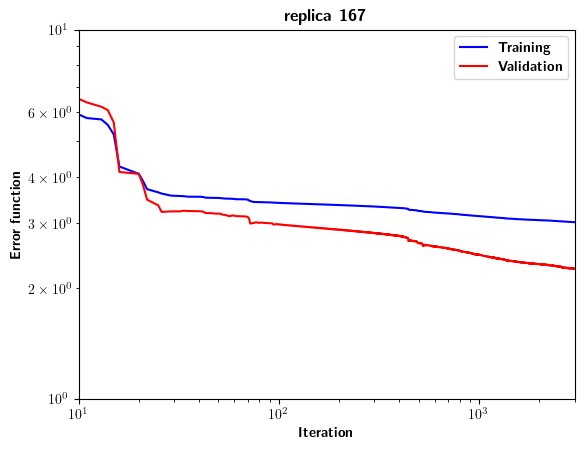

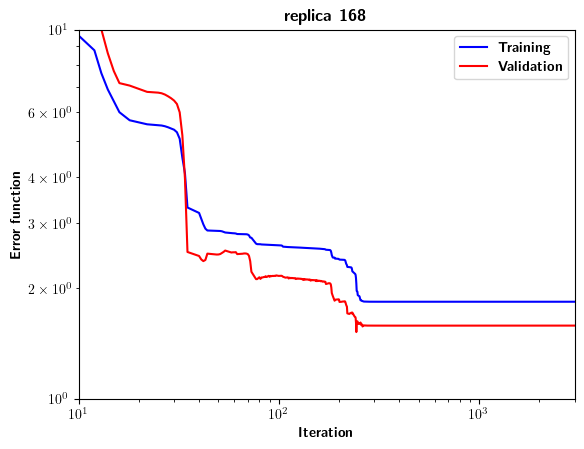

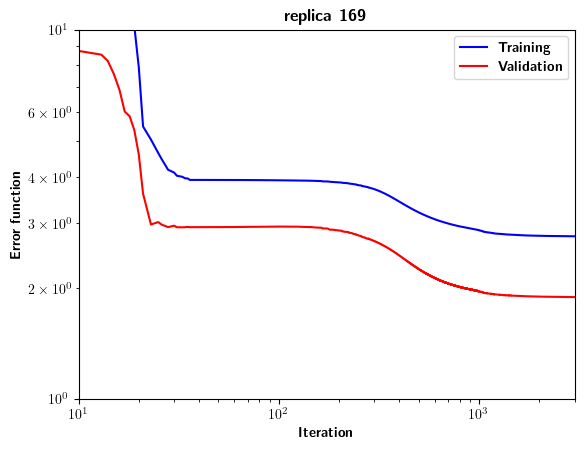

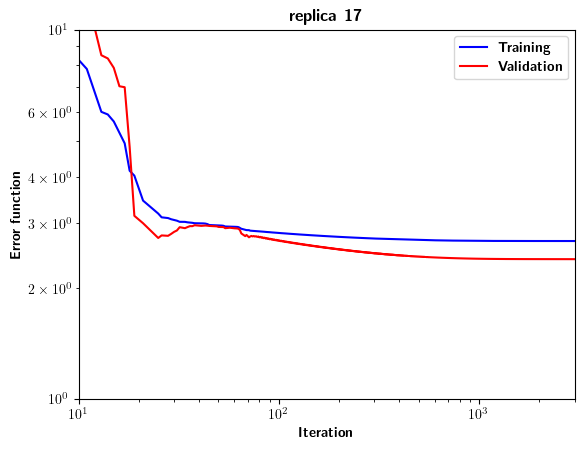

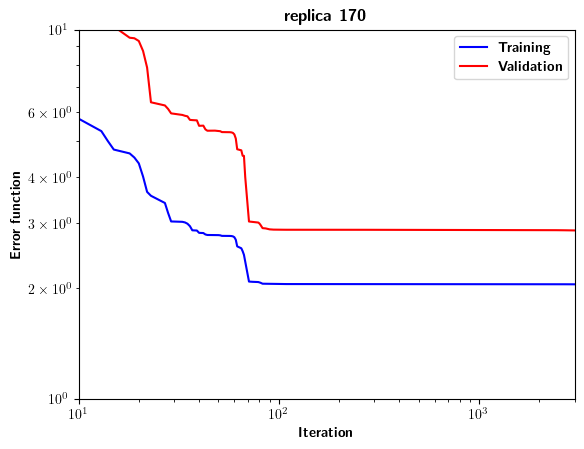

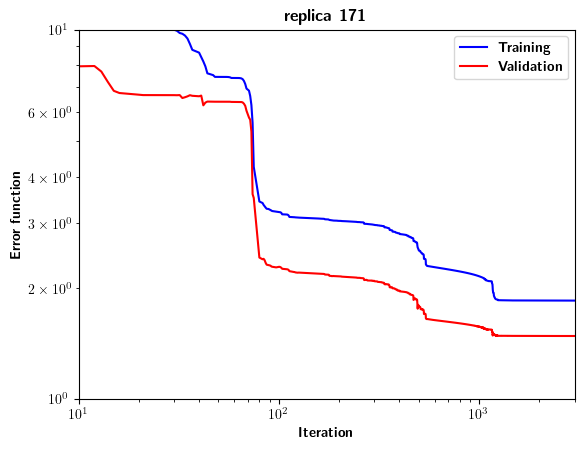

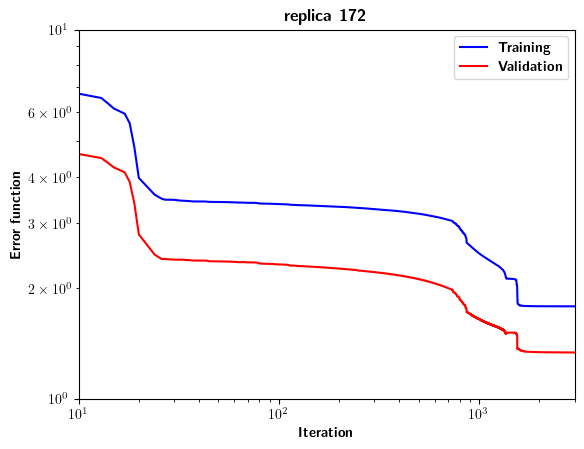

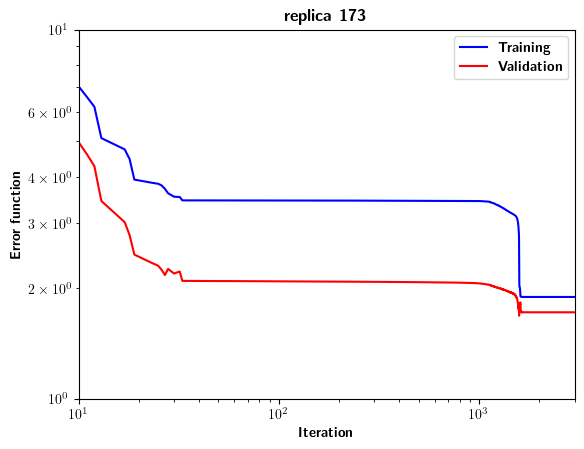

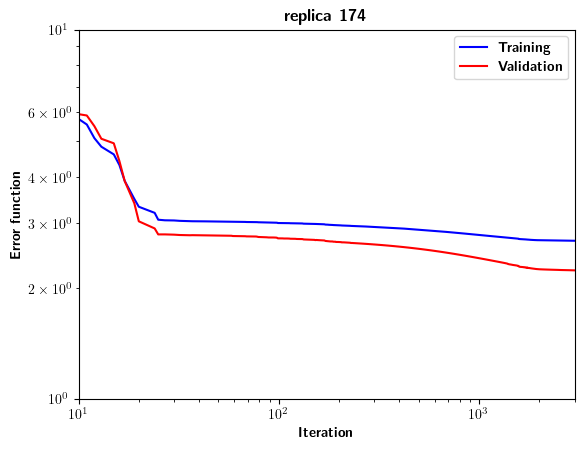

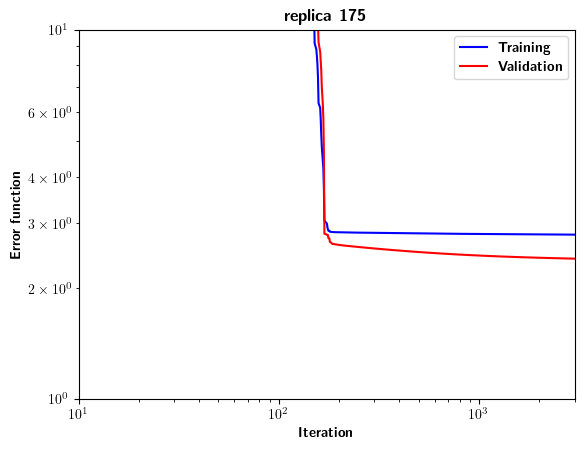

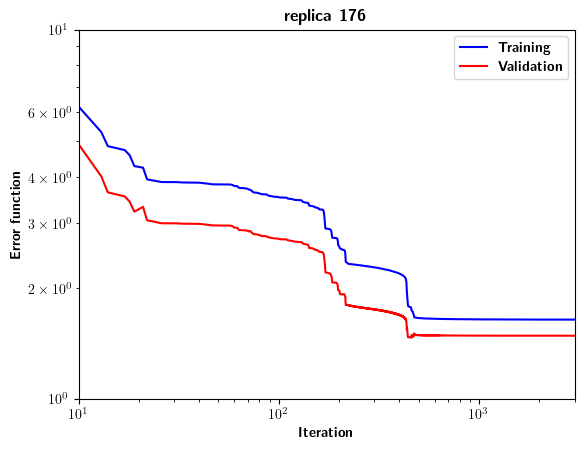

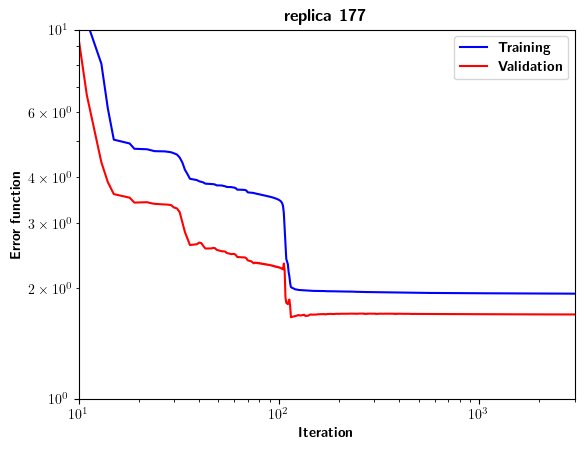

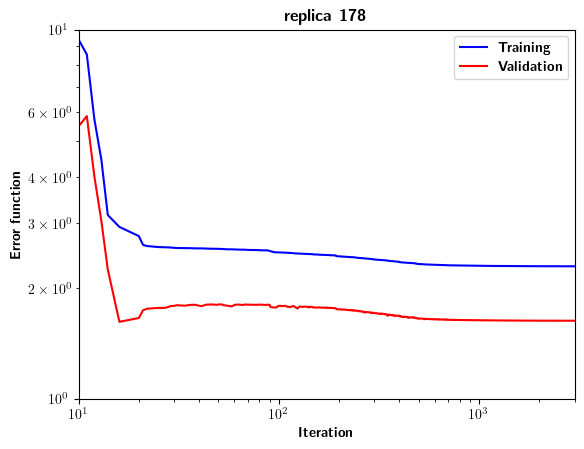

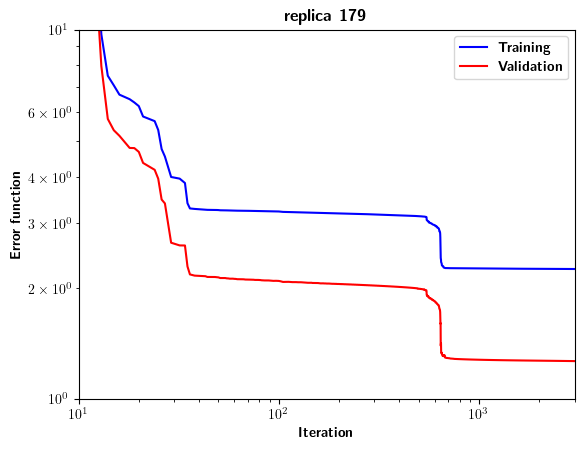

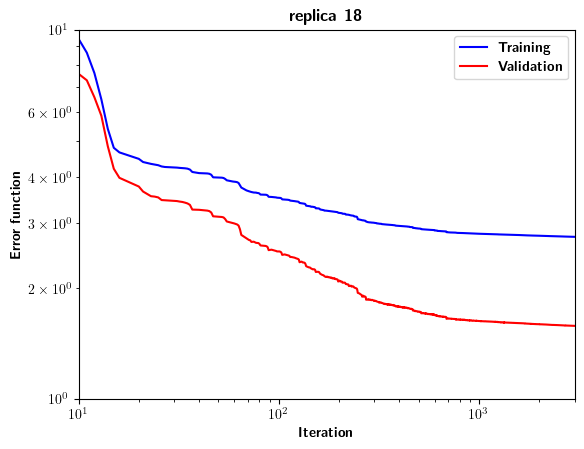

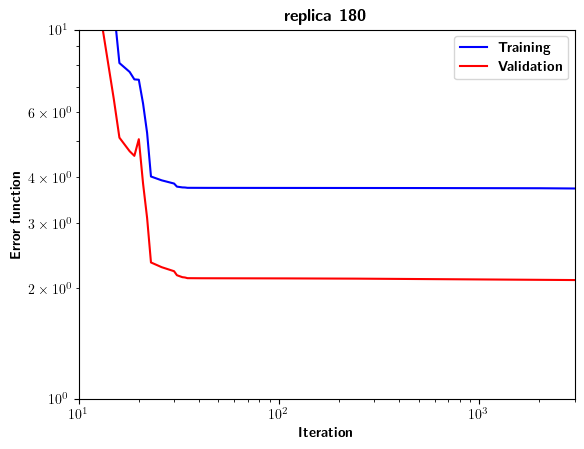

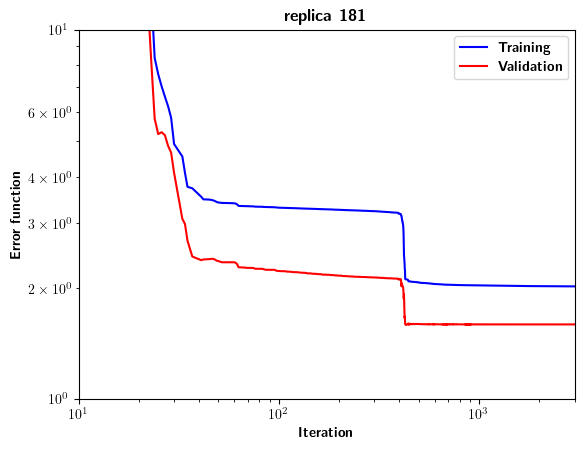

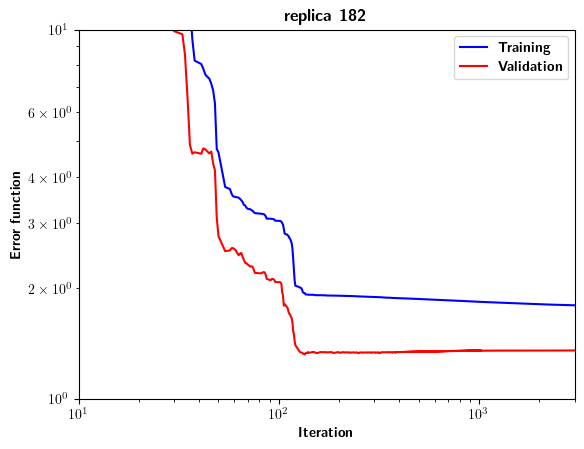

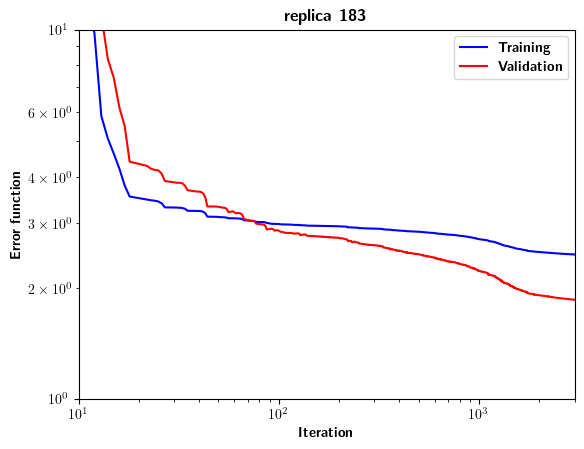

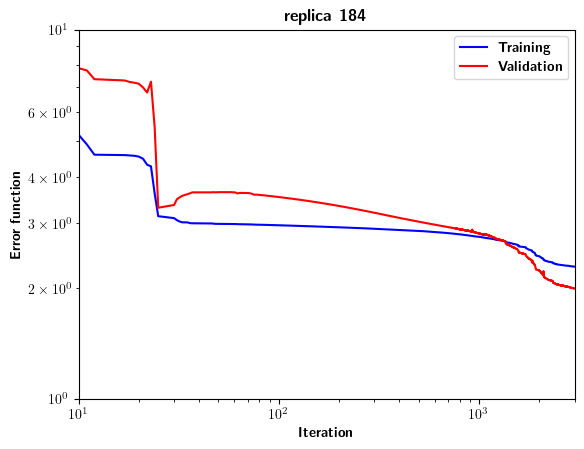

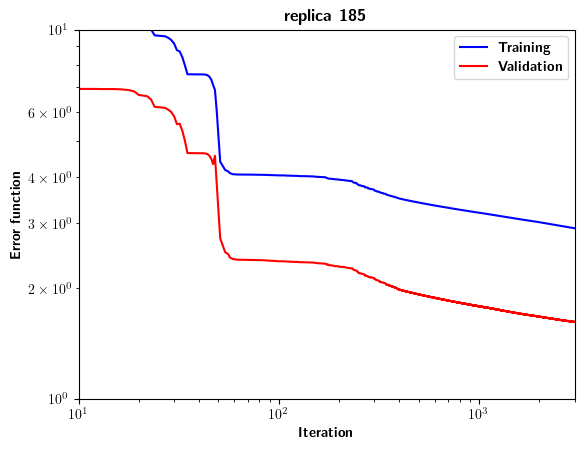

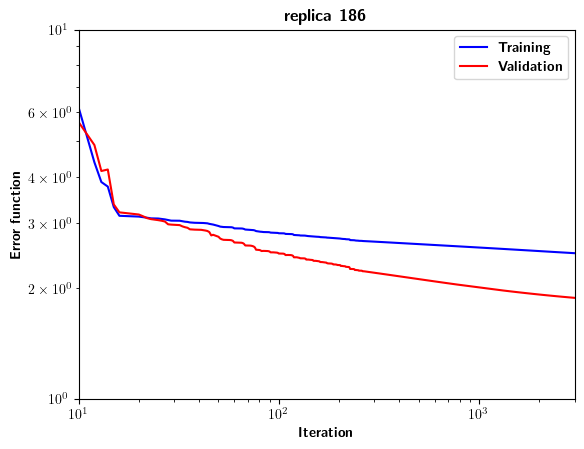

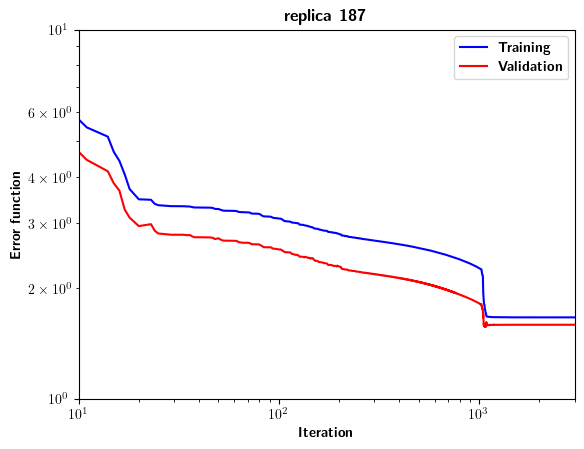

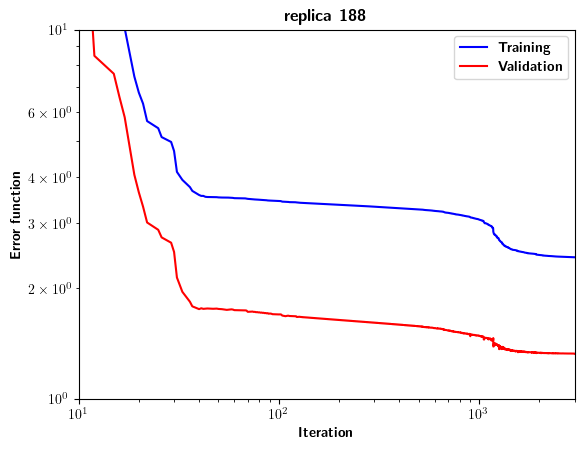

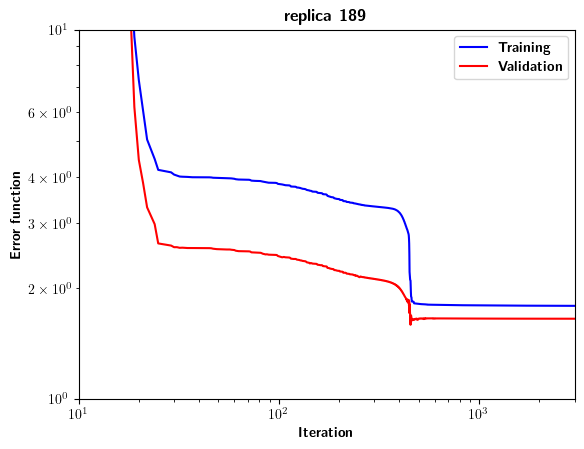

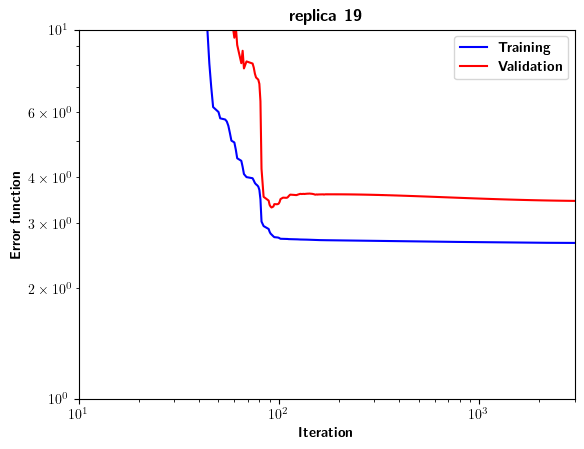

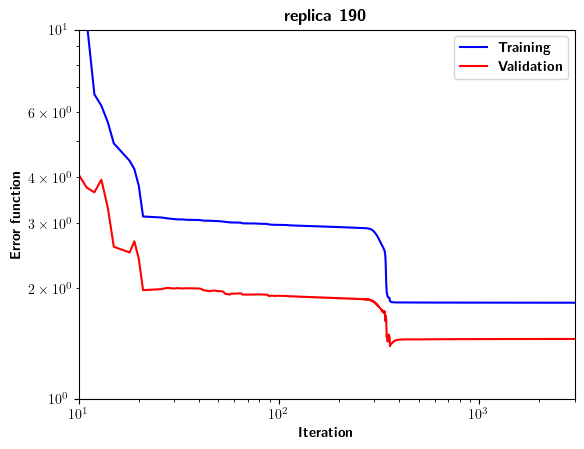

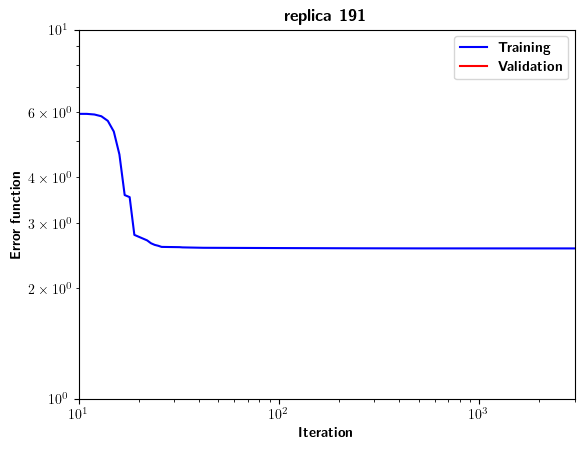

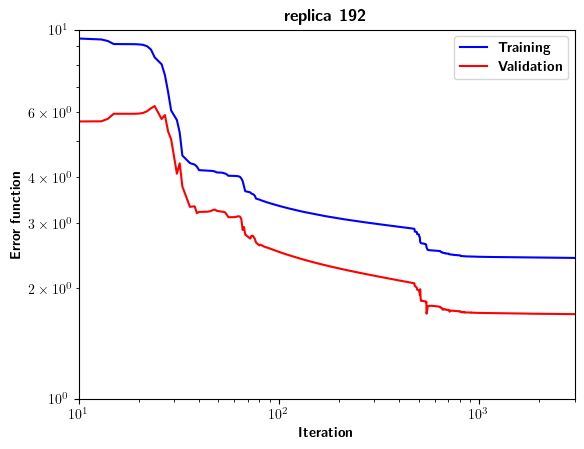

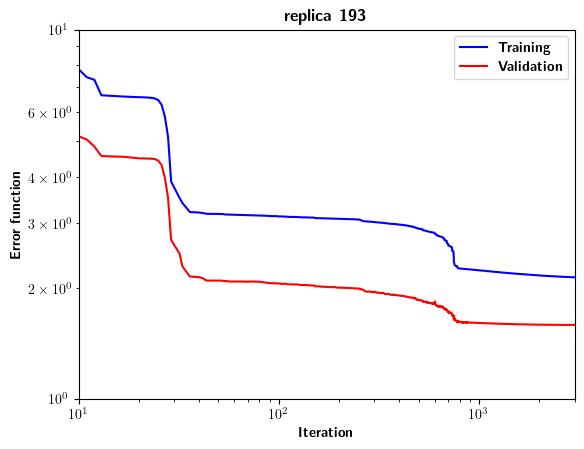

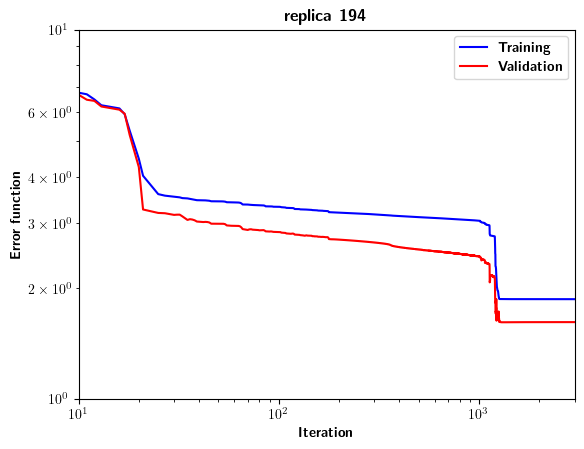

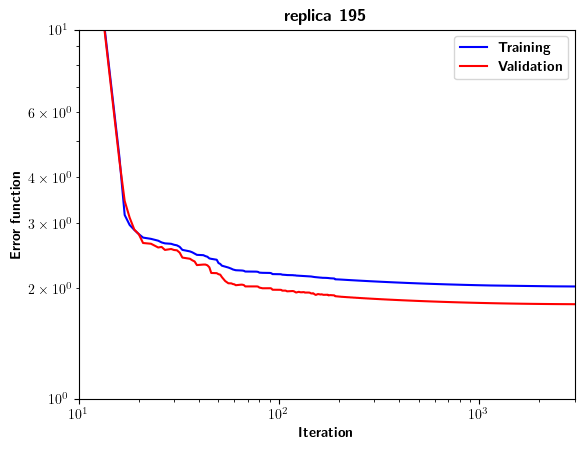

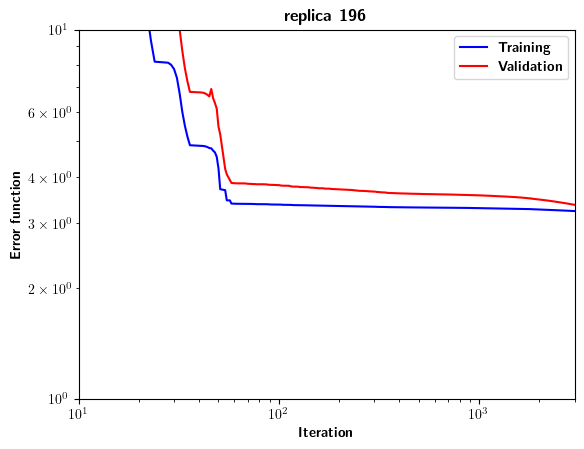

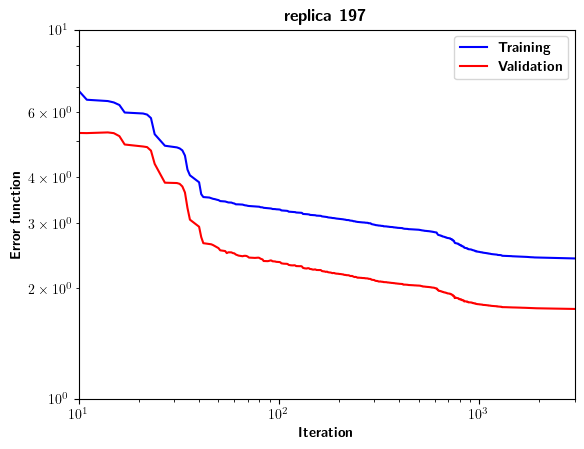

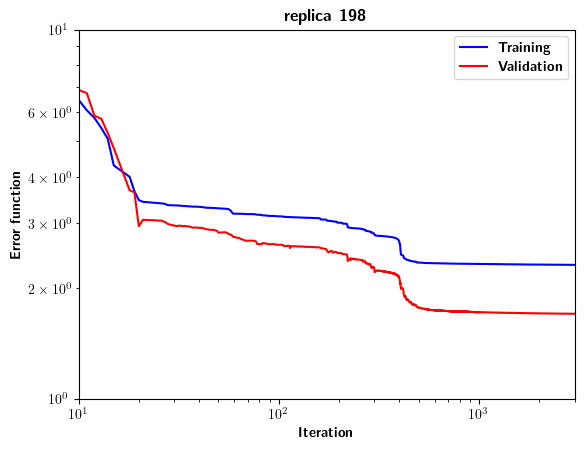

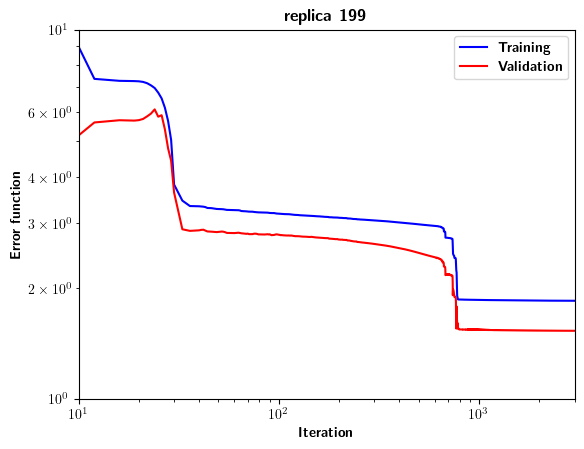

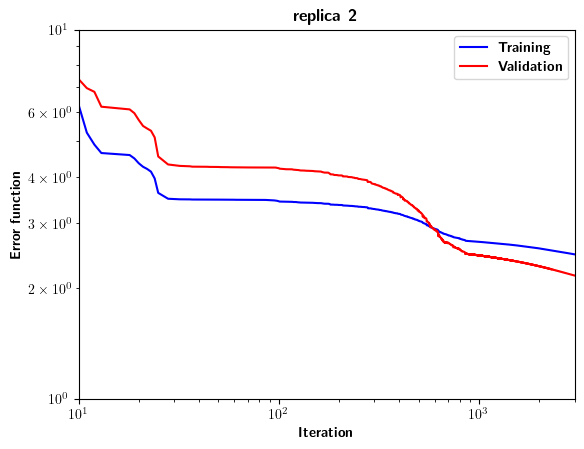

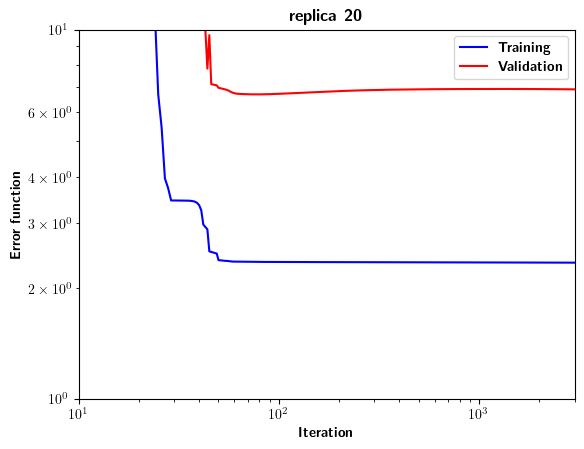

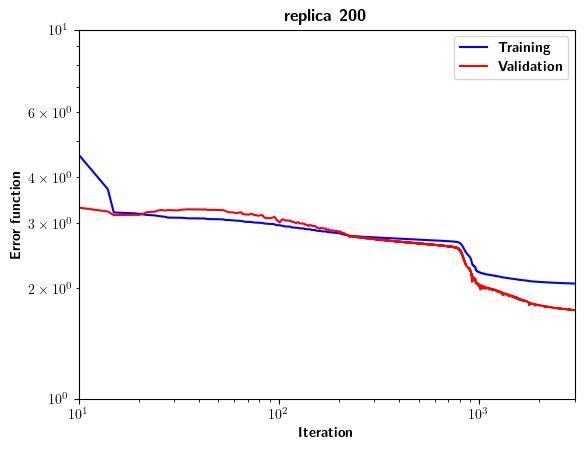

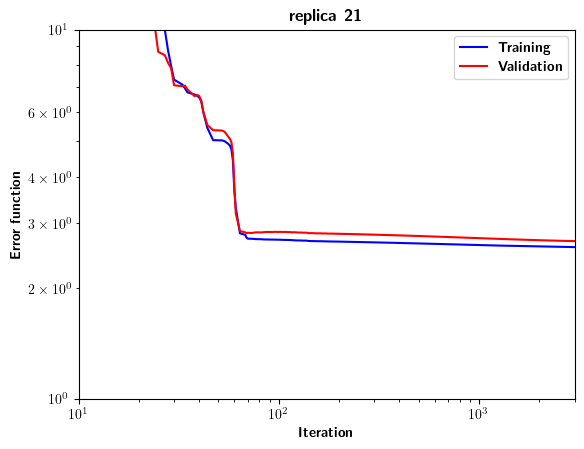

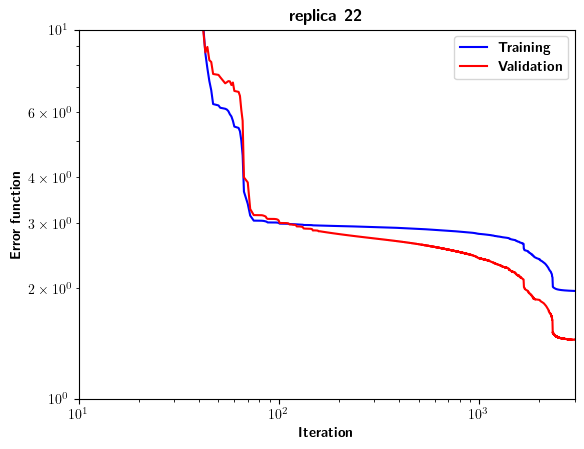

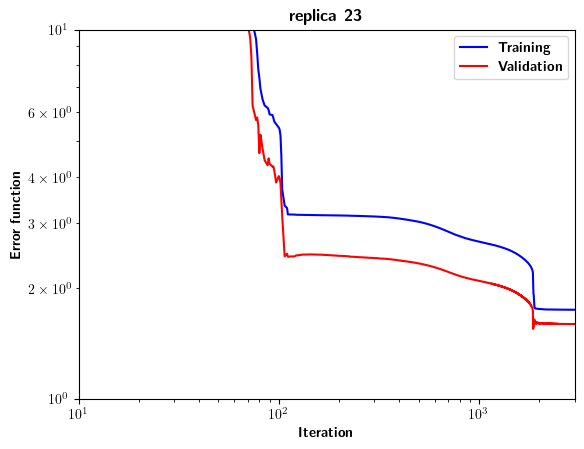

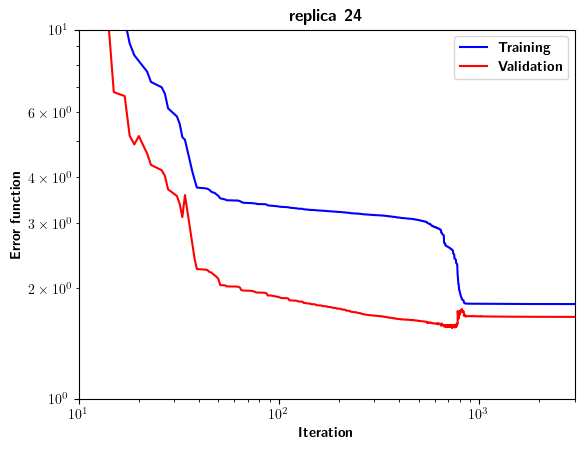

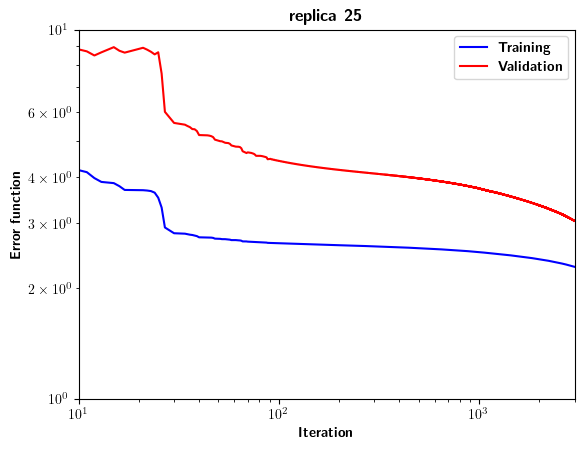

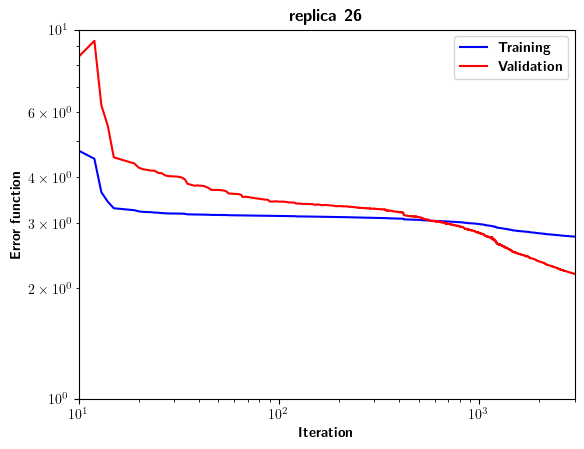

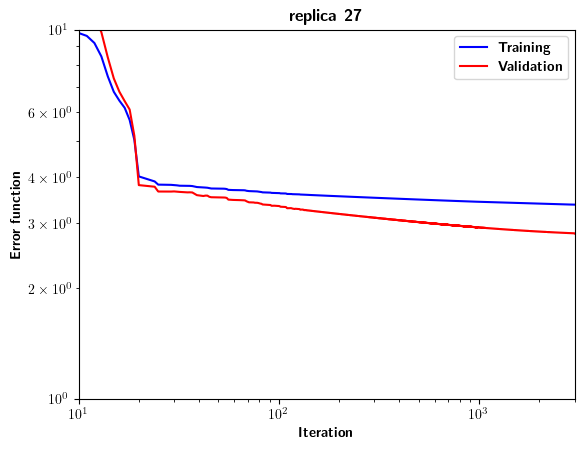

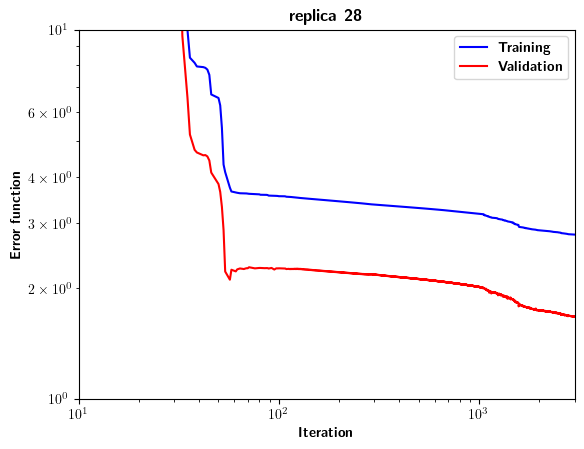

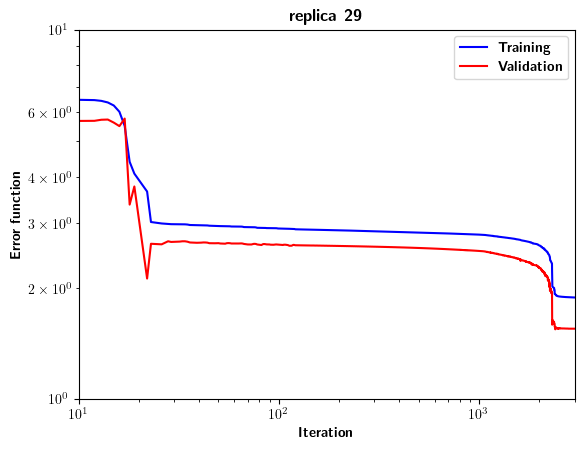

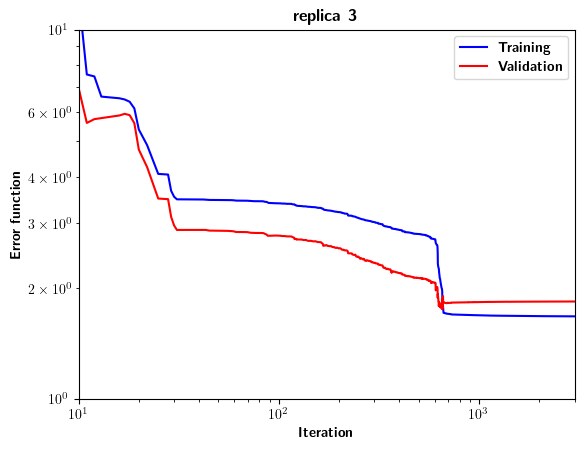

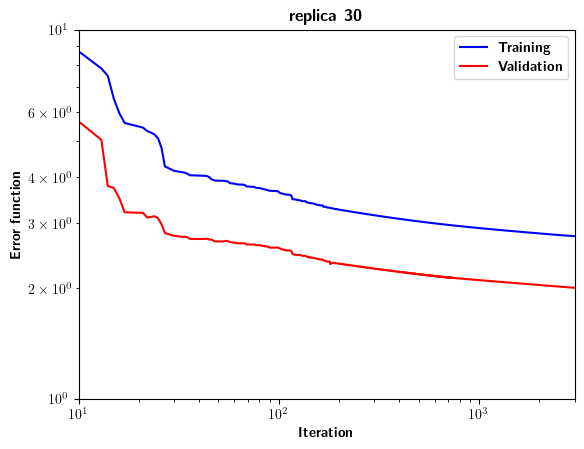

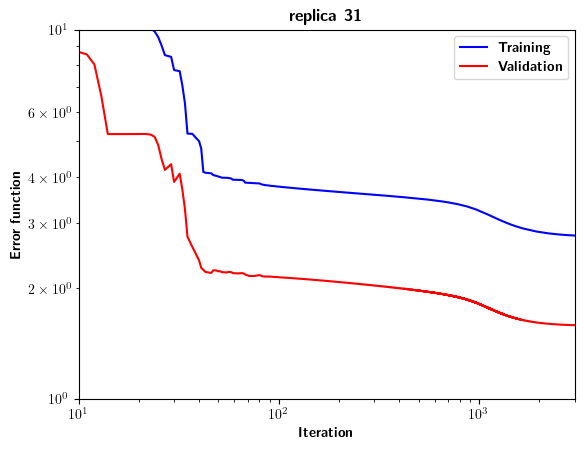

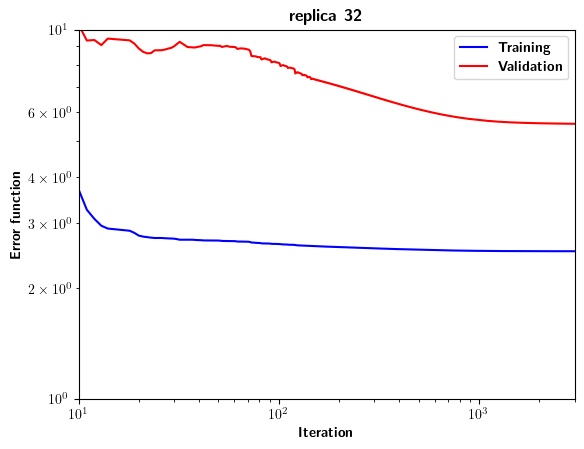

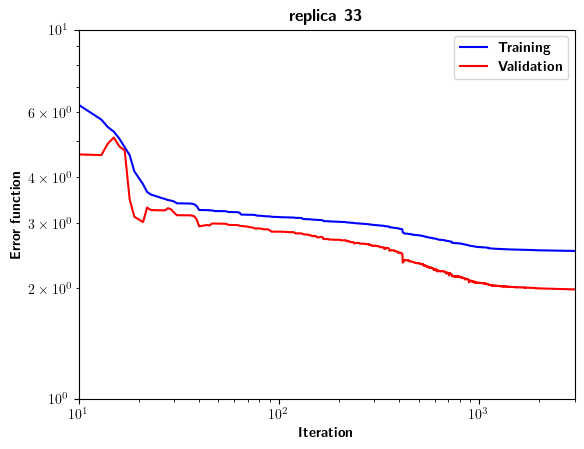

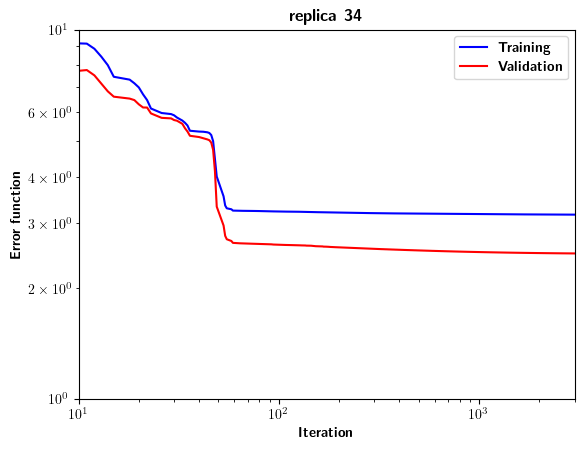

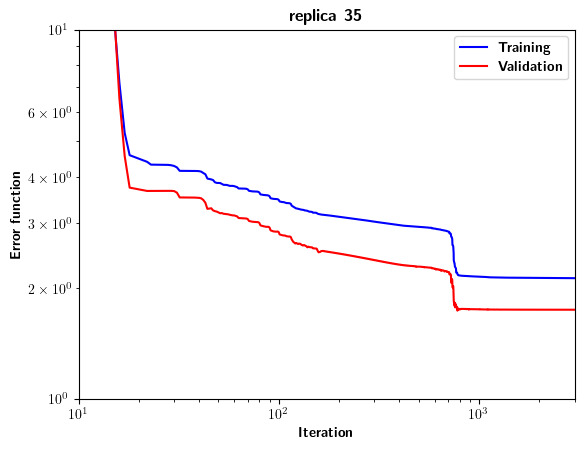

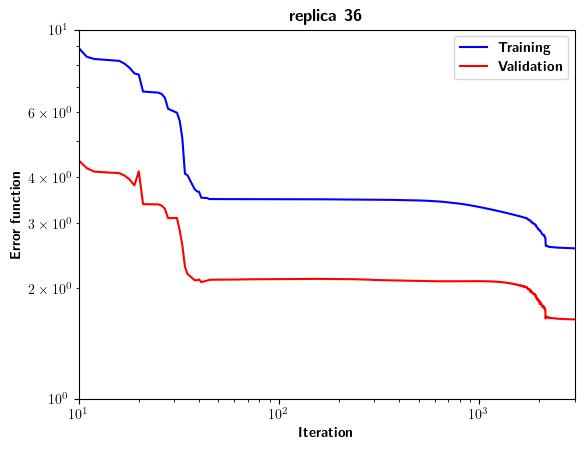

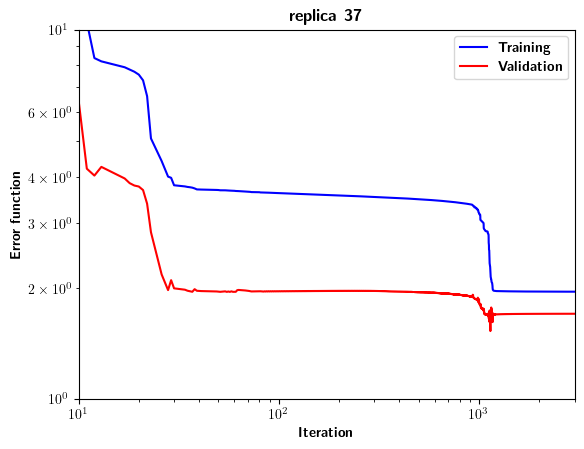

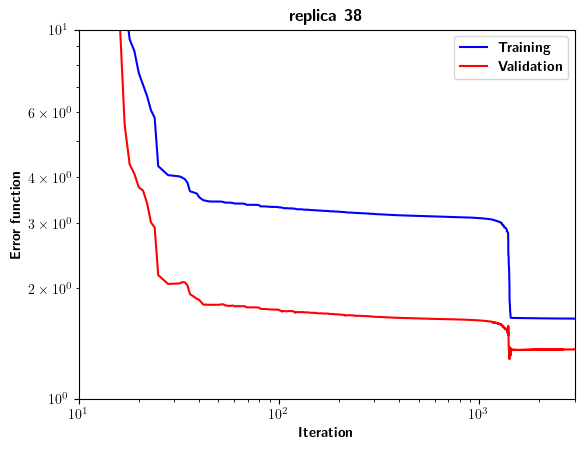

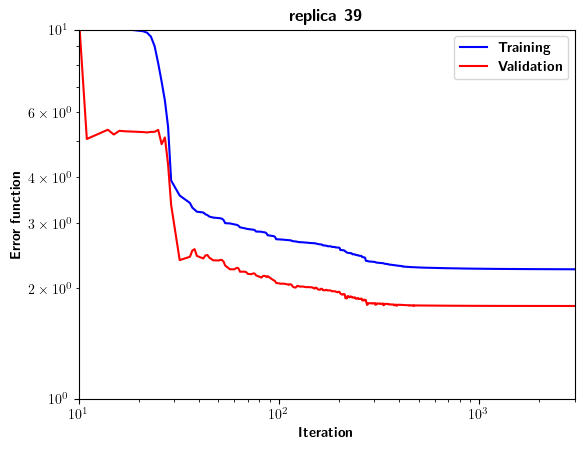

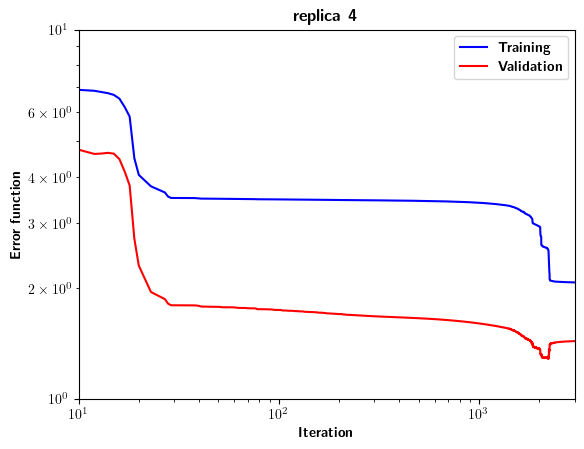

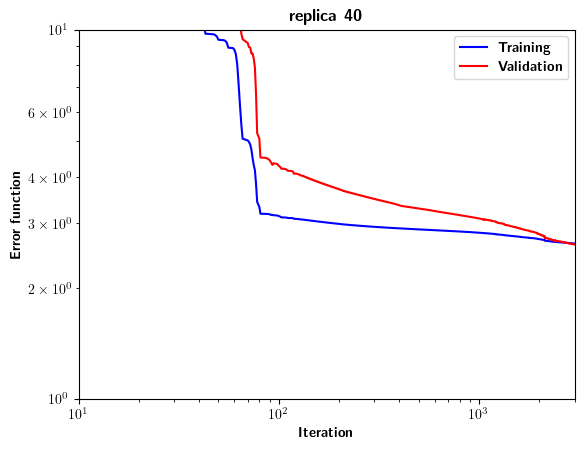

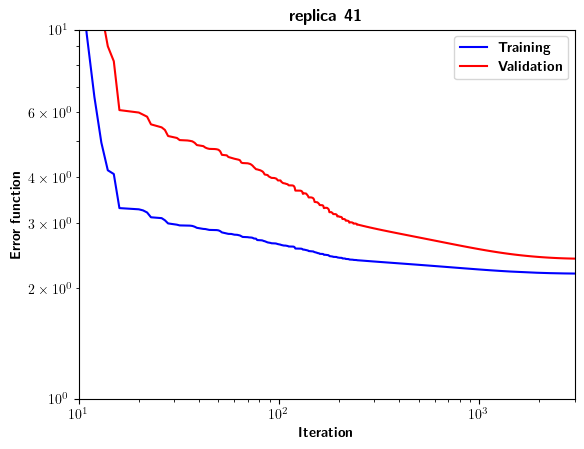

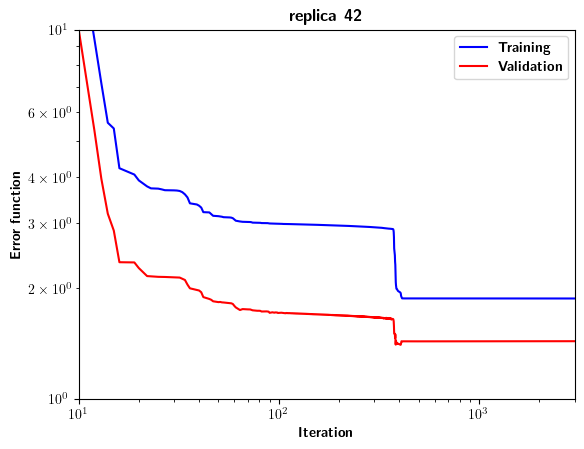

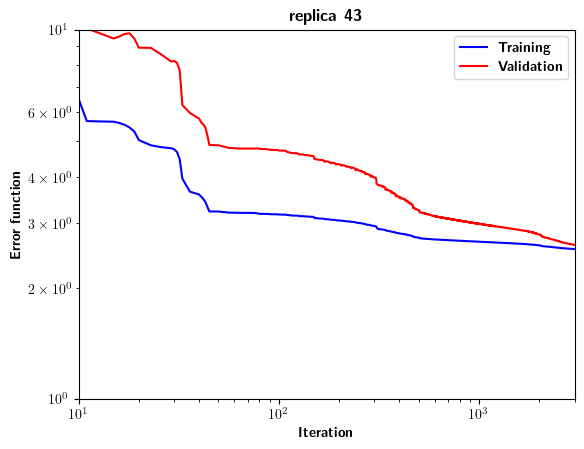

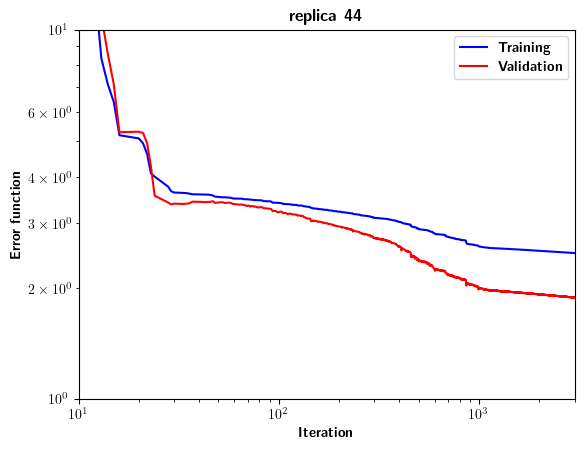

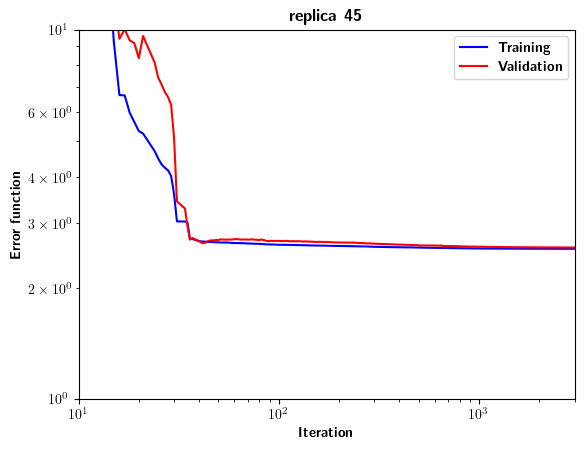

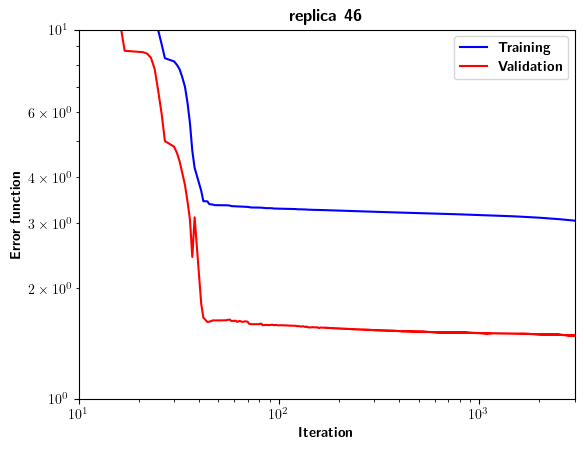

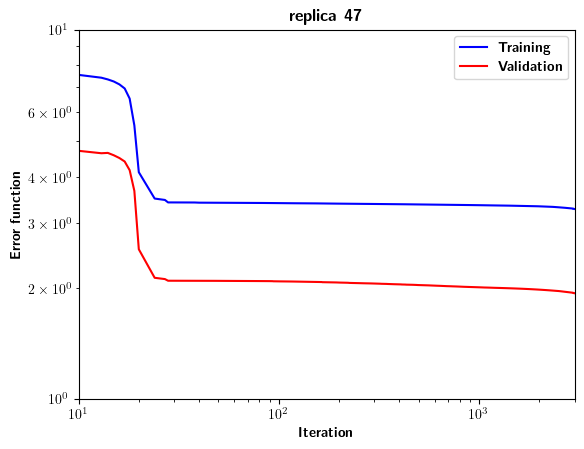

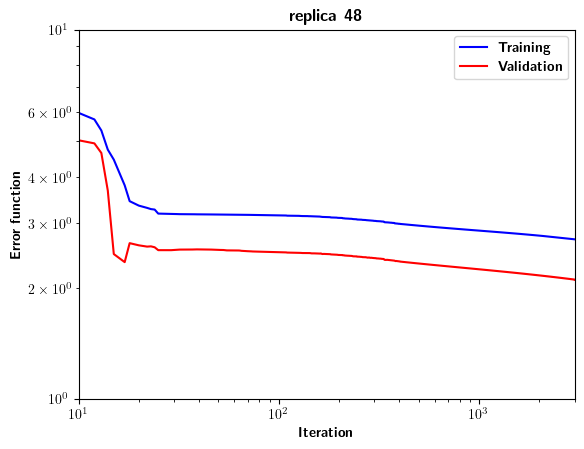

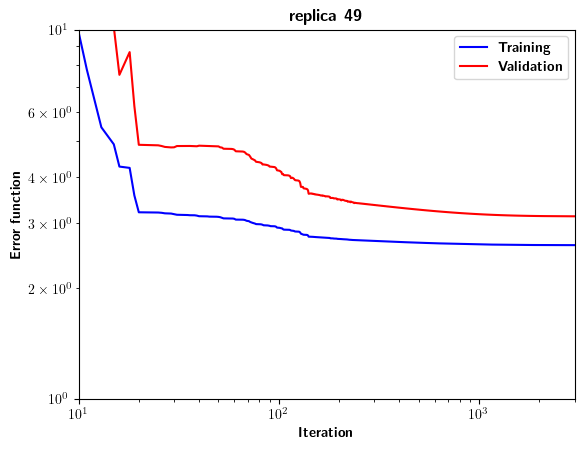

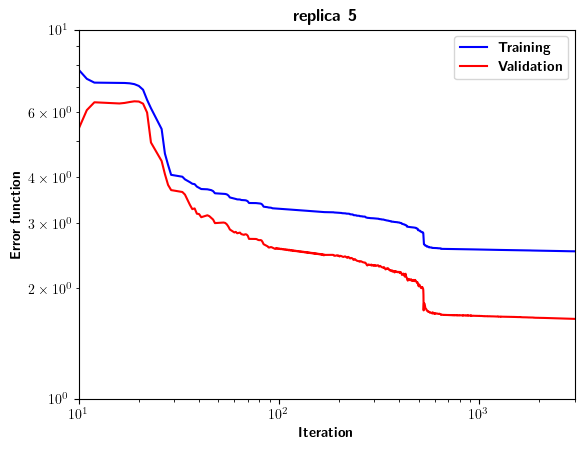

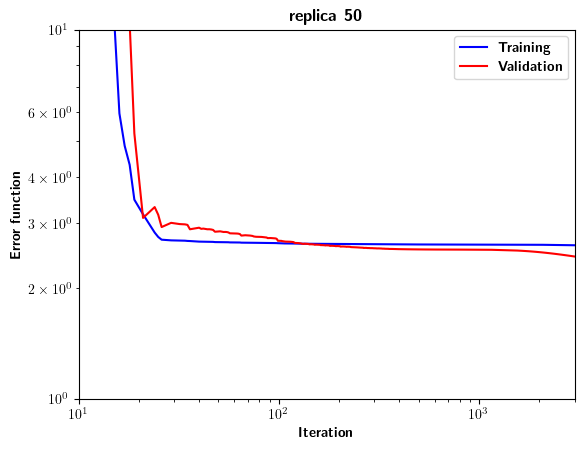

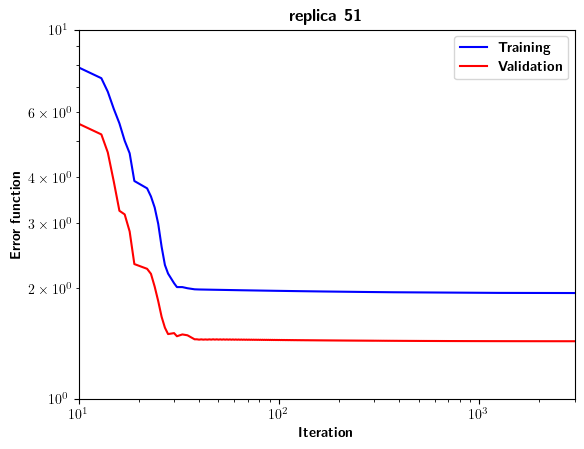

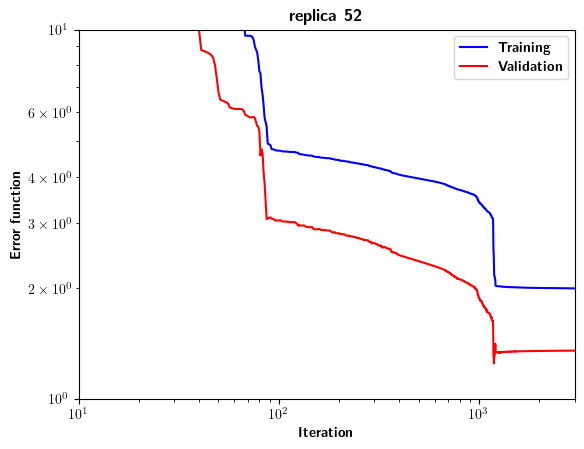

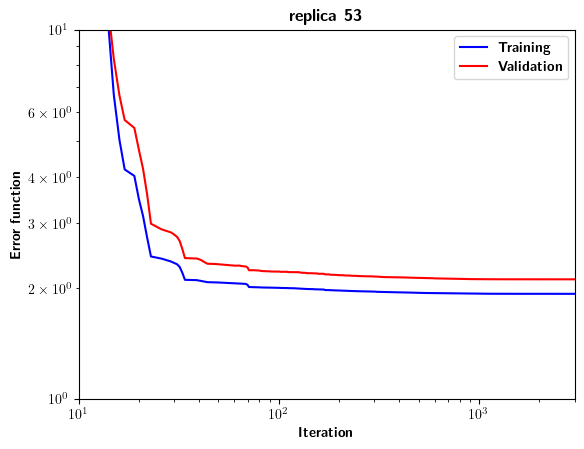

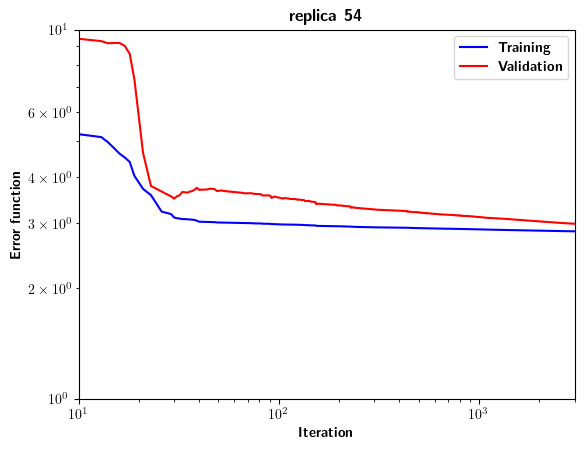

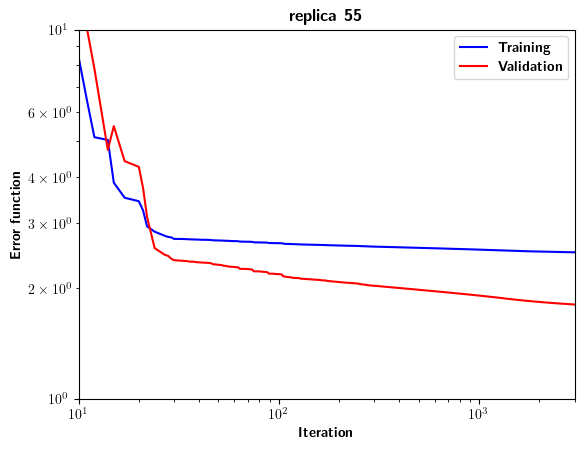

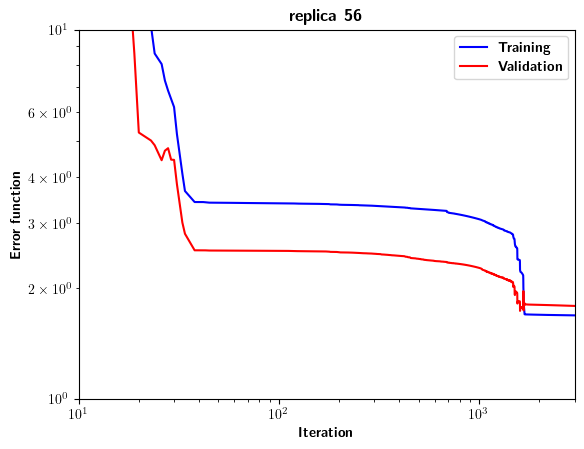

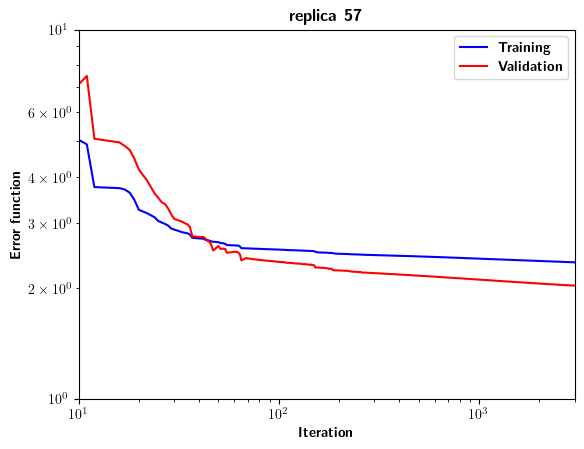

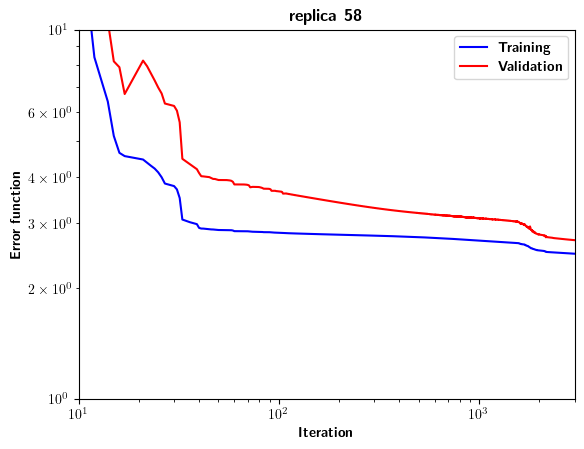

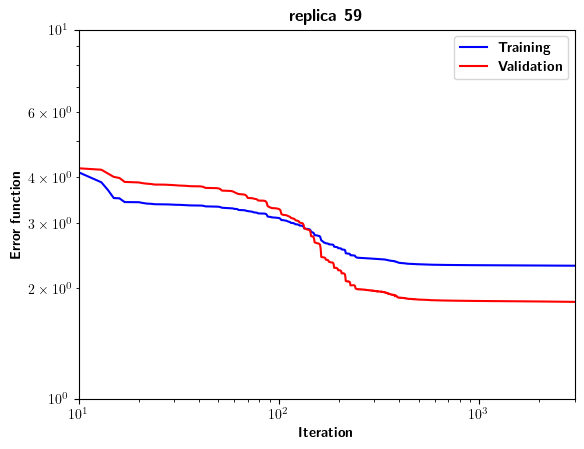

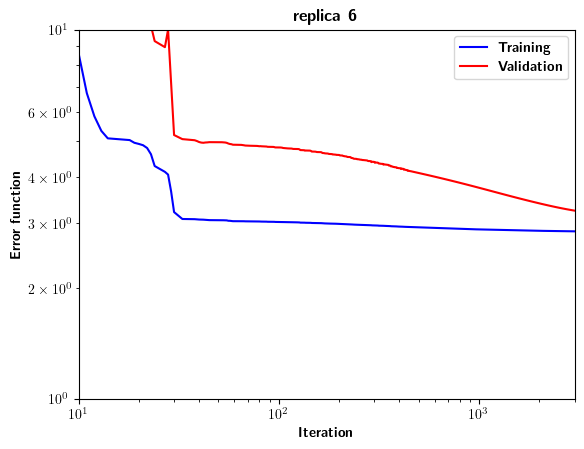

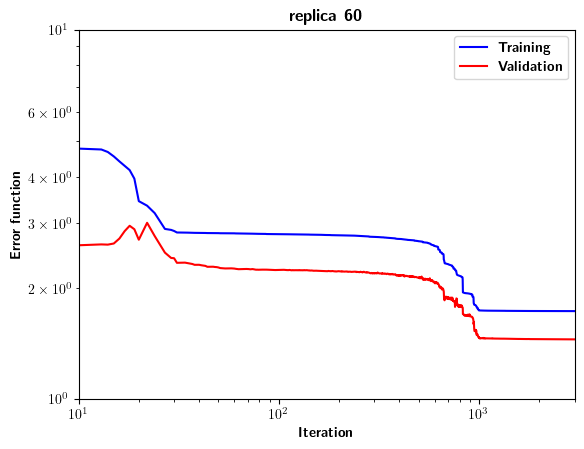

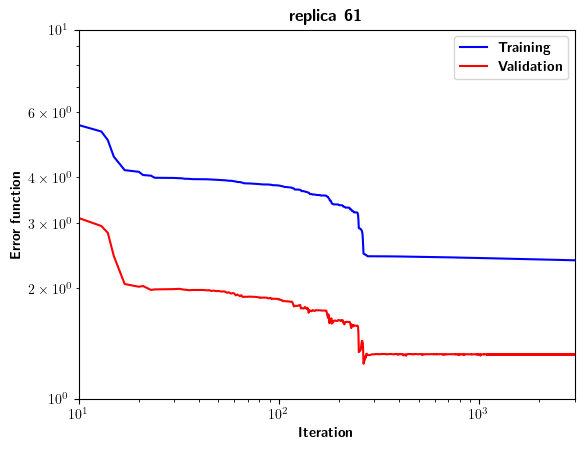

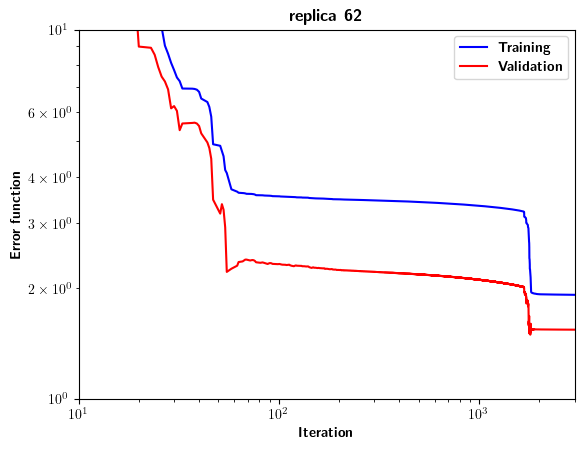

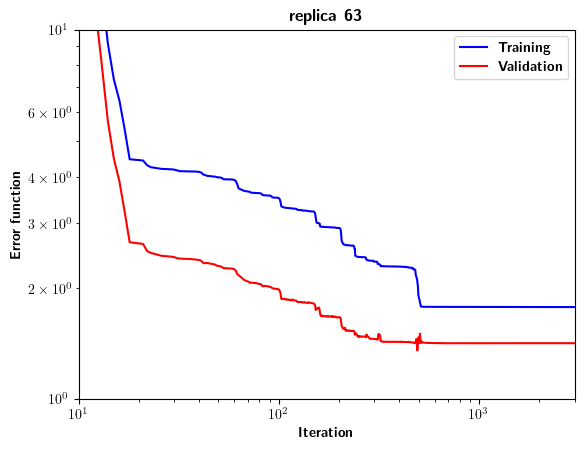

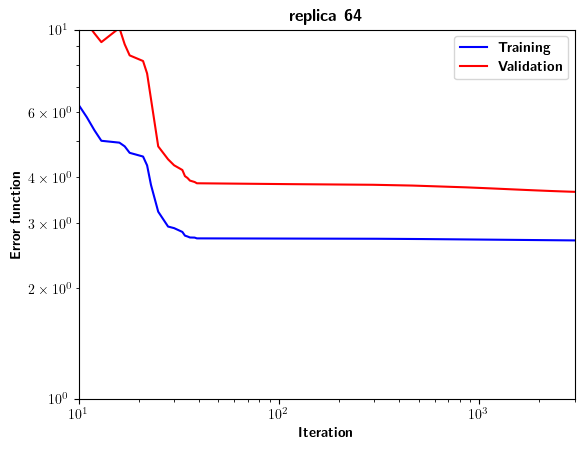

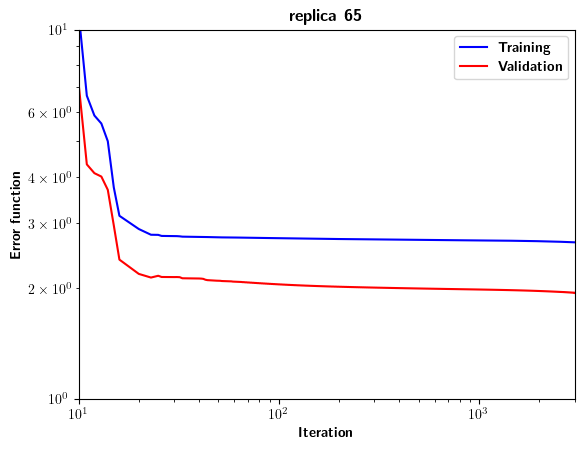

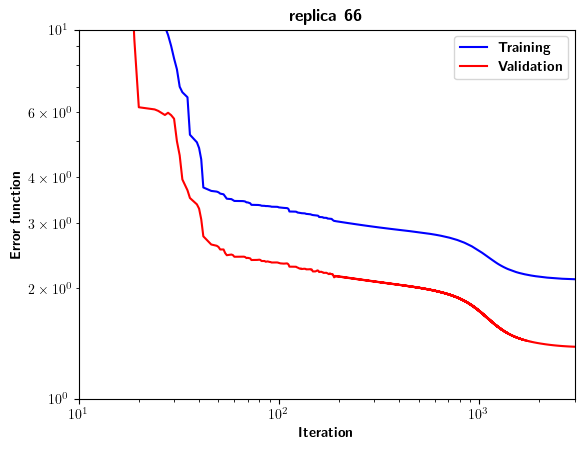

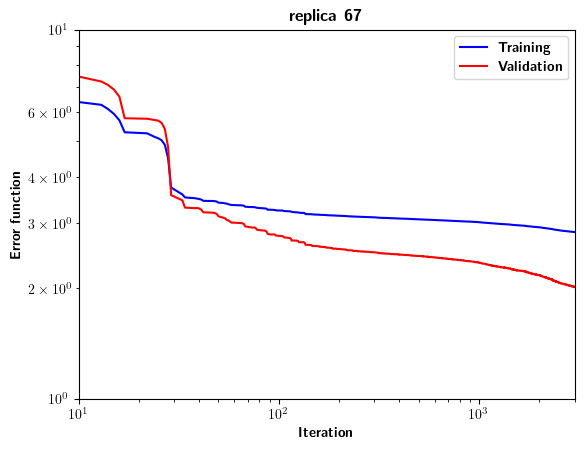

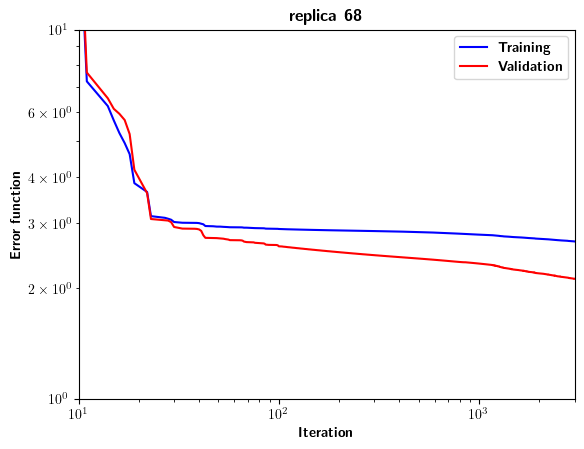

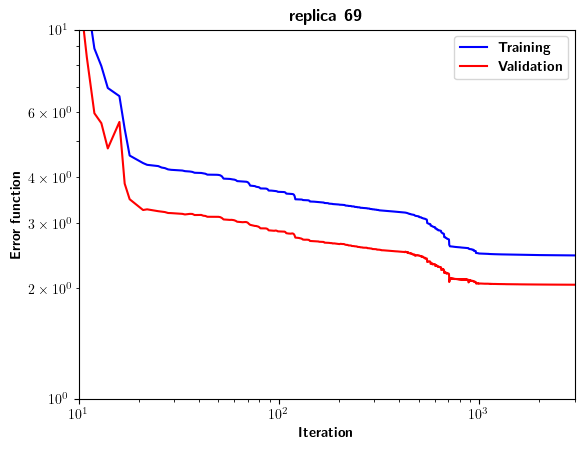

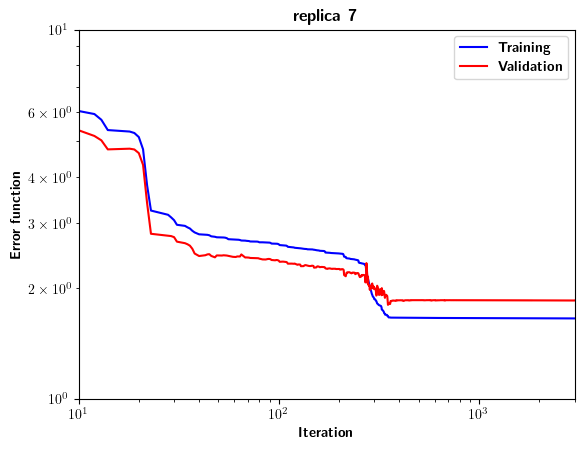

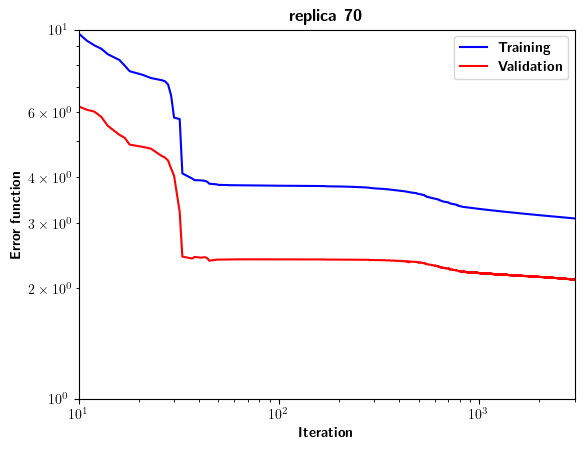

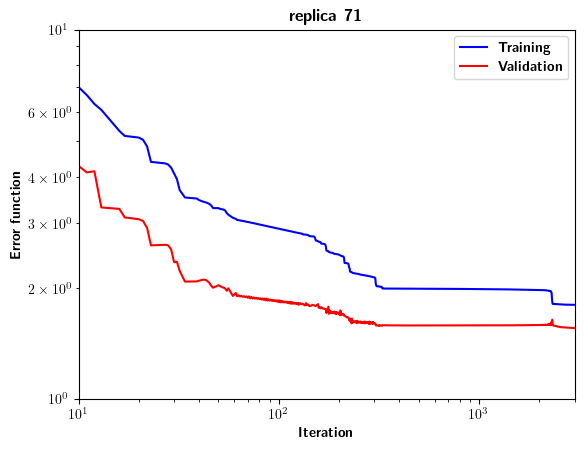

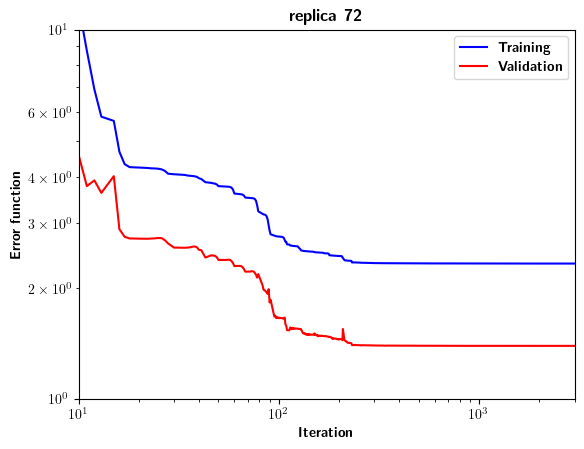

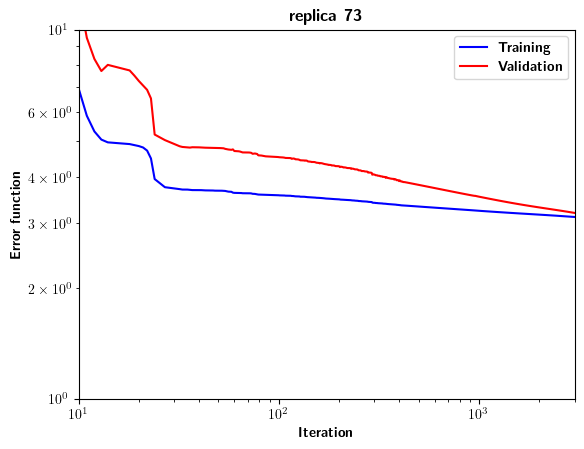

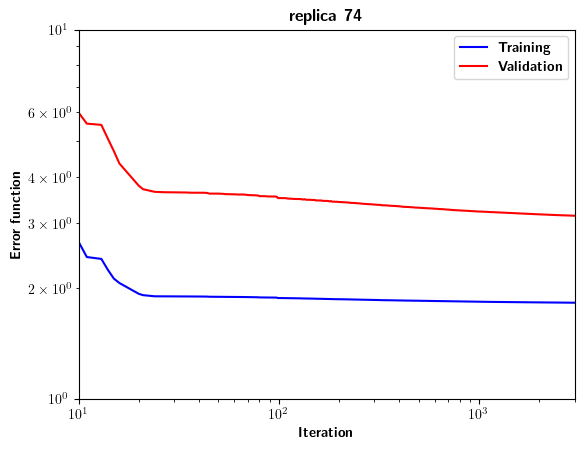

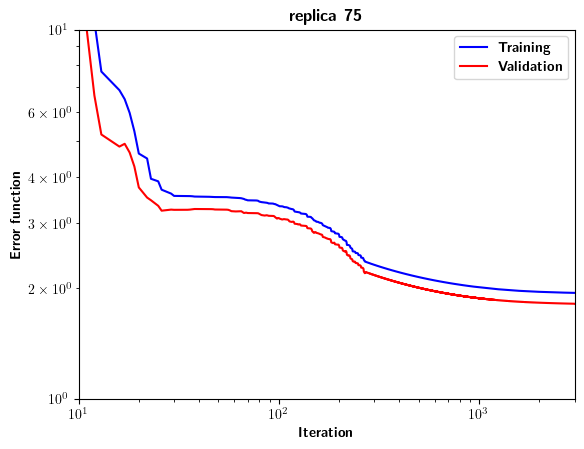

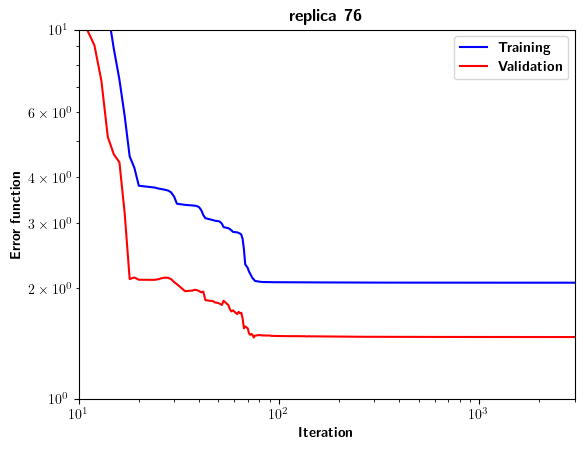

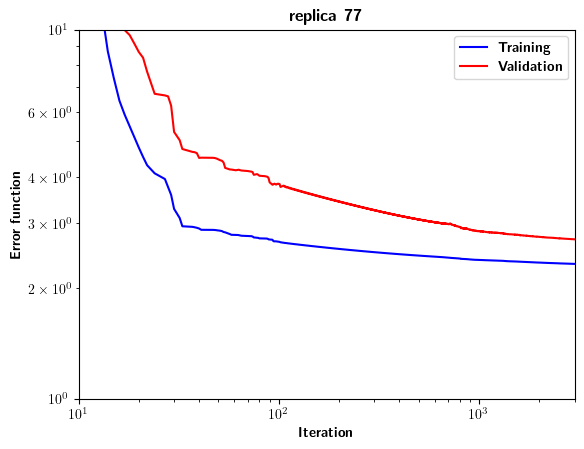

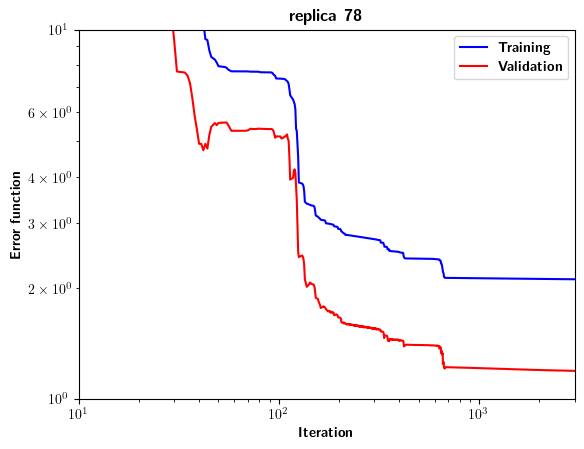

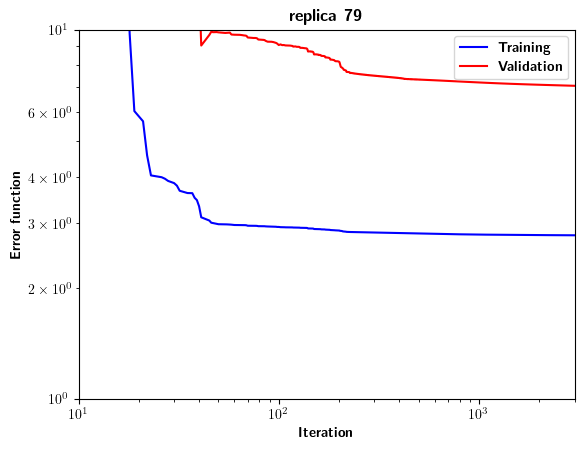

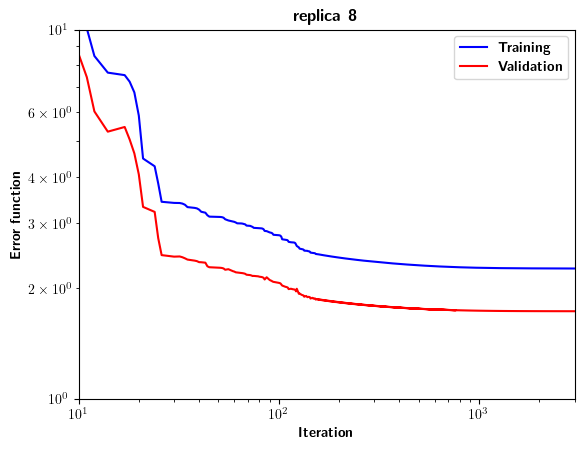

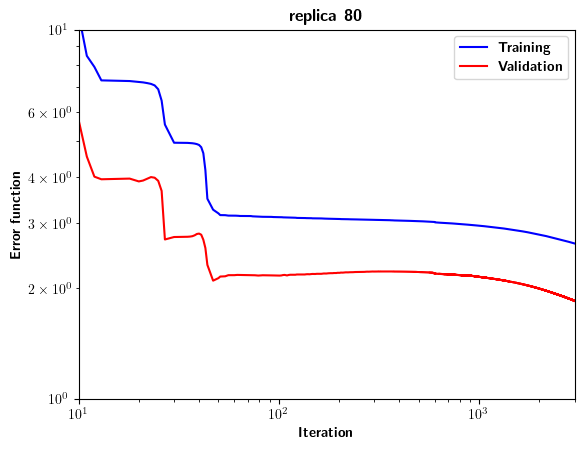

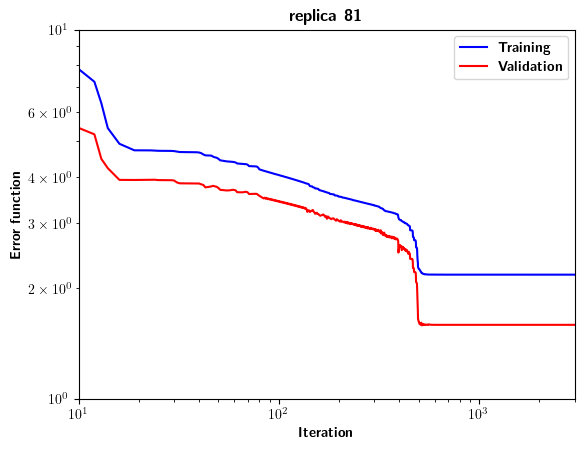

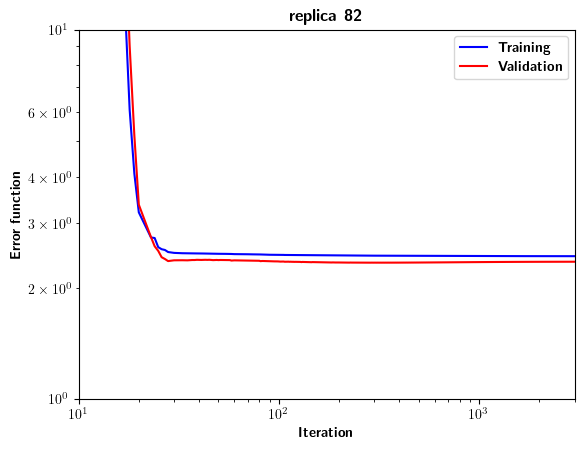

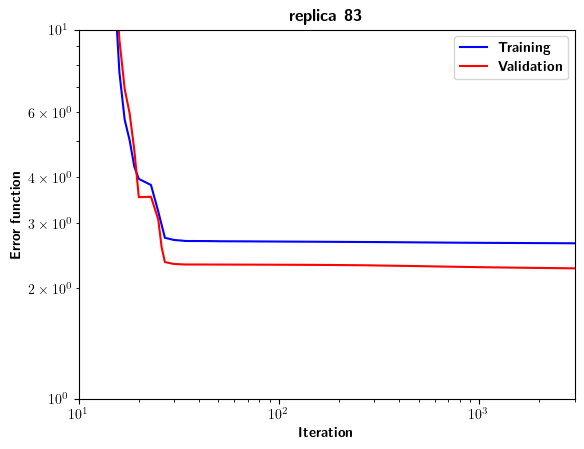

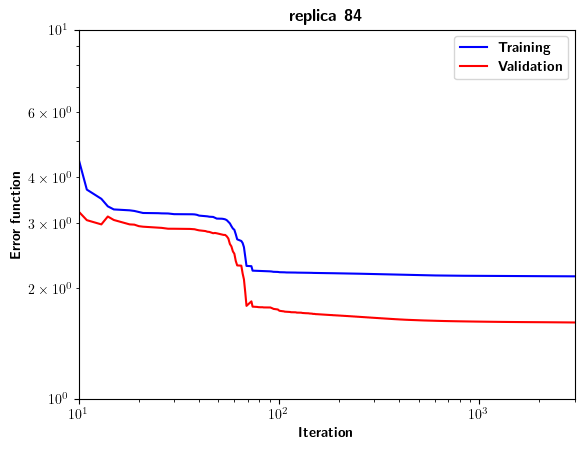

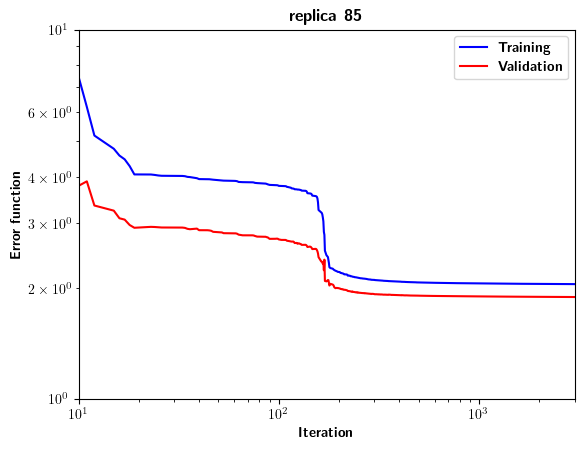

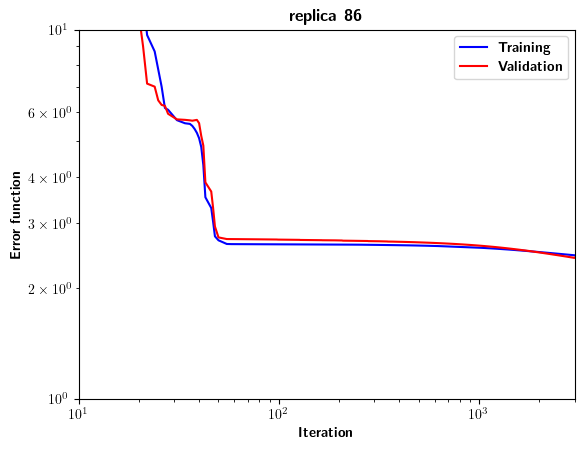

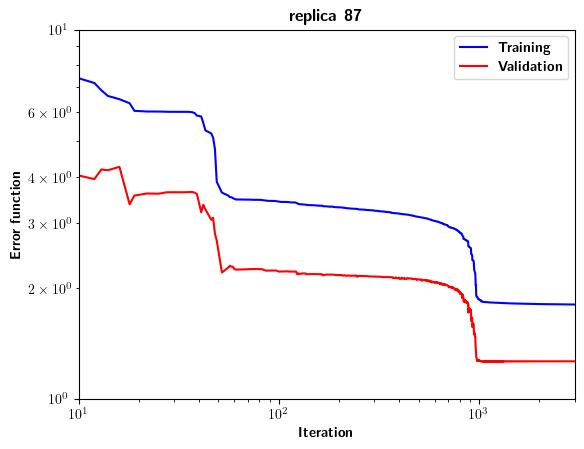

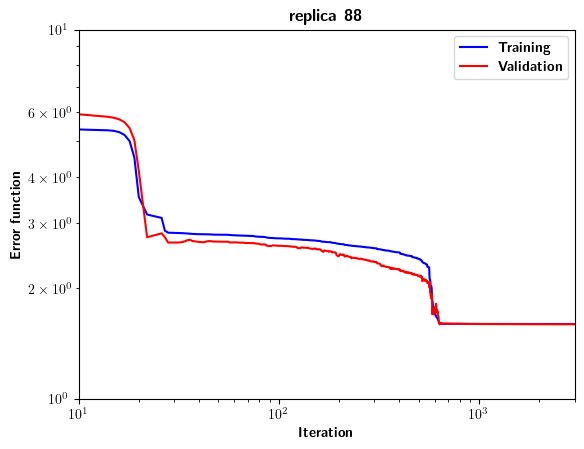

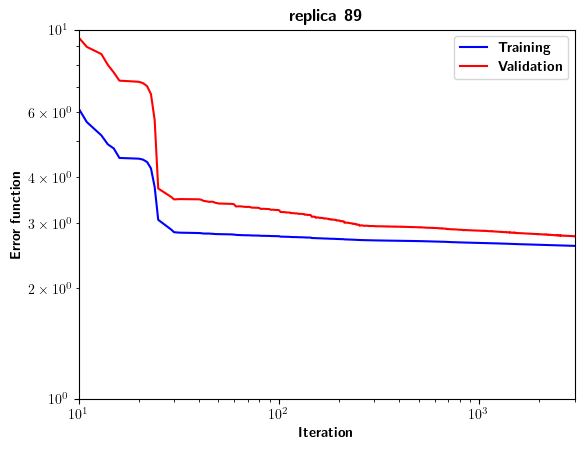

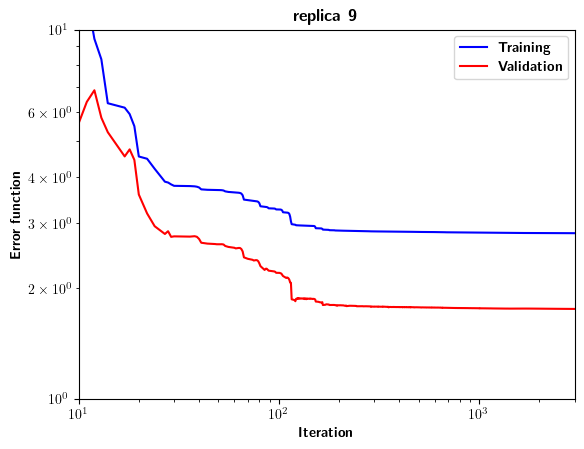

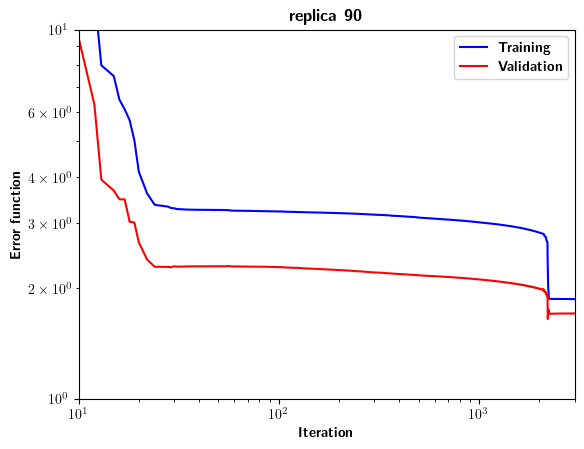

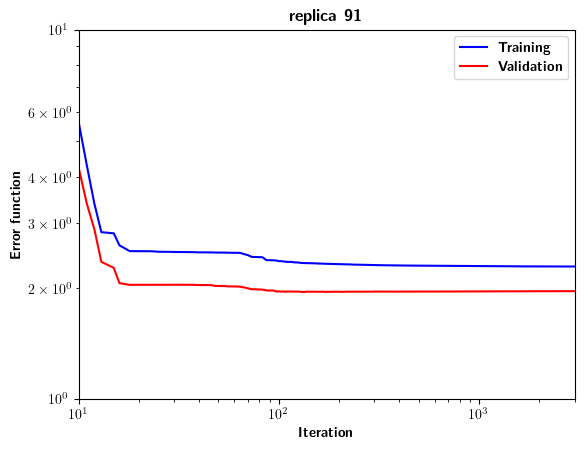

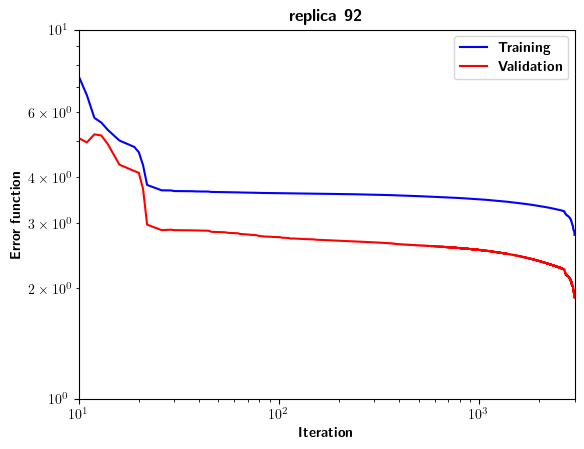

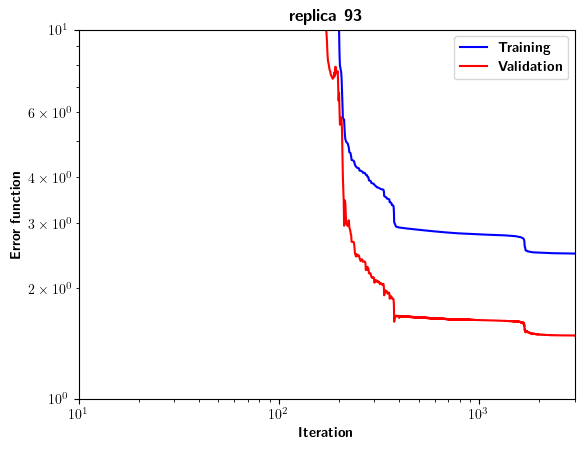

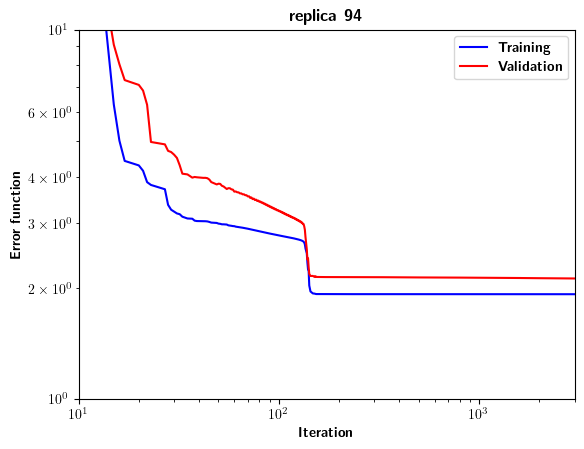

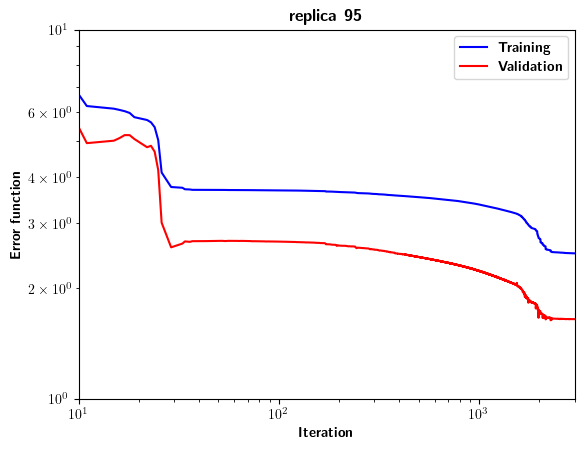

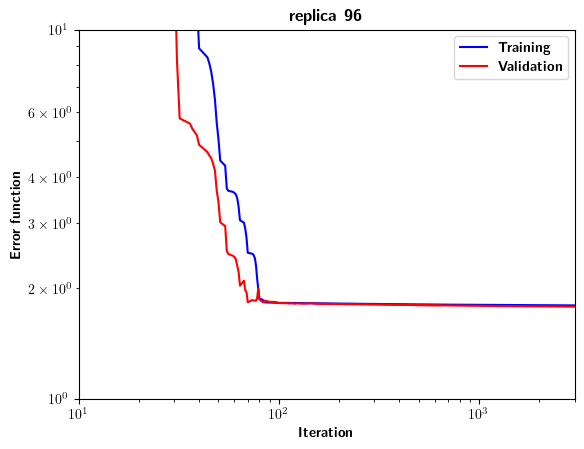

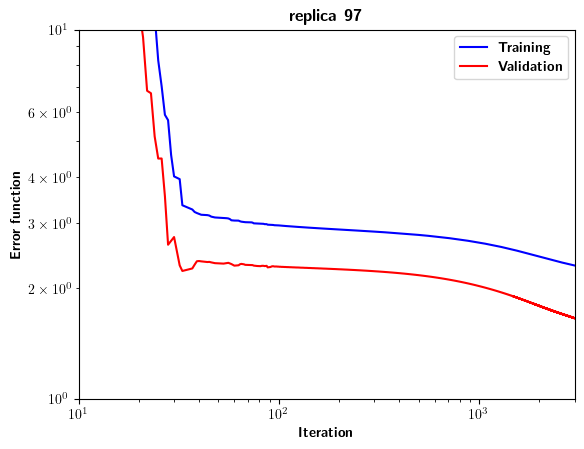

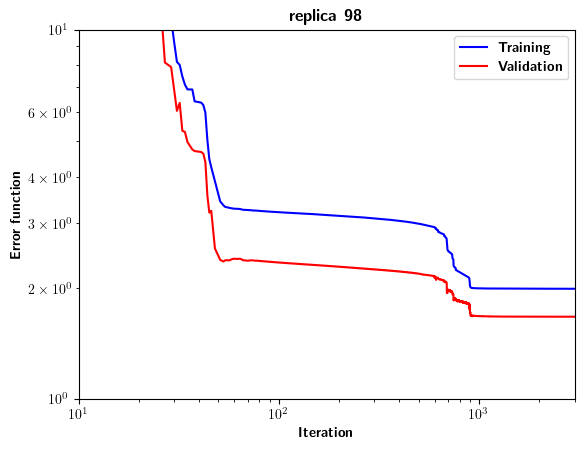

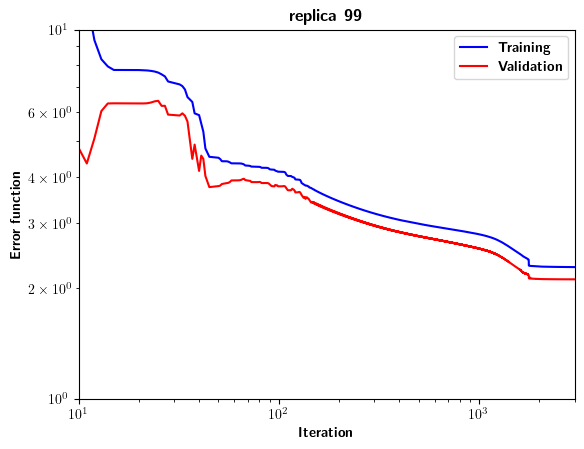

In [9]:
# Chi2 profiles
for frep in [f.replace(".yaml", "") for f in sorted(listdir(FIT_FOLDER + "/log/"))]:
    with open(FIT_FOLDER + "/log/" + frep + ".yaml", "r") as rep:
        replica = yaml.load(rep, Loader = yaml.CLoader)
        ite   = [r["iteration"]       for r in replica]
        chi2t = [r["training chi2"]   for r in replica]
        chi2v = [r["validation chi2"] for r in replica]
        
        plt.title(r"\textbf{" + frep.replace("_", " ") + "}")
        plt.ylabel(r"\textbf{Error function}")
        plt.xlabel(r"\textbf{Iteration}")
        plt.xscale("log")
        plt.yscale("log")
        plt.ylim(1, 10)
        plt.xlim(10, 3000)
        plt.plot(ite, chi2t, color = "blue", label = r"\textbf{Training}")
        plt.plot(ite, chi2v, color = "red",  label = r"\textbf{Validation}")
        plt.legend()
        #plt.savefig(FIT_FOLDER + "/" + frep + ".pdf")
        plt.show()
        plt.close()

ALEPH $\Lambda \bar{\Lambda}$


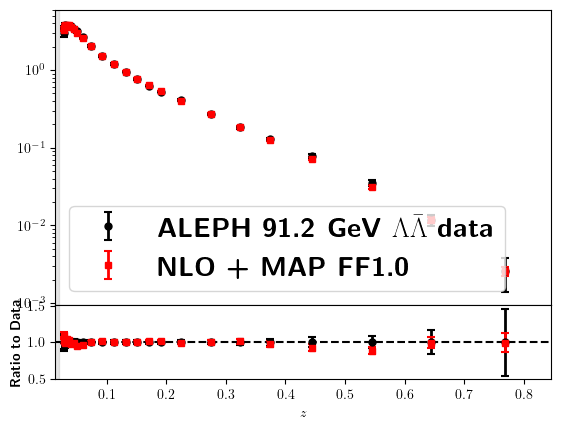

ARGUS $\Lambda \bar{\Lambda}$


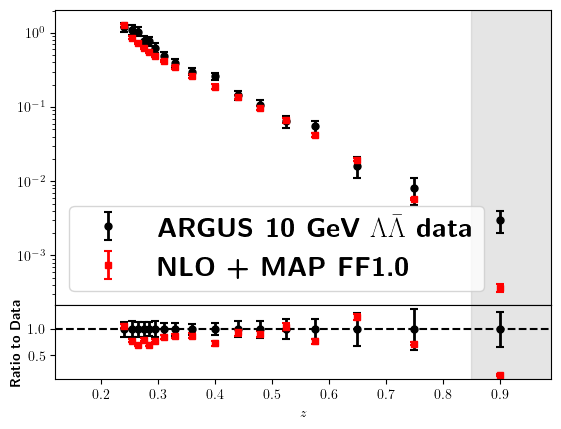

BELLE $\Lambda \bar{\Lambda}$


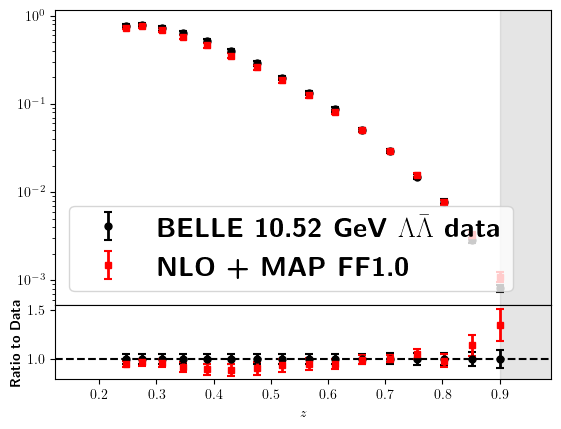

CELLO $\Lambda \bar{\Lambda}$


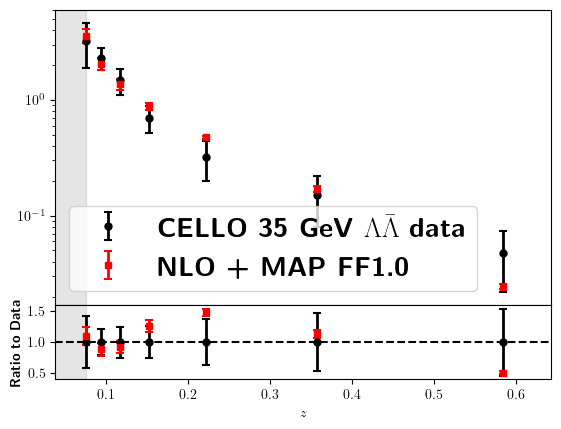

Delphi 91.2 GeV $\Lambda \bar{\Lambda}$


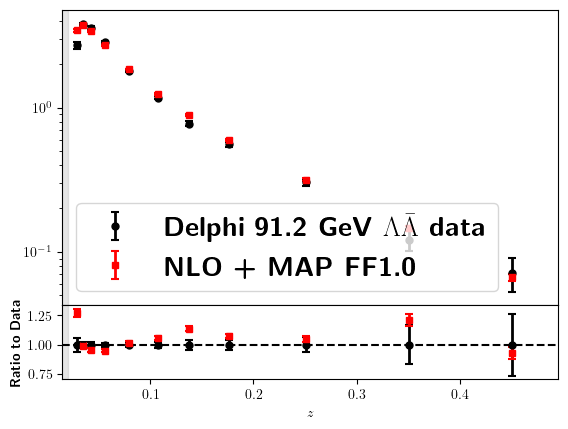

Delphi 183 GeV $\Lambda \bar{\Lambda}$


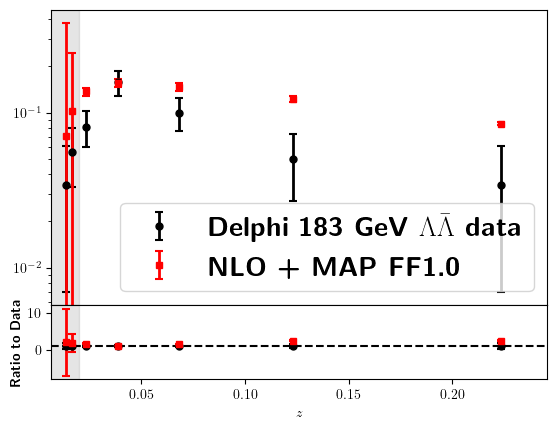

Delphi 189 GeV $\Lambda \bar{\Lambda}$


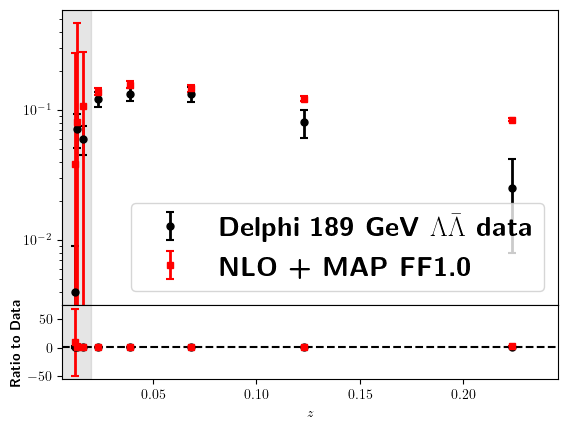

HRS $\Lambda \bar{\Lambda}$


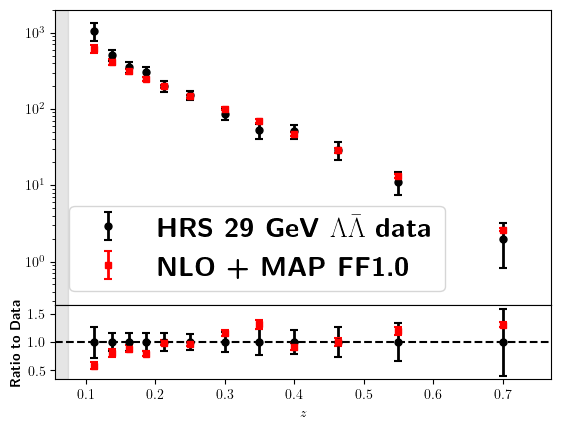

MARK II $\Lambda \bar{\Lambda}$


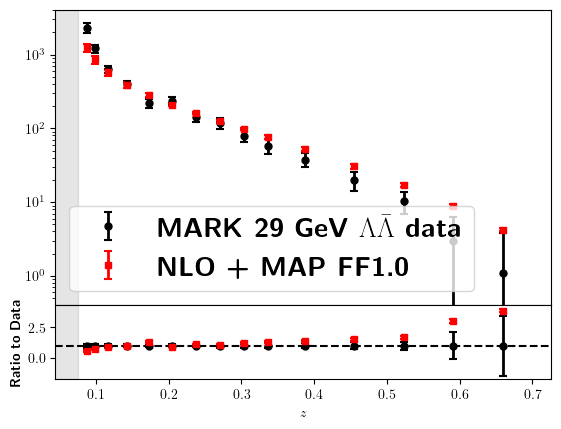

OPAL $\Lambda \bar{\Lambda}$


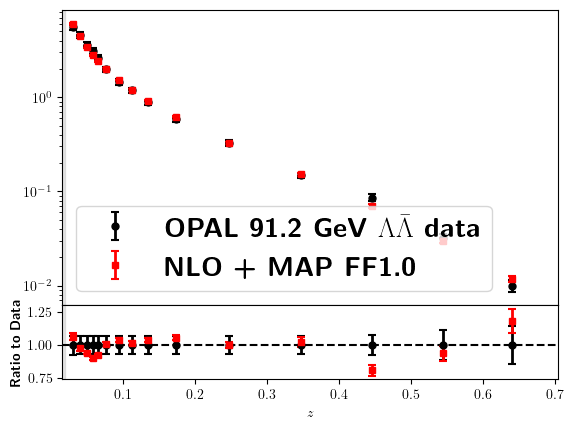

SLD B $\Lambda \bar{\Lambda}$


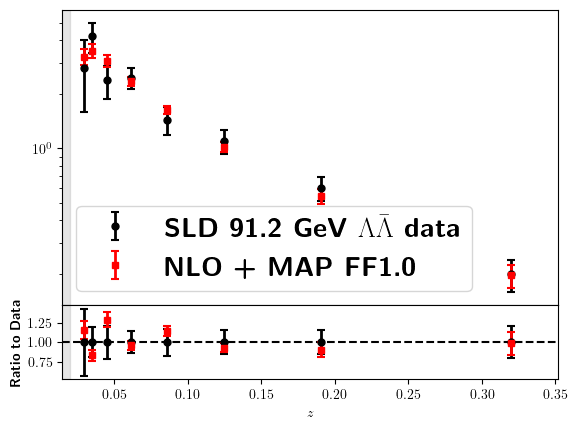

SLD C $\Lambda \bar{\Lambda}$


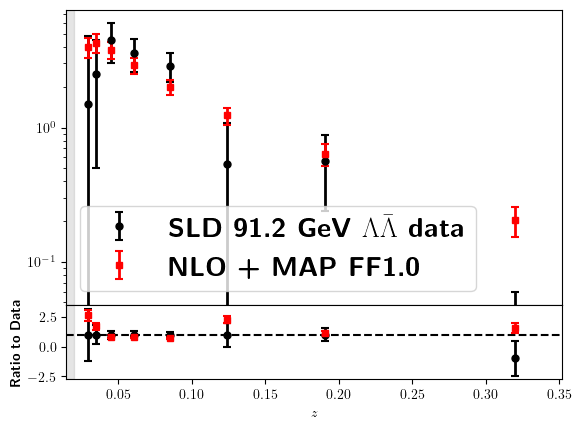

SLD UDS $\Lambda \bar{\Lambda}$


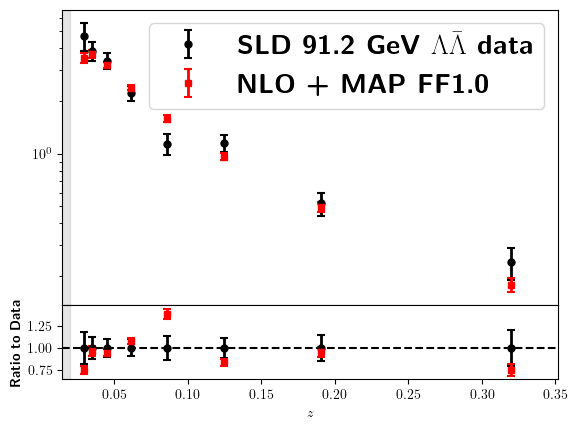

SLD $\Lambda \bar{\Lambda}$


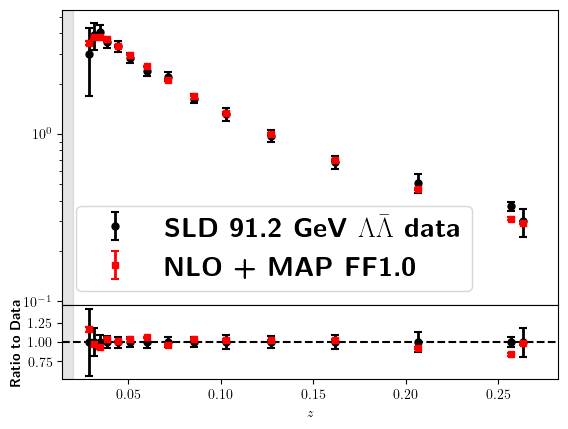

TASSO 14 GeV $\Lambda \bar{\Lambda}$


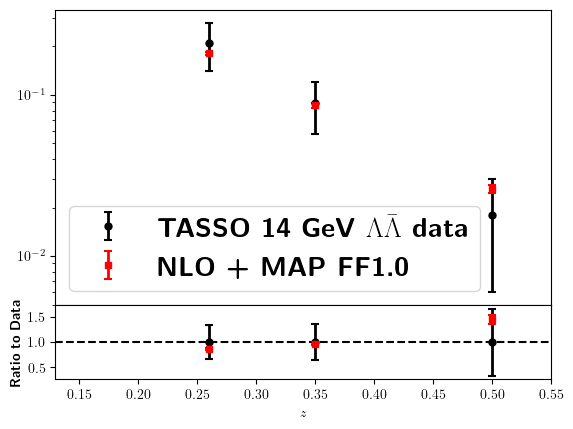

TASSO 22 GeV $\Lambda \bar{\Lambda}$


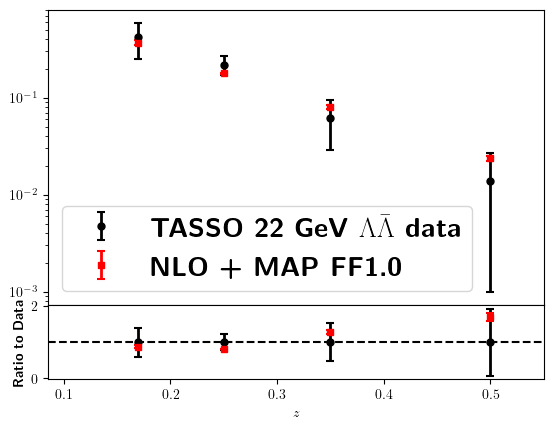

TASSO 33 GeV $\Lambda \bar{\Lambda}$


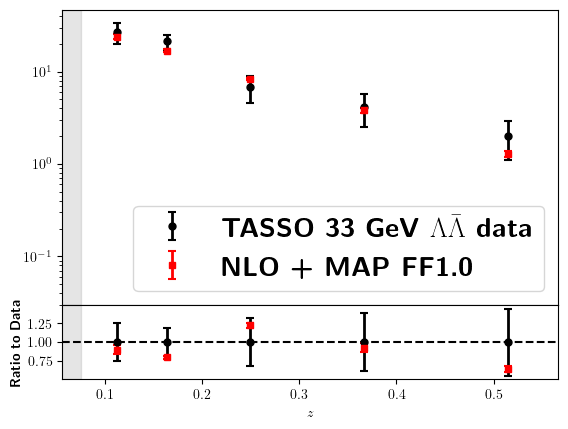

TASSO 34.8 GeV $\Lambda \bar{\Lambda}$


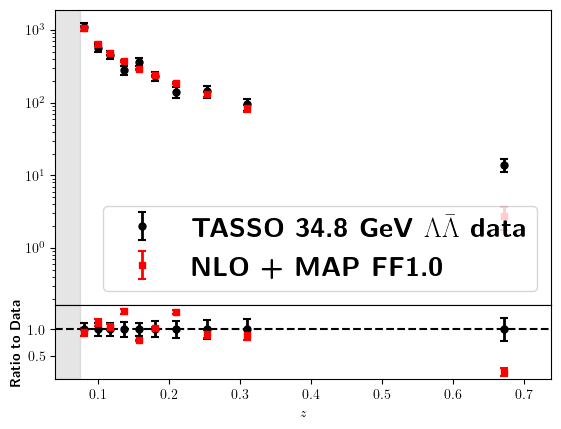

TASSO 42.1 GeV $\Lambda \bar{\Lambda}$


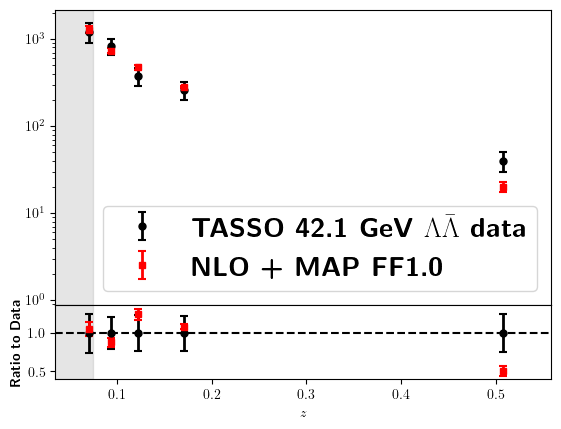

In [51]:
# SIA experiments
with open(FIT_FOLDER + "/Predictions.yaml", "r") as p:
    preds = yaml.load(p, Loader = yaml.CLoader)
    for e in preds:
        for exp, points in e.items():
            if ("COMPASS" in exp) or ("HERMES" in exp):
                continue
            print(exp)
            zav  = np.array([pt["zav"] for pt in points])
            zmin = np.array([pt["zmin"] for pt in points])
            zmax = np.array([pt["zmax"] for pt in points])
            excv = np.array([pt["exp. central value"] for pt in points])
            exun = np.array([pt["exp. unc."] for pt in points])
            thcv = np.array([pt["prediction"] for pt in points])
            thun = np.array([pt["pred. unc."] for pt in points])

            # Reverse the z values (and associated data) if needed (see DELPHI 183-189 cases)
            if zav[0] > zav[-1]:
                zav = np.flip(zav)
                zmax = np.flip(zmax)
                zmin = np.flip(zmin)
                excv = np.flip(excv)
                exun = np.flip(exun)
                thcv = np.flip(thcv)
                thun = np.flip(thun)
                       
            # Get zcutmin and zcutmax for the current dataset
            if exp in zcuts:
                zcutmin, zcutmax = zcuts[exp]
            else:
                print(f"No zcut values found for experiment {exp}")
                continue    
                        
            f, (ax1, ax2) = plt.subplots(2, 1, sharex = "all", gridspec_kw = dict(width_ratios = [1], height_ratios = [4, 1]))
            plt.subplots_adjust(wspace = 0, hspace = 0)

            ax1.set_xlim(xlims[exp])
            #ax1.set_ylim(ylims1[exp])
            #ax1.set_ylabel(ylabels[exp])
            ax1.set_yscale("log")
            if xlog[exp]:
                ax1.set_xscale("log")
            if "GeV" in exp:
                ax1.errorbar(zav, excv, exun, elinewidth = 2, capsize = 3, capthick = 1.5, label = r"\textbf{" + exp + " data}", markersize = 5, fmt = "ko")
            else:
                ax1.errorbar(zav, excv, exun, elinewidth = 2, capsize = 3, capthick = 1.5, label = r"\textbf{" + exp.split()[0] + " " + str(vs[exp]) + " GeV " + r"$\Lambda \bar{\Lambda}$" + " data}", markersize = 5, fmt = "ko")
            if binints[exp]:
                ax1.bar(zmin, 2 * thun, bottom = thcv - thun, width = zmax - zmin, align = "edge", color = "red", label = r"\textbf{NLO + MAP FF1.0}", alpha = 0.5)
            else:
                ax1.errorbar(zav, thcv, thun, elinewidth = 2, capsize = 3, capthick = 1.5, label = r"\textbf{NLO + MAP FF1.0}", markersize = 4, fmt = "rs")
            ax1.legend(fontsize = 20)
            ax1.axvspan(0, zcutmin, color='grey', alpha=0.2) 
            ax1.axvspan(zcutmax, 1, color='grey', alpha=0.2)

            # Lower panel
            ax2.set_xlim(xlims[exp])
            #ax2.set_ylim(ylims2[exp])
            ax2.set_xlabel(r"$z$")
            ax2.set_ylabel(r"\textbf{Ratio to Data}", fontsize = 10)
            if xlog[exp]:
                ax2.set_xscale("log")
            ax2.axhline(y = 1, c = "k", ls = "--", lw = 1.5)
            ax2.errorbar(zav, excv/abs(excv), exun/abs(excv), elinewidth = 2, capsize = 3, capthick = 1.5, markersize = 5, fmt = "ko")
            if binints[exp]:
                ax2.bar(zmin, 2 * thun/abs(excv), bottom = (thcv - thun)/abs(excv), width = zmax - zmin, align = "edge", color = "red", alpha = 0.5)
            else:
                ax2.errorbar(zav, thcv/abs(excv), thun/abs(excv), elinewidth = 2, capsize = 3, capthick = 1.5, markersize = 5, fmt = "rs")

            ax2.axvspan(0, zcutmin, color='grey', alpha=0.2) 
            ax2.axvspan(zcutmax, 1, color='grey', alpha=0.2) 

            plt.savefig(FIT_FOLDER + "/plots/predictions/" + plotfiles[exp] + ".pdf")
            plt.show()
            plt.close()

In [11]:
# Upload sets and declare uncertainty type
lh.pathsAppend(str(FIT_FOLDER))
ffs = [lh.mkPDFs("LHAPDFSet")]
unc = ["montecarlo"]
colff = ["orange"]
nameff = [r"\textbf{MAP Lambda FF}"]

# Function that returns the central values
def ComputeCentralValueAndUncertainty(x, Q, comb):
    centralvalue = []
    uncertainty  = []
    for s in zip(ffs, unc):
        if s[1] == "hessian":
            # In the case of a hessian set, use replica 0 as central value
            cv = 0
            f = s[0][0].xfxQ(x, Q)
            for k, v in comb.items():
                cv += v * f[k]
            err = 0
            for im in range(int((len(s[0]) - 1)/2)):
                fp = s[0][2*im+1].xfxQ(x, Q)
                fm = s[0][2*im+2].xfxQ(x, Q)
                t = 0
                for k, v in comb.items():
                    t += v * fp[k]
                    t -= v * fm[k]
                err += t**2
            centralvalue.append(cv)
            uncertainty.append(np.sqrt(err)/2)            
        elif s[1] == "montecarlo":
            # In case of a MC set, compute the average and standard deviation (do not include replica 0)
            cv  = 0
            cv2 = 0
            for irep in range(1, len(s[0])):
                f = s[0][irep].xfxQ(x, Q)
                t = 0
                for k, v in comb.items():
                    t += v * f[k]
                cv  += t / ( len(s[0]) - 1 )
                cv2 += t**2 / ( len(s[0]) - 1 )
            centralvalue.append(cv)
            uncertainty.append(np.sqrt(cv2 - cv**2))
        else:
            sys.exit("Unknown error: ", s[1])
    return centralvalue, uncertainty

LHAPDF 6.5.4 loading all 101 PDFs in set LHAPDFSet
LHAPDFSet, version 1; 101 PDF members


In [12]:
# FF plot settings

# Scale
Q = 5

# Grid in x
xv = np.logspace(-2, -0.0001, 1000)

# Combinations to be plotted
combs = [{21: 1},         # g
         {1: 1, -1: 1},   # d+
         {2: 1, -2: 1},   # u+
         {3: 1, -3: 1},   # s+
         {4: 1, -4: 1},   # c+
         {5: 1, -5: 1},   # b+

         ]
labels = [r"$zD_g^{\Lambda}(z,Q)$", 
          r"$zD_{d^+}^{\Lambda}(z,Q)$",
          r"$zD_{u^+}^{\Lambda}(z,Q)$", 
          r"$zD_{s^+}^{\Lambda}(z,Q)$", 
          r"$zD_{c^+}^{\Lambda}(z,Q)$", 
          r"$zD_{b^+}^{\Lambda}(z,Q)$", 
          ]
ylim1 = [[-0.006, 0.015],   
         [-0.01, 0.20],    
         [-0.01, 0.10],    
         [-0.01, 0.125],    
         [-0.01, 0.125],    
         [-0.01, 0.1],      
         ]         
pdfname = ["Dg", 
           "Ddp",
           "Dup",
           "Dsp",
           "Dcp",
           "Dbp",
           ]

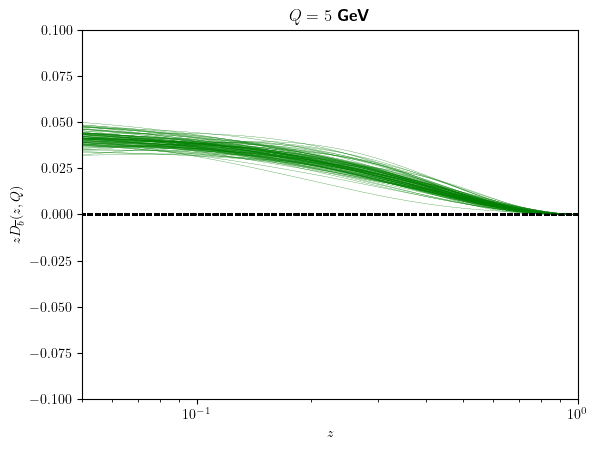

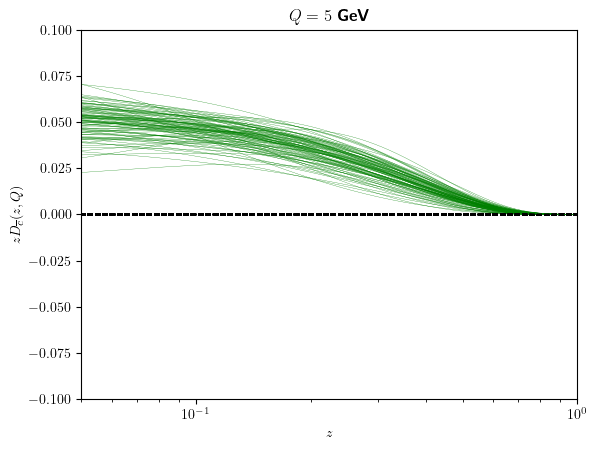

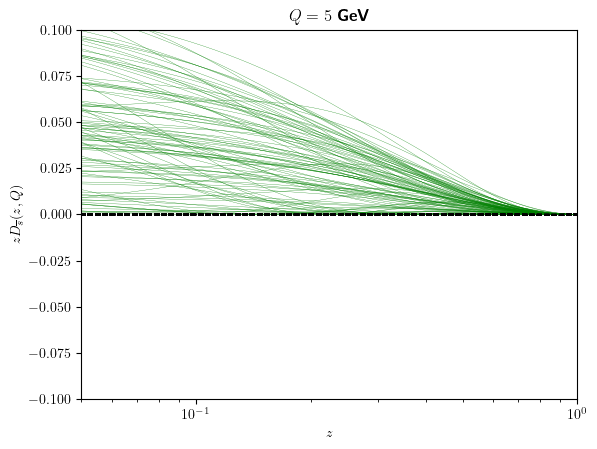

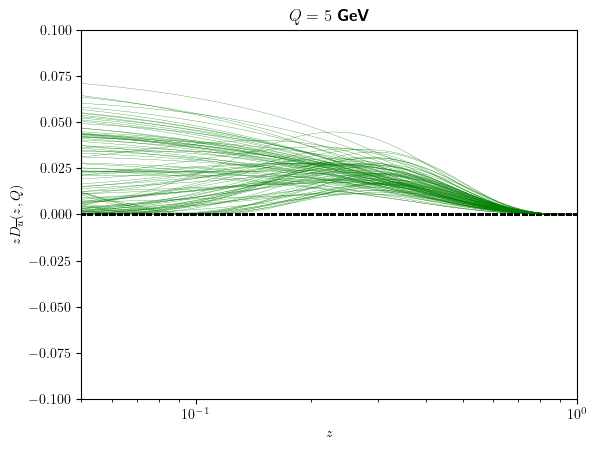

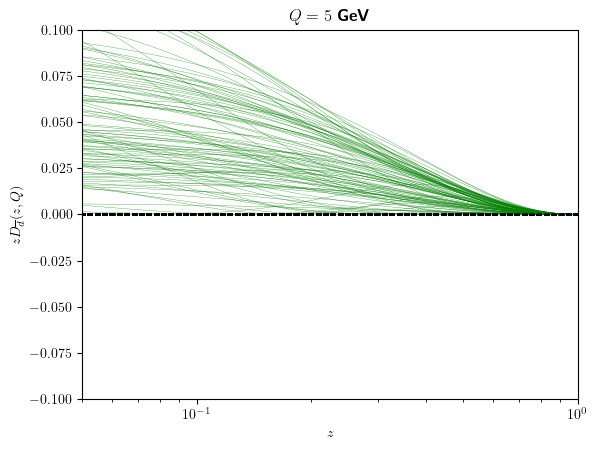

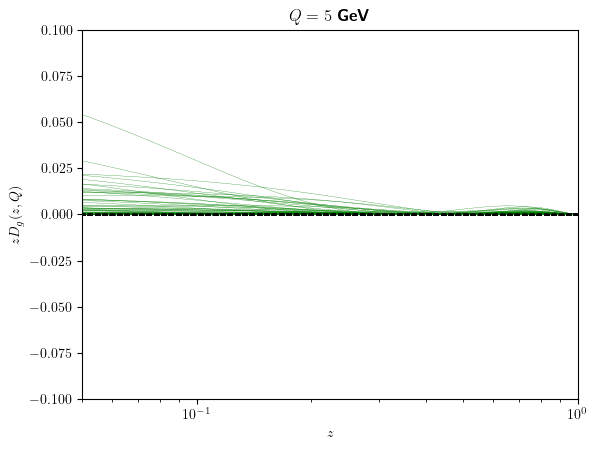

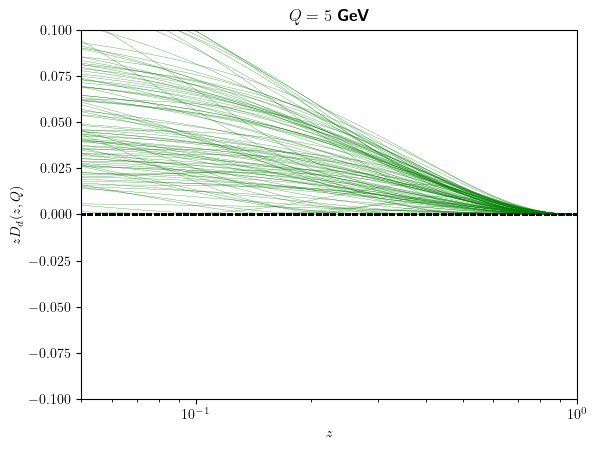

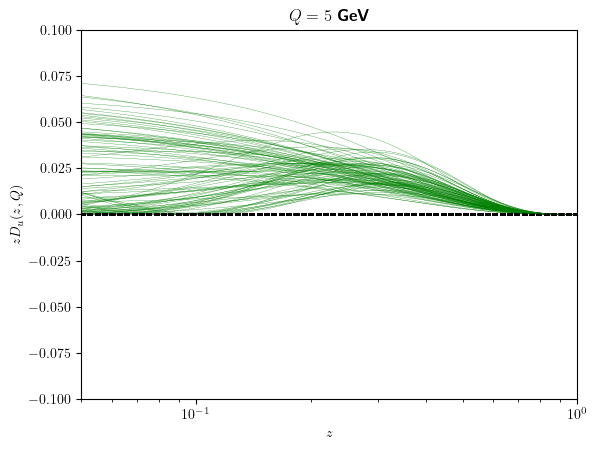

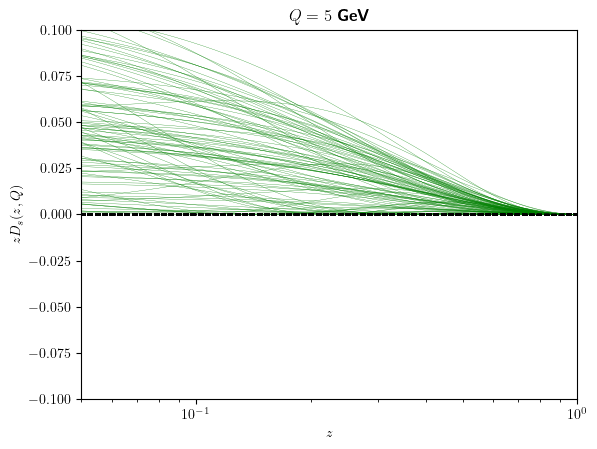

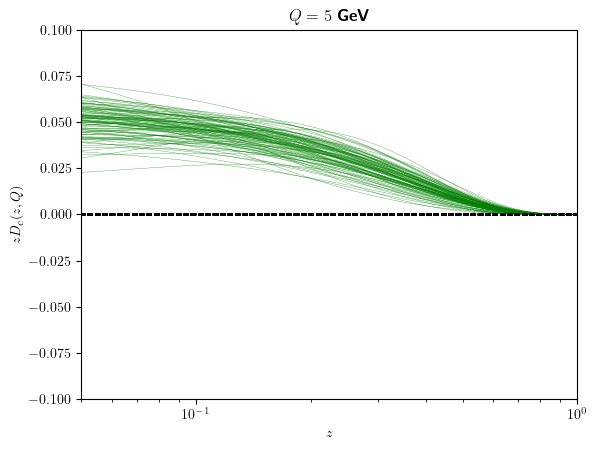

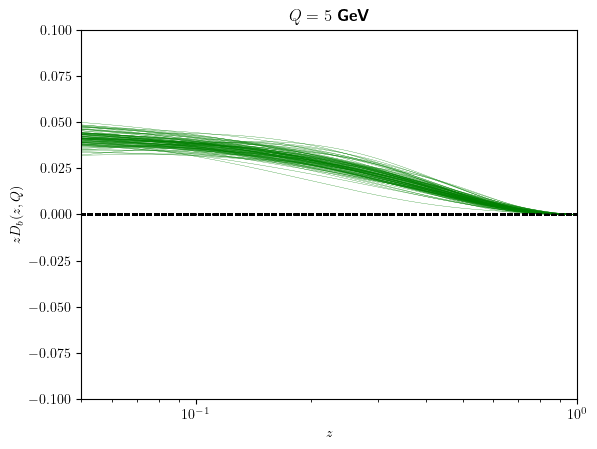

In [13]:
# Plot single replicas of the current fit for all flavours
labelmap = {-5: r"\overline{b}", -4: r"\overline{c}", -3: r"\overline{s}", -2: r"\overline{u}", -1: r"\overline{d}", 0: "g", 1: "d", 2: "u", 3: "s", 4: "c", 5: "b"}
for ifl in range(-5,6):
    xf = [ffs[0][0].xfxQ(ifl, 0.1, Q) for x in xv]
    
    plt.title(r"$Q = " + str(Q) + r"$ \textbf{GeV}")
    plt.ylabel(r"$zD_{" + labelmap[ifl] + r"}(z, Q)$")
    plt.xlabel(r"$z$")
    plt.xlim(0.05, 1)
    plt.xscale("log")
    plt.ylim(-0.1, 0.1)
    for ff in ffs[0]:
        plt.plot(xv, [ff.xfxQ(ifl, x, Q) for x in xv], color = "green", ls = "-", lw = 0.2)
        plt.plot(xv, xv - xv, color = "black", ls = "--", lw = 1)
    plt.show()
    plt.close()



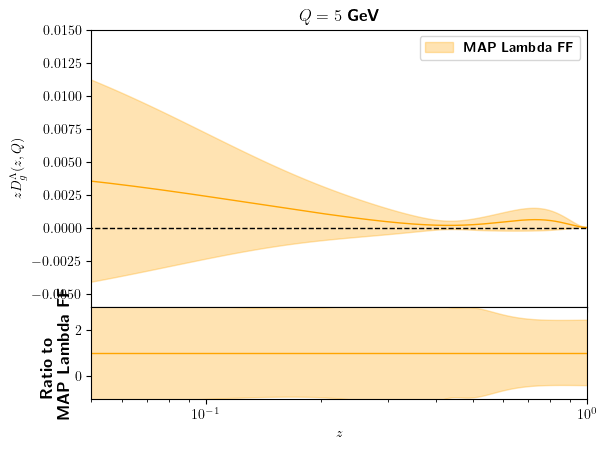

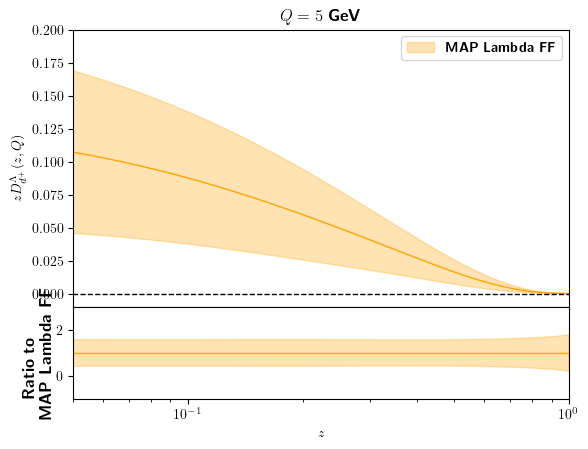

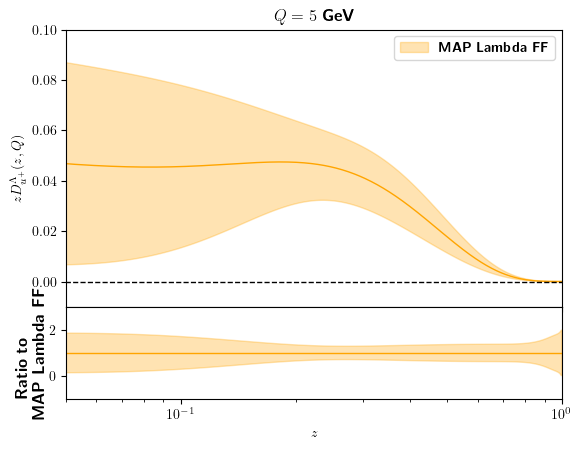

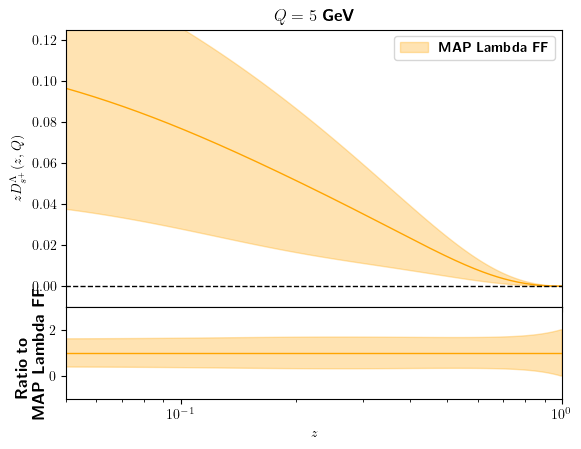

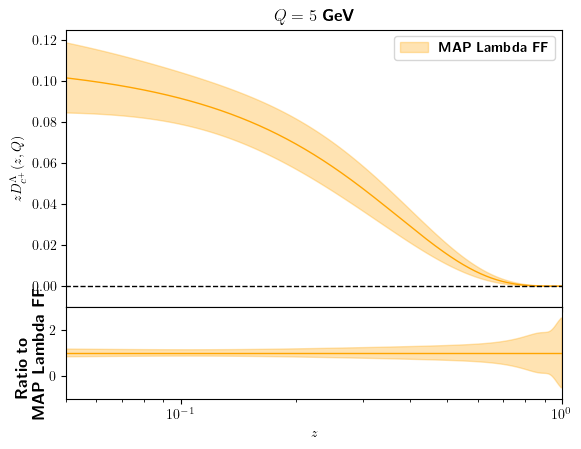

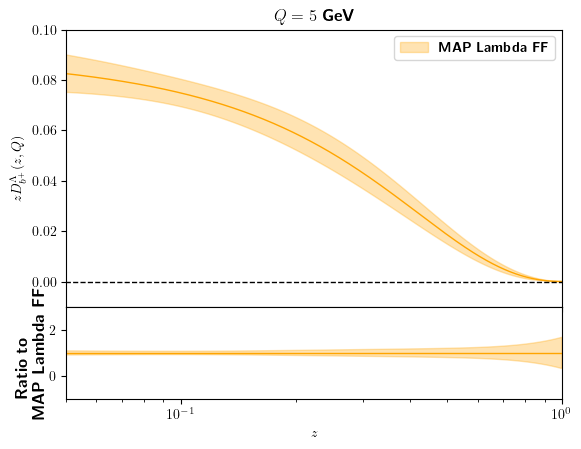

In [14]:
# Plot FFs
axes = {}
for cm in zip(combs, labels, ylim1, pdfname):
    fv  = []
    dfv = []
    for x in xv:
        cv, err = ComputeCentralValueAndUncertainty(x, Q, cm[0])
        fv.append(cv)
        dfv.append(err)
    # Transpose results
    fv  = list(map(list, zip(*fv)))
    dfv = list(map(list, zip(*dfv)))

    # Setup plot
    f, (ax1, ax2) = plt.subplots(2, 1, sharex = "all", gridspec_kw = dict(width_ratios = [1], height_ratios = [3, 1]))
    plt.subplots_adjust(wspace = 0, hspace = 0)
    
    ax1.set_title(r"$Q = " + str(Q) + r"$ \textbf{GeV}")
    ax1.set_ylabel(cm[1])
    ax1.set_xlim([0.05, 1])
    ax1.set_xscale("log")
    ax1.set_ylim(cm[2])
    
    ax2.set_xlabel(r"$z$")
    ax2.set_ylabel(r"\textbf{Ratio to}\\ \textbf{" + nameff[0] + "}", fontsize = 12)
    ax2.set_xlim([0.05, 1])
    ax2.set_xscale("log")
    ax2.set_ylim([-1, 3])

    for iset in range(len(fv)):
        ax1.plot(xv, fv[iset], color = colff[iset], ls = "-", lw = 1)
        fill = ax1.fill_between(xv, np.array(fv[iset]) + np.array(dfv[iset]), np.array(fv[iset]) - np.array(dfv[iset]), color = colff[iset], alpha = 0.3, label = nameff[iset])
        ax1.plot(xv, xv - xv, color = "black", ls = "--", lw = 1)
        ax2.plot(xv, np.array(fv[iset])/np.array(fv[0]), color = colff[iset], ls = "-", lw = 1)
        ax2.fill_between(xv, (np.array(fv[iset])+np.array(dfv[iset]))/np.array(fv[0]), (np.array(fv[iset])-np.array(dfv[iset]))/np.array(fv[0]), color = colff[iset], alpha = 0.3)
    axes[cm[3]] = ((ax1, fill), cm[1], dfv[iset])
    ax1.legend()

    plt.savefig(FIT_FOLDER + "/plots/ffs/" + cm[3] + ".pdf")
    plt.show()
    plt.close()

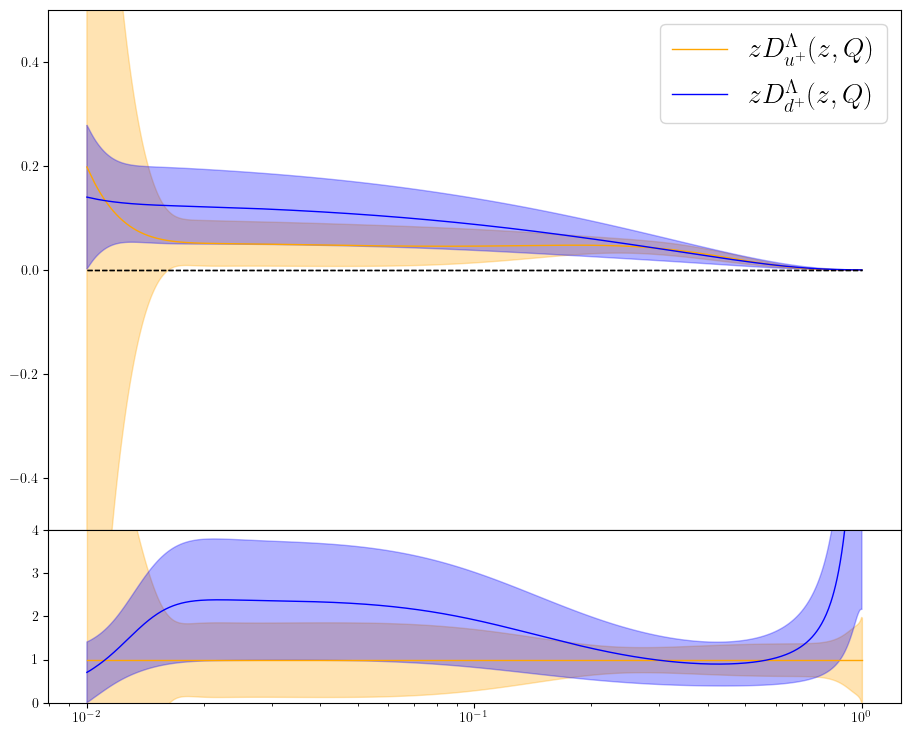

In [15]:
# comparison
from copy import copy
combs_for_comparison = ['Dup', 'Ddp']
colors = ['orange', 'blue']
ref_comb_axes = axes['Dup'][0]
ref_ydata = ref_comb_axes[0].get_lines()[0].get_ydata()
rey_unc = axes['Dup'][2]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex = "all", gridspec_kw = dict(width_ratios = [1], height_ratios = [3, 1], wspace = 0, hspace = 0), figsize=(11,9))

for comb_tuple, color in zip([axes[name] for name in combs_for_comparison], colors):
  comb_axes = comb_tuple[0]
  label = comb_tuple[1]
  ydata_unc = comb_tuple[2]

  # Absolute plot
  abs_line = comb_axes[0].get_lines()[0]
  xdata, ydata_abs = abs_line.get_xdata(), abs_line.get_ydata()
  ax1.plot(xv, ydata_abs, color = color, ls = "-", lw = 1, label=label)
  ax1.plot(xv, xv - xv, color = "black", ls = "--", lw = 1)
  ax1.set_xscale('log')
  ax1.set_ylim([-0.5, 0.5])

  # The reason we need to extract the patch from the PolyCollection
  # is that it is associated to the original figure it was taken from.
  # Matplotlib does not allow to used the same collection in multiple
  # figures (i.e. different artist). Hence we need to extract the raw data
  # (the path) and use it as a patch.
  # Note that I could have used the uncertainties straightaway, but it
  # is interesting to see how it works.
  poly = copy(comb_axes[1])
  path = poly.get_paths()[0]
  patch = plt.Polygon(path.vertices, facecolor=color, edgecolor=color, alpha=poly.get_alpha())
  ax1.add_patch(patch)
  #ax1.fill_between(xv, np.array(ydata_abs) + np.array(ydata_unc), np.array(ydata_abs) - np.array(ydata_unc), color = color, alpha = 0.3)

  # Ratio plot
  ax2.plot(xdata, np.array(ydata_abs) / np.array(ref_ydata),color = color, ls = "-", lw = 1,)
  ax2.fill_between(xv, (np.array(ydata_abs)+np.array(ydata_unc))/np.array(ref_ydata), (np.array(ydata_abs)-np.array(ydata_unc))/np.array(ref_ydata), color = color, alpha = 0.3)
  ax2.set_ylim(0,4)
ax1.legend(fontsize=20)